In [1]:
import logging
from utility import add_project_root_to_path
import numpy as np
from copy import deepcopy

logging.basicConfig(level=logging.ERROR)

add_project_root_to_path()

In [2]:
from fee_algorithm.fixed_fee import FixedFee
from fee_algorithm.discrete_fee_perfect_oracle import DiscreteFeePerfectOracle
from fee_algorithm.based_on_trade_count_fee import BasedOnTradeCountFee
from fee_algorithm.adaptive_fee_based_on_block_price_move import (
    AdaptiveBasedOnPreviousBlockPriceMoveFee,
)
from fee_algorithm.dynamic_fee_amm_for_amm import AMMforAMMfee
from fee_algorithm.improved_fees.piecewise_fee import PiecewiseFee
from fee_algorithm.improved_fees.fixed_fee import ImprovedFixedFee

from copy import deepcopy

fee_algos_to_consider = {
    "FX_fee": FixedFee(exchange_fee_rate=0.003),
    "DA_fee": BasedOnTradeCountFee(
        a_to_b_exchange_fee_rate=0.003, b_to_a_exchange_fee_rate=0.003
    ),
    "BA_fee": AdaptiveBasedOnPreviousBlockPriceMoveFee(
        a_to_b_exchange_fee_rate=0.003, b_to_a_exchange_fee_rate=0.003
    ),
    "AMM_fee": AMMforAMMfee(
        a_to_b_exchange_fee_rate=0.003, b_to_a_exchange_fee_rate=0.003
    ),
    "OB_fee": DiscreteFeePerfectOracle(
        fee_rate_in_arbitrage_direction=0.0045,
        fee_rate_in_non_arbitrage_direction=0.0015,
    ),
    "IMPROVED_FX_fee": PiecewiseFee(base_algorithm=FixedFee(exchange_fee_rate=0.003)),
    "IMPROVED_DA_fee": PiecewiseFee(
        base_algorithm=BasedOnTradeCountFee(
            a_to_b_exchange_fee_rate=0.003, b_to_a_exchange_fee_rate=0.003
        )
    ),
    "IMPROVED_BA_fee": PiecewiseFee(
        base_algorithm=AdaptiveBasedOnPreviousBlockPriceMoveFee(
            a_to_b_exchange_fee_rate=0.003, b_to_a_exchange_fee_rate=0.003
        )
    ),
    "IMPROVED_AMM_fee": PiecewiseFee(
        base_algorithm=AMMforAMMfee(
            a_to_b_exchange_fee_rate=0.003, b_to_a_exchange_fee_rate=0.003
        )
    ),
    "IMPROVED_OB_fee": PiecewiseFee(
        base_algorithm=DiscreteFeePerfectOracle(
            fee_rate_in_arbitrage_direction=0.0045,
            fee_rate_in_non_arbitrage_direction=0.0015,
        )
    ),
}

In [ ]:
# Fit GBM parameters from pre-downloaded 12 s CSVs.
# Uses the first day of each monthly file (~7 200 rows) – same approach as
# fee_algorithms_comparison_synth_data.ipynb but loading from local CSVs
# instead of fetching from the Binance API.

import pandas as pd
from pathlib import Path
from experiments.experiment import GBMParameters
from experiments.synthetic_data import extract_gbm_params

DATA_DIR = Path("data/new_data")
ROWS_PER_DAY = 24 * 3600 // 12  # = 7 200

PAIRS_BY_GROUP = {
    "stable_stable": [
        ("TUSDUSDT_USDCUSDT", "TUSD/USDC"),
        ("TUSDUSDT_USDPUSDT", "TUSD/USDP"),
        ("USDCUSDT_USDPUSDT", "USDC/USDP"),
    ],
    "non_stable_stable": [
        ("USDCUSDT_RADUSDT", "USDC/RAD"),
        ("ETHUSDT_USDT", "ETH/USDT"),
        ("BTCUSDT_USDT", "BTC/USDT"),
        # ("BTCUSDT_ETHUSDT", "BTC/ETH"),
        # ("BTCUSDT_BNBUSDT", "BTC/BNB"),
        # ("ETHUSDT_BNBUSDT", "ETH/BNB"),
    ],
    "non_stable_non_stable": [
        ("BTCUSDT_ETHUSDT", "ETH/BTC"),
        ("ETHUSDT_BNBUSDT", "BNB/ETH"),
        ("DOGEUSDT_BTCUSDT", "DOGE/BTC"),
    ],
}

MONTHS = ["2024-03", "2024-04", "2024-08", "2024-11"]
MONTH_ALIAS = {
    "2024-03": "volatile_market",
    "2024-04": "bear_market",
    "2024-08": "calm_market",
    "2024-11": "bull_market",
}

# gbm_params[(pair_name, month_alias)] = GBMParameters
gbm_params = {}


for group_name, pairs in PAIRS_BY_GROUP.items():
    for csv_prefix, pair_name in pairs:
        for month, month_alias in MONTH_ALIAS.items():
            csv_path = DATA_DIR / f"{csv_prefix}-12s-{month}.csv"
            if not csv_path.exists():
                print(f"WARNING: {csv_path} not found, skipping")
                continue
            df = pd.read_csv(csv_path, nrows=ROWS_PER_DAY)
            params = extract_gbm_params(
                df[["price_A", "price_B"]].transpose().to_numpy()
            )
            gbm_params[(pair_name, month_alias)] = params
            print(f"{pair_name} / {month_alias}: mu={params.mu}, S0={params.S0}")

TUSD/USDC / volatile_market: mu=[1.3894291755568955e-08, -2.7801097197276458e-08], S0=[0.9997, 0.9994]
TUSD/USDC / bear_market: mu=[-6.948536070381617e-08, -5.557438829314489e-08], S0=[0.9998, 1.0]
TUSD/USDC / calm_market: mu=[-5.557994739847391e-08, 6.941591353934919e-08], S0=[0.9999, 1.0003]
TUSD/USDC / bull_market: mu=[5.025829141801734e-07, -1.110266273046607e-07], S0=[0.9932, 1.0013]
TUSD/USDP / volatile_market: mu=[1.3894291755568955e-08, 3.1201498136502903e-19], S0=[0.9997, 0.9993]
TUSD/USDP / bear_market: mu=[-6.948536070381617e-08, -9.72600461682092e-08], S0=[0.9998, 1.0001]
TUSD/USDP / calm_market: mu=[-5.557994739847391e-08, -2.633856836363656e-07], S0=[0.9999, 1.003]
TUSD/USDP / bull_market: mu=[5.025829141801734e-07, -5.549113494020117e-08], S0=[0.9932, 1.0015]
USDC/USDP / volatile_market: mu=[-2.7801097197276458e-08, 3.1201498136502903e-19], S0=[0.9994, 0.9993]
USDC/USDP / bear_market: mu=[-5.557438829314489e-08, -9.72600461682092e-08], S0=[1.0, 1.0001]
USDC/USDP / calm_m

In [ ]:
# SCALE = 100  # variance scale factor (10x std)
SCALE = 1
for key in list(gbm_params.keys()):
    p = gbm_params[key]
    gbm_params[key] = GBMParameters(
        mu=p.mu,
        S0=p.S0,
        cov_matrix=p.cov_matrix * SCALE,
    )

In [5]:
from experiments.experiment import SyntheticDataDescription
from datetime import datetime

# Time ranges: 24 hours per market condition (7 200 blocks at 12s interval)
TIME_RANGE = {
    "volatile_market": (datetime(2024, 3, 1, 12, 0, 0), datetime(2024, 3, 2, 12, 0, 0)),
    "bear_market": (datetime(2024, 4, 1, 12, 0, 0), datetime(2024, 4, 2, 12, 0, 0)),
    "calm_market": (datetime(2024, 8, 1, 12, 0, 0), datetime(2024, 8, 2, 12, 0, 0)),
    "bull_market": (datetime(2024, 11, 1, 12, 0, 0), datetime(2024, 11, 2, 12, 0, 0)),
}

# synth_desc[(pair_name, month_alias)] = SyntheticDataDescription
synth_desc = {
    (pair_name, month_alias): SyntheticDataDescription(
        gbm_parameters=gbm_params[(pair_name, month_alias)],
        start_time=TIME_RANGE[month_alias][0],
        end_time=TIME_RANGE[month_alias][1],
        candle_interval="12s",
    )
    for (pair_name, month_alias) in gbm_params
}

print(f"Synthetic data descriptions: {len(synth_desc)}")

Synthetic data descriptions: 36


In [6]:
from experiments.experiment import Experiment
from experiments.configs import DEFAULT_UNINFORMED_USERS_CONFIG
from user.informed_user import InformedUser
from experiments.run_multiple_experiments import (
    run_multiple_experiments,
    get_experiment_key,
)

# 100 seeds balances statistical robustness with run time.
# 9 pairs × 4 months × 100 seeds × 10 algos = 36 000 experiments.
# Increase to 1000 for publication-quality results (360 000 experiments, ~70 min).
random_seeds = list(range(100))

experiments_configs = {}

for fee_algo_name, fee_algo in fee_algos_to_consider.items():
    for (pair_name, month_alias), desc in synth_desc.items():
        for seed in random_seeds:
            experiments_configs[
                get_experiment_key(
                    {
                        "pair_name": pair_name,
                        "month_alias": month_alias,
                        "fee_algo_name": fee_algo_name,
                        "random_seed": str(seed),
                    }
                )
            ] = Experiment(
                data=desc,
                fee_algorithm=deepcopy(fee_algo),
                informed_user=InformedUser(),
                uninformed_users=deepcopy(DEFAULT_UNINFORMED_USERS_CONFIG),
                random_seed=seed,
                lp_metrics_price_source="pool",
                # lp_metrics_price_source="fair",
            )

print(f"Total experiments to run: {len(experiments_configs)}")

Total experiments to run: 36000


In [7]:
experiments_results = run_multiple_experiments(
    experiments_configs,
    parallel=True,
    max_workers=12,
    return_intermediate_results=False,
)

Running Experiments: 100%|██████████| 36000/36000 [32:34<00:00, 18.42it/s] 


In [8]:
from visualizations.compare_fee_algoritms import get_experiments_summary_by_description

df = get_experiments_summary_by_description(experiments_results)
df

,pair_name,fee_algo_name,month_alias,random_seed,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
0,TUSD/USDC,FX_fee,volatile_market,0,5295413.95,4840,342.33,-3491.17,751,-249.48,-4877666.08,-315.04,4478984.13
1,TUSD/USDC,FX_fee,volatile_market,3,4206565.52,4066,333.84,-3703.09,720,-375.48,-3866205.64,-306.59,3339406.75
2,TUSD/USDC,FX_fee,volatile_market,2,29447330.43,6152,345.35,-4651.39,690,-71.46,-27047088.10,-316.96,5990184.72
3,TUSD/USDC,FX_fee,volatile_market,8,24713244.50,6308,349.25,-6734.41,751,-115.59,-22727591.35,-320.92,6173766.91
4,TUSD/USDC,FX_fee,volatile_market,7,11697977.12,6066,338.54,-3559.70,760,-148.81,-10741700.25,-310.65,3597986.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35995,DOGE/BTC,IMPROVED_OB_fee,bull_market,96,4033049.23,5507,120.27,-7265.95,764,-50.44,23125.61,0.69,2879956.80
35996,DOGE/BTC,IMPROVED_OB_fee,bull_market,95,3874574.38,5486,115.67,-6041.71,729,-41.98,27017.94,0.80,7824977.12
35997,DOGE/BTC,IMPROVED_OB_fee,bull_market,98,4673318.79,5580,119.33,-8129.15,711,-53.32,19911.95,0.51,-1253720.98
35998,DOGE/BTC,IMPROVED_OB_fee,bull_market,97,1784606.09,5286,117.91,-6605.33,727,-105.99,8728.07,0.57,10568960.96


In [9]:
import pandas as pd
from typing import Optional


def show_stats_for_pair_alias(
    pair_name: str, month_alias: str, path_to_save: Optional[str] = None
):
    df_filtered = df[
        (df["pair_name"] == pair_name) & (df["month_alias"] == month_alias)
    ]

    grouped_stats = (
        df_filtered.drop(columns=["pair_name", "month_alias", "random_seed"])
        .groupby("fee_algo_name")
        .agg(["mean", "std"])
    )

    formatted_stats = grouped_stats.apply(
        lambda row: [
            f"{row[col, 'mean']:.2f} \u00b1 {row[col, 'std']:.2f}"
            for col in grouped_stats.columns.get_level_values(0).unique()
        ],
        axis=1,
        result_type="expand",
    )
    formatted_stats.columns = grouped_stats.columns.get_level_values(0).unique()
    print(f"\n=== {pair_name} / {month_alias} ===")
    display(formatted_stats)
    if path_to_save:
        import os

        os.makedirs(os.path.dirname(path_to_save), exist_ok=True)
        formatted_stats.to_csv(path_to_save)
    return formatted_stats

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


def plot_yield_stats(
    pair_name: str, month_alias: str, fee_algos: Optional[list[str]] = None
):
    df_filtered = df[
        (df["pair_name"] == pair_name) & (df["month_alias"] == month_alias)
    ]
    fee_algos = fee_algos or list(df_filtered["fee_algo_name"].unique())
    colors = sns.color_palette("husl", len(fee_algos))

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.set_theme(style="whitegrid")

    for color, algo_name in zip(colors, fee_algos):
        algo_df = df_filtered[df_filtered["fee_algo_name"] == algo_name]
        sns.kdeplot(
            algo_df["lp_yield"],
            ax=ax,
            label=algo_name,
            color=color,
            fill=True,
            alpha=0.3,
        )

    ax.set_xlabel("LP Yield")
    ax.set_ylabel("Density")
    ax.set_title(f"LP Yield distribution — {pair_name} / {month_alias}")
    ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_performance_profile(
    pair_name: str, month_alias: str, fee_algos: Optional[list[str]] = None
):
    df_filtered = df[
        (df["pair_name"] == pair_name) & (df["month_alias"] == month_alias)
    ]
    fee_algos = fee_algos or list(df_filtered["fee_algo_name"].unique())

    best_per_seed = (
        df_filtered[df_filtered["fee_algo_name"].isin(fee_algos)]
        .groupby("random_seed")["lp_yield"]
        .max()
        .reset_index()
        .rename(columns={"lp_yield": "best_lp_yield"})
    )

    merged = df_filtered.merge(best_per_seed, on="random_seed")
    merged["ratio"] = merged["best_lp_yield"] / merged["lp_yield"].replace(0, np.nan)

    tau_vals = np.linspace(1, merged["ratio"].max() + 0.1, 500)
    fig, ax = plt.subplots(figsize=(10, 6))

    colors = sns.color_palette("husl", len(fee_algos))
    for color, algo_name in zip(colors, fee_algos):
        algo_df = merged[merged["fee_algo_name"] == algo_name]
        profile = [(algo_df["ratio"] <= tau).mean() for tau in tau_vals]
        ax.plot(tau_vals, profile, label=algo_name, color=color)

    ax.set_xlabel("Performance ratio τ")
    ax.set_ylabel("Fraction of problems solved")
    ax.set_title(f"Performance profile — {pair_name} / {month_alias}")
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()

### Stable / Stable

#### TUSD/USDC

##### volatile_market


=== TUSD/USDC / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,36351875.83 ± 52051863.57,6136.67 ± 741.61,343.02 ± 5.13,-5341.43 ± 3946.00,715.04 ± 24.56,-134.84 ± 114.56,-33354791.20 ± 47759509.61,-314.76 ± 5.28,10346611.57 ± 9072955.69
BA_fee,36380425.74 ± 52174265.34,6136.21 ± 737.77,343.01 ± 5.05,-5467.90 ± 4235.05,715.62 ± 24.21,-135.92 ± 116.22,-33391371.49 ± 47875095.34,-314.71 ± 5.14,10367175.53 ± 9071091.30
DA_fee,36400234.00 ± 52247606.65,6133.55 ± 740.36,343.02 ± 5.05,-5465.85 ± 4198.78,715.40 ± 24.18,-135.88 ± 116.25,-33395761.67 ± 47915709.98,-314.88 ± 5.07,10379518.88 ± 9066872.01
FX_fee,36382643.49 ± 52167994.36,6135.45 ± 739.43,343.04 ± 5.05,-5467.92 ± 4210.13,715.62 ± 24.11,-136.05 ± 116.22,-33397842.35 ± 47879897.82,-314.92 ± 5.07,10388793.89 ± 9081601.39
IMPROVED_AMM_fee,34951490.58 ± 56822782.13,6323.30 ± 691.12,399.23 ± 7.47,-5464.56 ± 8279.04,713.80 ± 25.86,-118.45 ± 113.45,-91977.91 ± 151688.58,-1.04 ± 0.09,5283568.17 ± 18657567.39
IMPROVED_BA_fee,34946925.26 ± 56777597.76,6334.93 ± 691.14,398.95 ± 7.48,-5405.61 ± 7502.29,712.72 ± 24.95,-117.01 ± 114.77,-91732.74 ± 140505.36,-1.07 ± 0.08,5284493.85 ± 18653446.36
IMPROVED_DA_fee,34952019.94 ± 56794518.57,6334.57 ± 689.90,399.07 ± 7.54,-6522.61 ± 8660.63,713.08 ± 24.99,-122.65 ± 114.47,-99927.28 ± 161531.36,-1.16 ± 0.14,5286645.74 ± 18650652.45
IMPROVED_FX_fee,34946880.13 ± 56778947.99,6335.35 ± 691.66,398.81 ± 7.51,-5339.41 ± 7400.65,713.30 ± 25.14,-120.15 ± 115.65,-87910.14 ± 139013.56,-1.01 ± 0.06,5282310.44 ± 18658272.26
IMPROVED_OB_fee,34933782.22 ± 56807083.07,6218.63 ± 669.31,400.11 ± 7.54,-5394.12 ± 6514.70,714.18 ± 24.73,-120.66 ± 116.69,53.58 ± 3462.80,-0.02 ± 0.03,5244784.97 ± 18780368.17


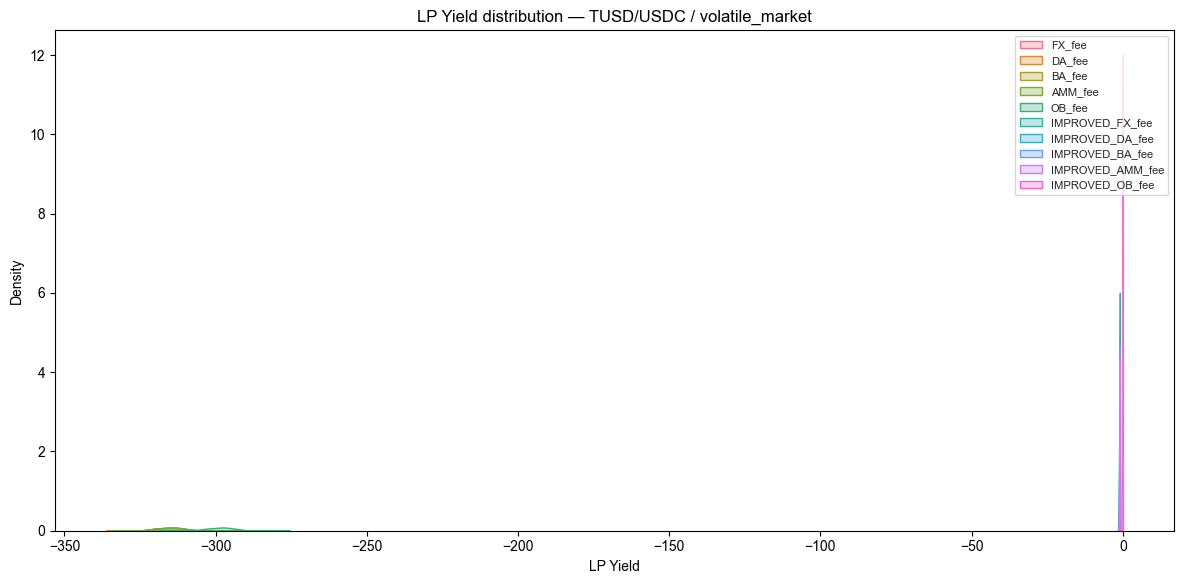

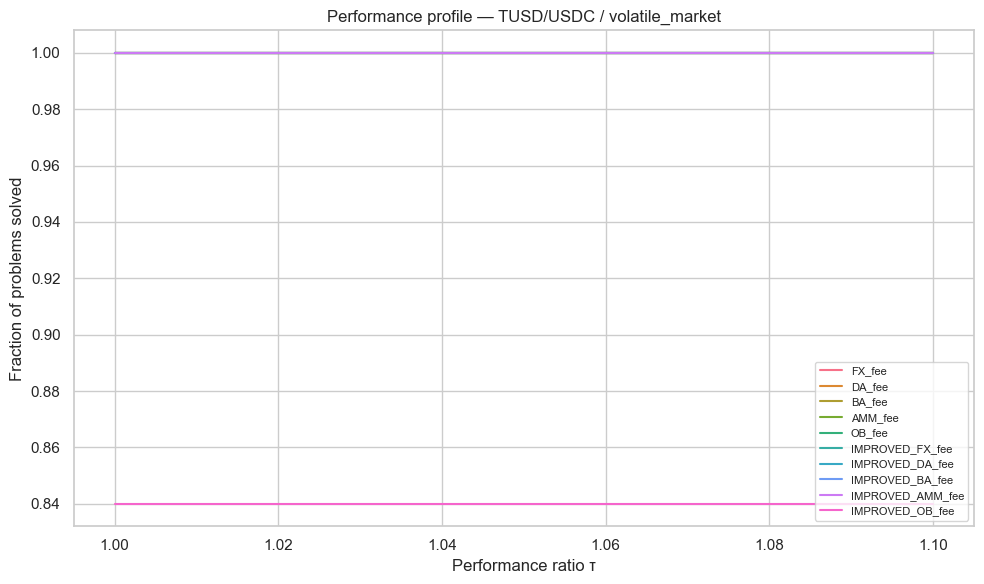

In [11]:
show_stats_for_pair_alias("TUSD/USDC", "volatile_market")
plot_yield_stats("TUSD/USDC", "volatile_market")
plot_performance_profile("TUSD/USDC", "volatile_market")

##### bull_market


=== TUSD/USDC / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,4748751.66 ± 5059446.66,5623.54 ± 218.34,100.93 ± 1.19,-7712.62 ± 4961.10,721.46 ± 24.55,-72.63 ± 26.77,-3345855.85 ± 3553624.90,-71.19 ± 1.30,6325574.53 ± 28691886.00
BA_fee,4771884.49 ± 5086350.72,5628.72 ± 217.87,101.13 ± 1.20,-7891.05 ± 5339.46,720.32 ± 24.16,-73.45 ± 26.28,-3393380.98 ± 3597939.98,-71.93 ± 1.23,6341413.27 ± 28700211.53
DA_fee,4774894.24 ± 5089615.05,5624.85 ± 217.54,101.21 ± 1.20,-7904.03 ± 5255.19,720.79 ± 24.47,-73.91 ± 26.72,-3403009.39 ± 3616205.43,-72.14 ± 1.19,6362692.86 ± 28765095.54
FX_fee,4779825.96 ± 5093430.34,5629.99 ± 217.79,101.22 ± 1.20,-7876.10 ± 5301.10,720.80 ± 24.31,-73.52 ± 26.54,-3410460.50 ± 3611639.91,-72.28 ± 1.16,6356487.75 ± 28732236.54
IMPROVED_AMM_fee,4173598.51 ± 4441420.48,5740.85 ± 199.23,117.71 ± 1.78,-7932.57 ± 5268.29,720.53 ± 23.57,-72.89 ± 25.87,-172475.52 ± 189549.47,-4.88 ± 0.33,5771373.41 ± 28182266.42
IMPROVED_BA_fee,4250030.52 ± 4511918.84,5800.27 ± 193.16,118.83 ± 1.72,-7828.67 ± 4757.81,720.69 ± 23.81,-73.19 ± 26.95,-266770.69 ± 271678.57,-7.56 ± 0.26,5851433.32 ± 28251735.98
IMPROVED_DA_fee,4271419.03 ± 4516226.62,5797.67 ± 192.85,119.53 ± 1.74,-8012.35 ± 5408.77,719.89 ± 23.95,-73.63 ± 26.43,-295350.94 ± 290955.40,-8.44 ± 0.84,5881773.74 ± 28271784.70
IMPROVED_FX_fee,4244979.74 ± 4504987.78,5803.30 ± 191.20,118.50 ± 1.75,-7861.82 ± 5172.41,720.22 ± 23.87,-73.24 ± 26.90,-261518.05 ± 268952.75,-7.38 ± 0.22,5847373.57 ± 28247565.78
IMPROVED_OB_fee,4041745.04 ± 4294385.30,5387.89 ± 182.68,118.29 ± 1.82,-7652.80 ± 3934.14,720.58 ± 24.44,-73.41 ± 28.62,23493.28 ± 34597.24,0.58 ± 0.17,5650766.83 ± 28080370.77


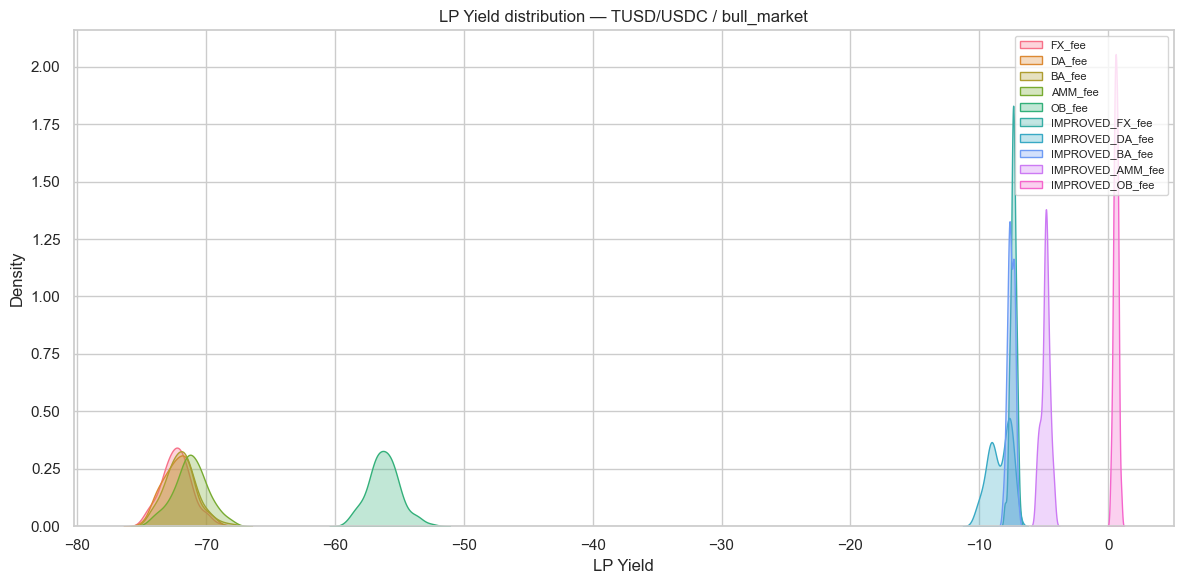

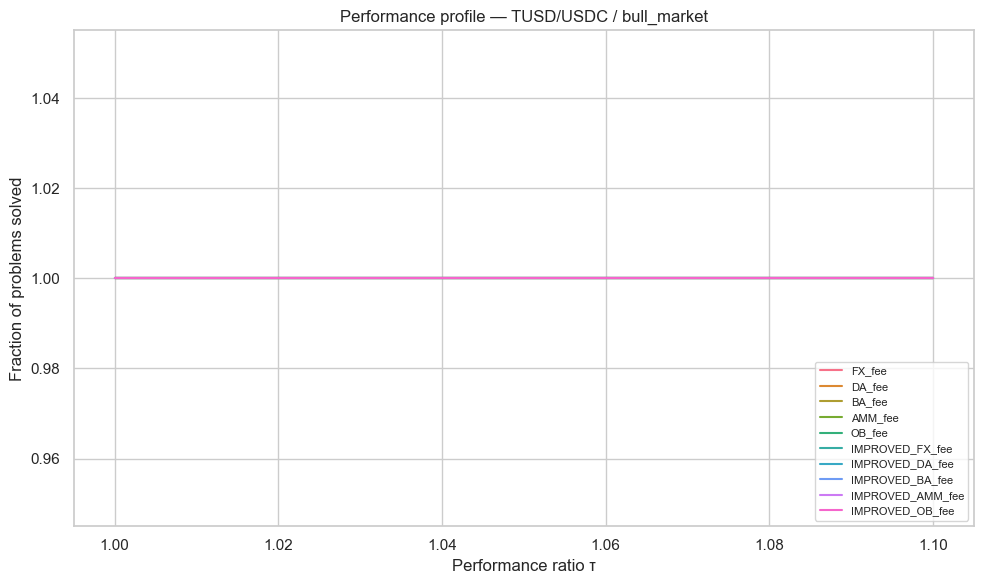

In [12]:
show_stats_for_pair_alias("TUSD/USDC", "bull_market")
plot_yield_stats("TUSD/USDC", "bull_market")
plot_performance_profile("TUSD/USDC", "bull_market")

##### calm_market


=== TUSD/USDC / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,1235339.40 ± 1108510.52,4597.64 ± 264.43,55.03 ± 0.74,-7913.01 ± 3642.25,721.05 ± 24.70,-69.39 ± 20.42,-540434.03 ± 474748.53,-24.31 ± 1.15,1663845.75 ± 8350063.16
BA_fee,1266863.44 ± 1143515.94,4622.11 ± 260.64,55.60 ± 0.71,-7990.17 ± 4003.51,721.15 ± 23.60,-69.71 ± 20.85,-599736.26 ± 528303.20,-26.50 ± 0.96,1690004.33 ± 8365728.12
DA_fee,1271415.17 ± 1147766.26,4622.30 ± 260.26,55.72 ± 0.72,-7958.66 ± 4044.63,721.08 ± 23.27,-69.45 ± 20.68,-609765.25 ± 539484.47,-26.89 ± 1.03,1701224.20 ± 8403379.68
FX_fee,1273233.79 ± 1149459.67,4629.10 ± 259.58,55.71 ± 0.72,-7944.63 ± 4087.40,721.10 ± 23.21,-69.28 ± 20.65,-614107.71 ± 543976.42,-27.02 ± 0.83,1698970.53 ± 8382271.38
IMPROVED_AMM_fee,1190331.98 ± 1066144.61,4689.28 ± 249.39,60.30 ± 0.89,-8083.78 ± 4634.51,721.32 ± 24.08,-69.68 ± 20.84,-64945.13 ± 54179.11,-3.48 ± 0.62,1626737.83 ± 8322237.63
IMPROVED_BA_fee,1271822.97 ± 1143478.21,4772.64 ± 246.23,62.80 ± 0.95,-7870.25 ± 3928.47,721.51 ± 24.04,-68.62 ± 20.86,-167128.74 ± 138458.49,-8.43 ± 0.50,1700791.68 ± 8385956.44
IMPROVED_DA_fee,1284081.08 ± 1155061.00,4776.74 ± 245.73,63.24 ± 1.02,-7991.05 ± 4191.83,721.51 ± 23.90,-69.34 ± 20.63,-185465.22 ± 159490.88,-9.25 ± 0.64,1718299.66 ± 8417777.52
IMPROVED_FX_fee,1276915.84 ± 1149502.47,4781.18 ± 247.18,62.83 ± 0.97,-7888.48 ± 3978.28,721.91 ± 24.73,-68.63 ± 20.69,-174909.08 ± 147872.82,-8.75 ± 0.33,1707129.18 ± 8393625.31
IMPROVED_OB_fee,1108231.58 ± 998163.02,4169.24 ± 224.48,61.76 ± 0.98,-8019.07 ± 3840.82,721.87 ± 23.48,-69.95 ± 21.38,85360.53 ± 81475.94,4.54 ± 0.40,1544381.08 ± 8253928.16


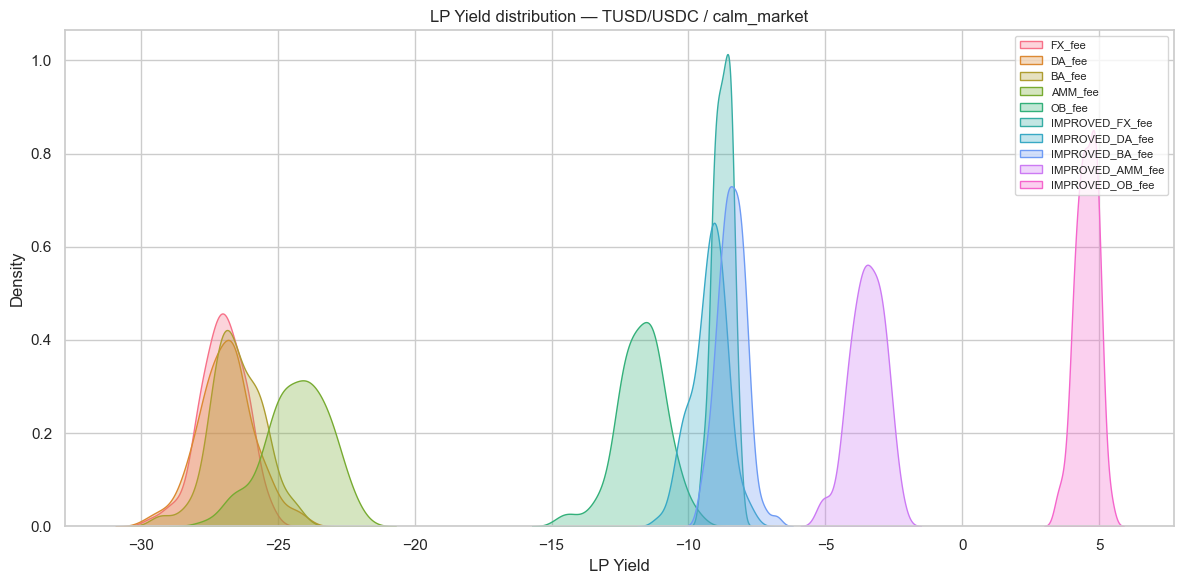

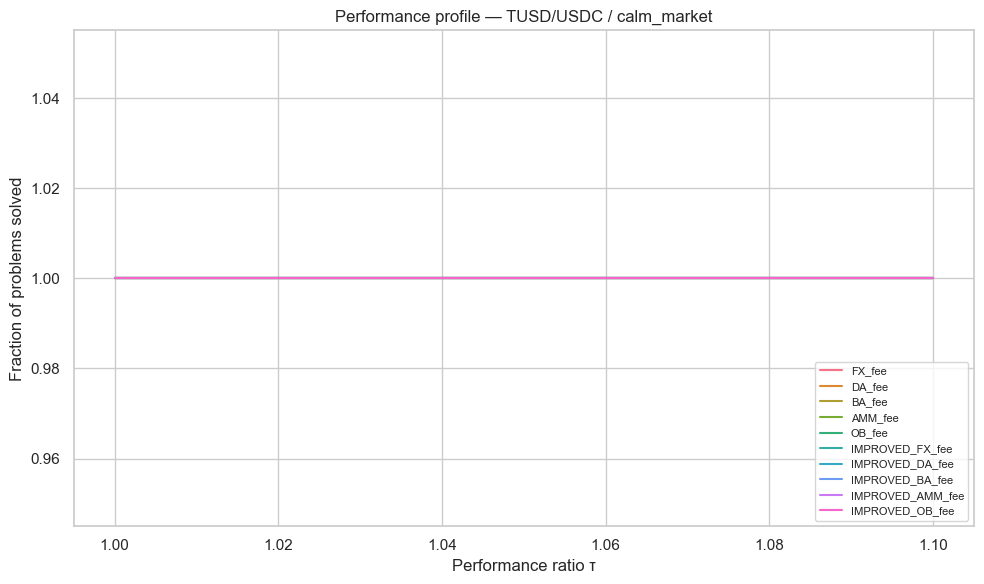

In [13]:
show_stats_for_pair_alias("TUSD/USDC", "calm_market")
plot_yield_stats("TUSD/USDC", "calm_market")
plot_performance_profile("TUSD/USDC", "calm_market")

##### bear_market


=== TUSD/USDC / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,2229263.62 ± 2074686.07,5104.82 ± 240.19,71.83 ± 0.87,-7906.29 ± 4252.66,720.88 ± 24.43,-70.94 ± 22.17,-1287382.67 ± 1188636.98,-41.62 ± 1.16,3133786.84 ± 15059002.77
BA_fee,2257642.66 ± 2101832.91,5118.57 ± 235.28,72.20 ± 0.92,-7804.63 ± 3629.73,720.77 ± 24.53,-71.53 ± 23.13,-1343498.11 ± 1236650.62,-43.03 ± 1.00,3157756.55 ± 15084104.39
DA_fee,2261942.00 ± 2107034.39,5114.37 ± 236.62,72.30 ± 0.92,-7846.91 ± 3861.07,720.68 ± 24.49,-71.56 ± 22.91,-1355421.27 ± 1254676.78,-43.37 ± 0.94,3175043.40 ± 15124301.75
FX_fee,2264728.90 ± 2108394.13,5121.27 ± 236.59,72.30 ± 0.92,-7788.96 ± 3802.31,720.86 ± 24.62,-71.23 ± 23.20,-1358657.51 ± 1248768.06,-43.47 ± 0.91,3168202.52 ± 15098661.72
IMPROVED_AMM_fee,2075320.34 ± 1926288.60,5216.51 ± 227.23,81.79 ± 1.33,-7883.01 ± 3909.17,720.88 ± 24.89,-70.89 ± 21.84,-121019.97 ± 112043.70,-4.86 ± 0.49,2990394.58 ± 14930201.00
IMPROVED_BA_fee,2168866.55 ± 2005096.57,5294.59 ± 213.79,83.99 ± 1.35,-7772.68 ± 3970.91,721.24 ± 24.28,-70.98 ± 23.78,-234198.82 ± 203608.38,-9.19 ± 0.33,3077211.98 ± 15001620.74
IMPROVED_DA_fee,2186864.55 ± 2015296.90,5293.30 ± 216.47,84.68 ± 1.30,-7830.36 ± 3820.14,722.07 ± 23.18,-71.08 ± 23.00,-260980.10 ± 227418.55,-10.26 ± 0.86,3104436.14 ± 15028947.13
IMPROVED_FX_fee,2170407.51 ± 2007861.84,5299.62 ± 215.51,83.87 ± 1.33,-7877.55 ± 3850.91,722.26 ± 23.19,-71.67 ± 23.46,-237090.71 ± 210070.05,-9.26 ± 0.25,3081052.63 ± 15007408.58
IMPROVED_OB_fee,1966662.52 ± 1822297.00,4764.15 ± 200.91,82.74 ± 1.36,-7872.17 ± 4217.66,721.30 ± 23.99,-70.92 ± 23.89,53018.24 ± 56179.62,2.09 ± 0.26,2889969.79 ± 14853973.06


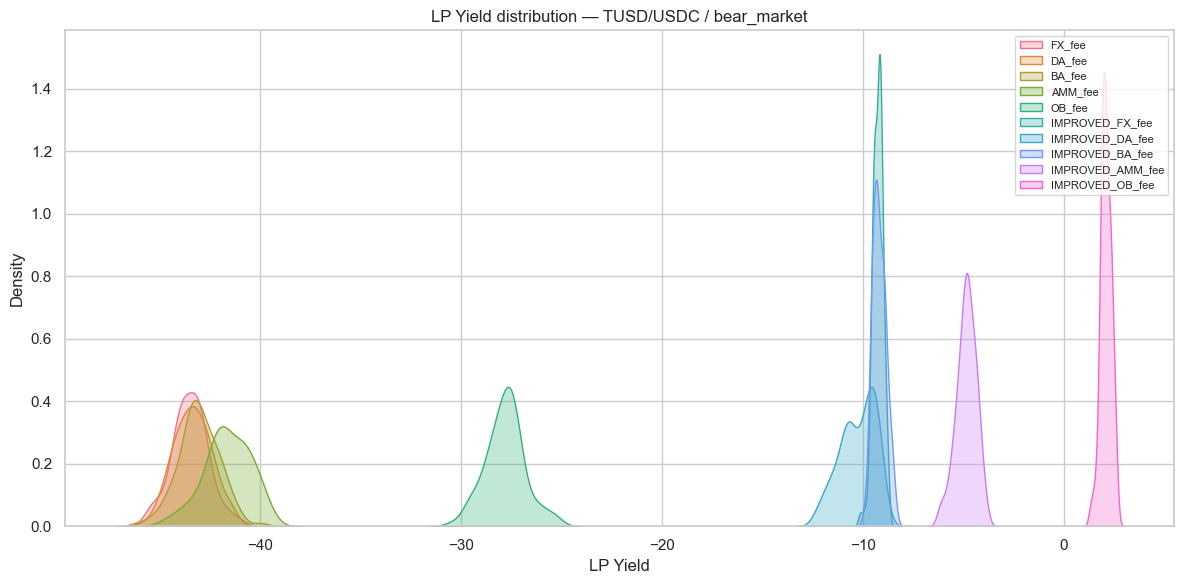

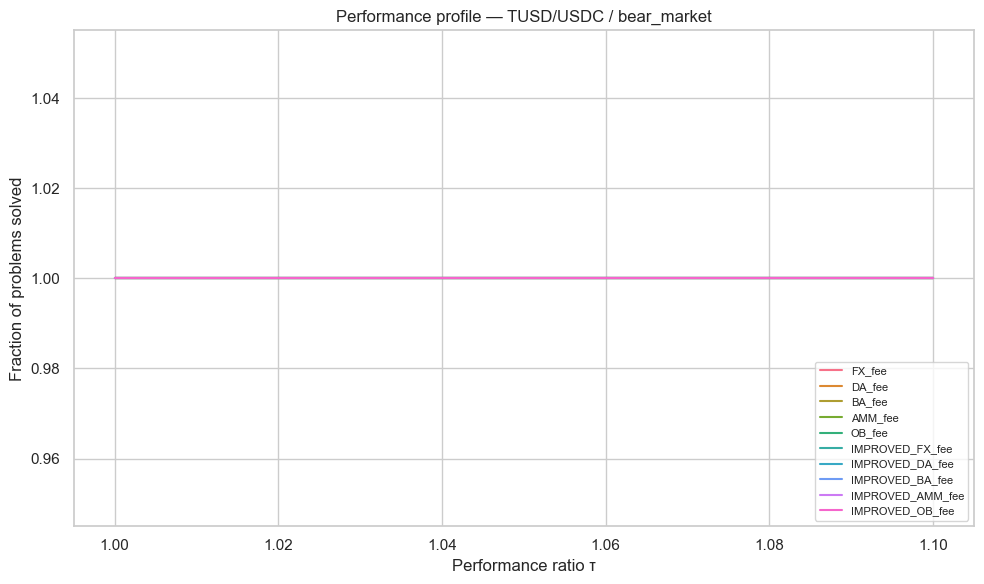

In [14]:
show_stats_for_pair_alias("TUSD/USDC", "bear_market")
plot_yield_stats("TUSD/USDC", "bear_market")
plot_performance_profile("TUSD/USDC", "bear_market")

#### TUSD/USDP

##### volatile_market


=== TUSD/USDP / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,36351875.83 ± 52051863.57,6136.67 ± 741.61,343.02 ± 5.13,-5341.43 ± 3946.00,715.04 ± 24.56,-134.84 ± 114.56,-33354791.20 ± 47759509.61,-314.76 ± 5.28,10346611.57 ± 9072955.69
BA_fee,36380425.74 ± 52174265.34,6136.21 ± 737.77,343.01 ± 5.05,-5467.90 ± 4235.05,715.62 ± 24.21,-135.92 ± 116.22,-33391371.49 ± 47875095.34,-314.71 ± 5.14,10367175.53 ± 9071091.30
DA_fee,36400234.00 ± 52247606.65,6133.55 ± 740.36,343.02 ± 5.05,-5465.85 ± 4198.78,715.40 ± 24.18,-135.88 ± 116.25,-33395761.67 ± 47915709.98,-314.88 ± 5.07,10379518.88 ± 9066872.01
FX_fee,36382643.49 ± 52167994.36,6135.45 ± 739.43,343.04 ± 5.05,-5467.92 ± 4210.13,715.62 ± 24.11,-136.05 ± 116.22,-33397842.35 ± 47879897.82,-314.92 ± 5.07,10388793.89 ± 9081601.39
IMPROVED_AMM_fee,34951490.58 ± 56822782.13,6323.30 ± 691.12,399.23 ± 7.47,-5464.56 ± 8279.04,713.80 ± 25.86,-118.45 ± 113.45,-91977.91 ± 151688.58,-1.04 ± 0.09,5283568.17 ± 18657567.39
IMPROVED_BA_fee,34946925.26 ± 56777597.76,6334.93 ± 691.14,398.95 ± 7.48,-5405.61 ± 7502.29,712.72 ± 24.95,-117.01 ± 114.77,-91732.74 ± 140505.36,-1.07 ± 0.08,5284493.85 ± 18653446.36
IMPROVED_DA_fee,34952019.94 ± 56794518.57,6334.57 ± 689.90,399.07 ± 7.54,-6522.61 ± 8660.63,713.08 ± 24.99,-122.65 ± 114.47,-99927.28 ± 161531.36,-1.16 ± 0.14,5286645.74 ± 18650652.45
IMPROVED_FX_fee,34946880.13 ± 56778947.99,6335.35 ± 691.66,398.81 ± 7.51,-5339.41 ± 7400.65,713.30 ± 25.14,-120.15 ± 115.65,-87910.14 ± 139013.56,-1.01 ± 0.06,5282310.44 ± 18658272.26
IMPROVED_OB_fee,34933782.22 ± 56807083.07,6218.63 ± 669.31,400.11 ± 7.54,-5394.12 ± 6514.70,714.18 ± 24.73,-120.66 ± 116.69,53.58 ± 3462.80,-0.02 ± 0.03,5244784.97 ± 18780368.17


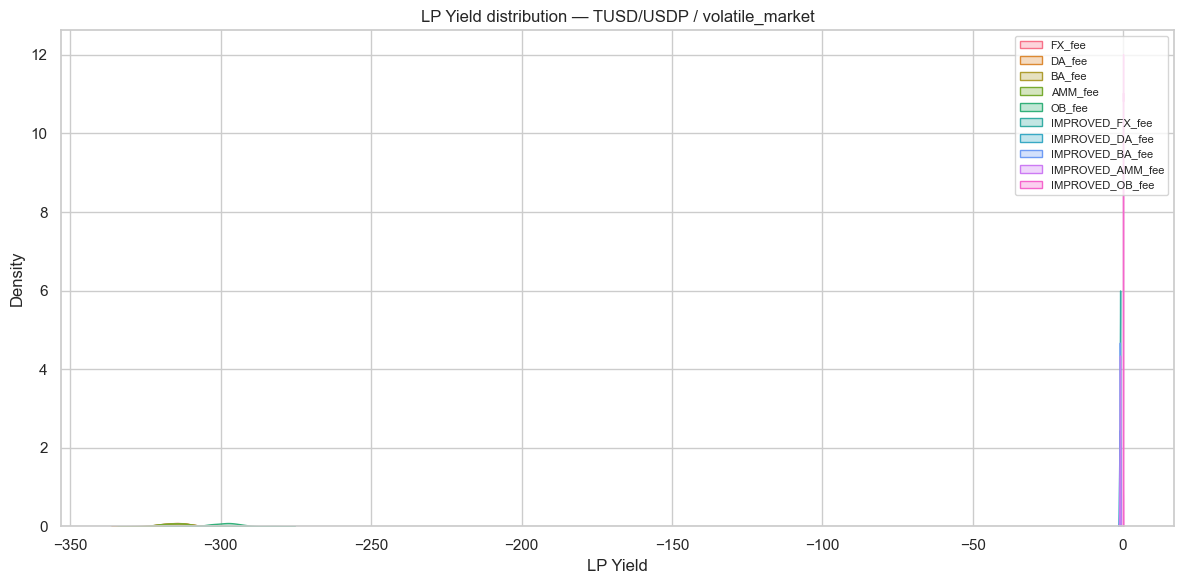

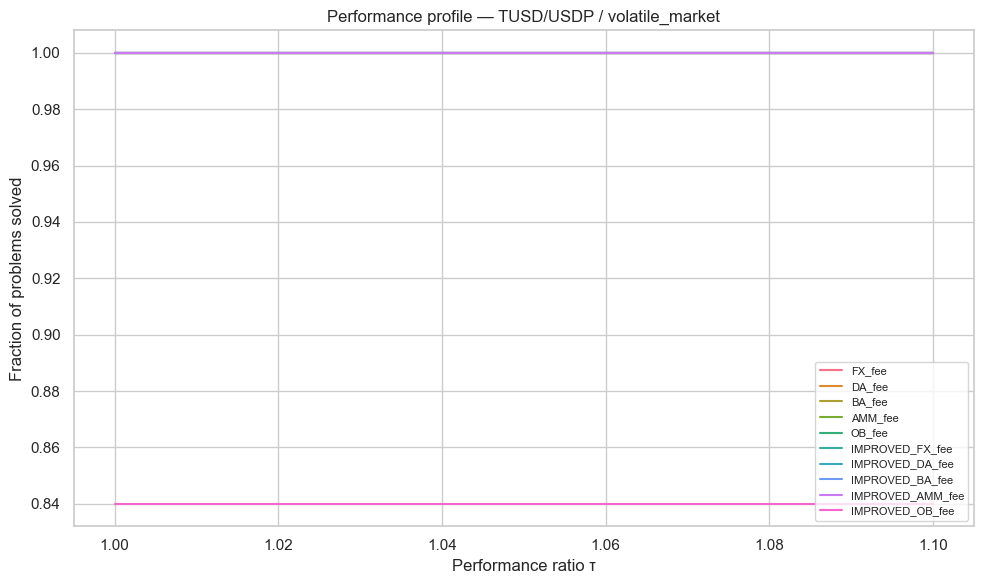

In [15]:
show_stats_for_pair_alias("TUSD/USDP", "volatile_market")
plot_yield_stats("TUSD/USDP", "volatile_market")
plot_performance_profile("TUSD/USDP", "volatile_market")

##### bull_market


=== TUSD/USDP / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,4748751.66 ± 5059446.66,5623.54 ± 218.34,100.93 ± 1.19,-7712.62 ± 4961.10,721.46 ± 24.55,-72.63 ± 26.77,-3345855.85 ± 3553624.90,-71.19 ± 1.30,6325574.53 ± 28691886.00
BA_fee,4771884.49 ± 5086350.72,5628.72 ± 217.87,101.13 ± 1.20,-7891.05 ± 5339.46,720.32 ± 24.16,-73.45 ± 26.28,-3393380.98 ± 3597939.98,-71.93 ± 1.23,6341413.27 ± 28700211.53
DA_fee,4774894.24 ± 5089615.05,5624.85 ± 217.54,101.21 ± 1.20,-7904.03 ± 5255.19,720.79 ± 24.47,-73.91 ± 26.72,-3403009.39 ± 3616205.43,-72.14 ± 1.19,6362692.86 ± 28765095.54
FX_fee,4779825.96 ± 5093430.34,5629.99 ± 217.79,101.22 ± 1.20,-7876.10 ± 5301.10,720.80 ± 24.31,-73.52 ± 26.54,-3410460.50 ± 3611639.91,-72.28 ± 1.16,6356487.75 ± 28732236.54
IMPROVED_AMM_fee,4173598.51 ± 4441420.48,5740.85 ± 199.23,117.71 ± 1.78,-7932.57 ± 5268.29,720.53 ± 23.57,-72.89 ± 25.87,-172475.52 ± 189549.47,-4.88 ± 0.33,5771373.41 ± 28182266.42
IMPROVED_BA_fee,4250030.52 ± 4511918.84,5800.27 ± 193.16,118.83 ± 1.72,-7828.67 ± 4757.81,720.69 ± 23.81,-73.19 ± 26.95,-266770.69 ± 271678.57,-7.56 ± 0.26,5851433.32 ± 28251735.98
IMPROVED_DA_fee,4271419.03 ± 4516226.62,5797.67 ± 192.85,119.53 ± 1.74,-8012.35 ± 5408.77,719.89 ± 23.95,-73.63 ± 26.43,-295350.94 ± 290955.40,-8.44 ± 0.84,5881773.74 ± 28271784.70
IMPROVED_FX_fee,4244979.74 ± 4504987.78,5803.30 ± 191.20,118.50 ± 1.75,-7861.82 ± 5172.41,720.22 ± 23.87,-73.24 ± 26.90,-261518.05 ± 268952.75,-7.38 ± 0.22,5847373.57 ± 28247565.78
IMPROVED_OB_fee,4041745.04 ± 4294385.30,5387.89 ± 182.68,118.29 ± 1.82,-7652.80 ± 3934.14,720.58 ± 24.44,-73.41 ± 28.62,23493.28 ± 34597.24,0.58 ± 0.17,5650766.83 ± 28080370.77


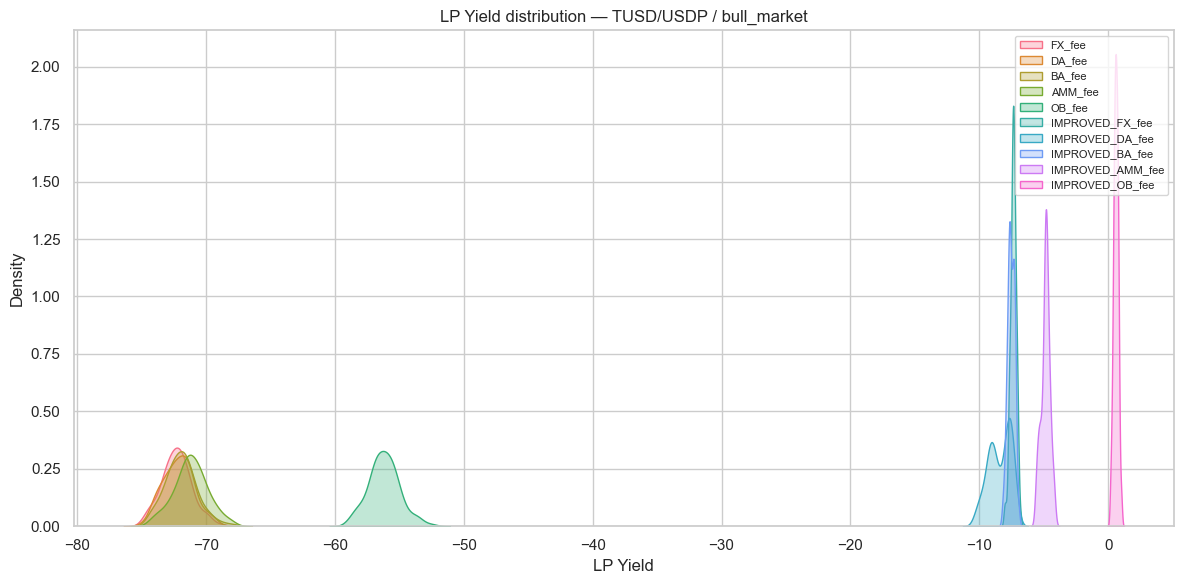

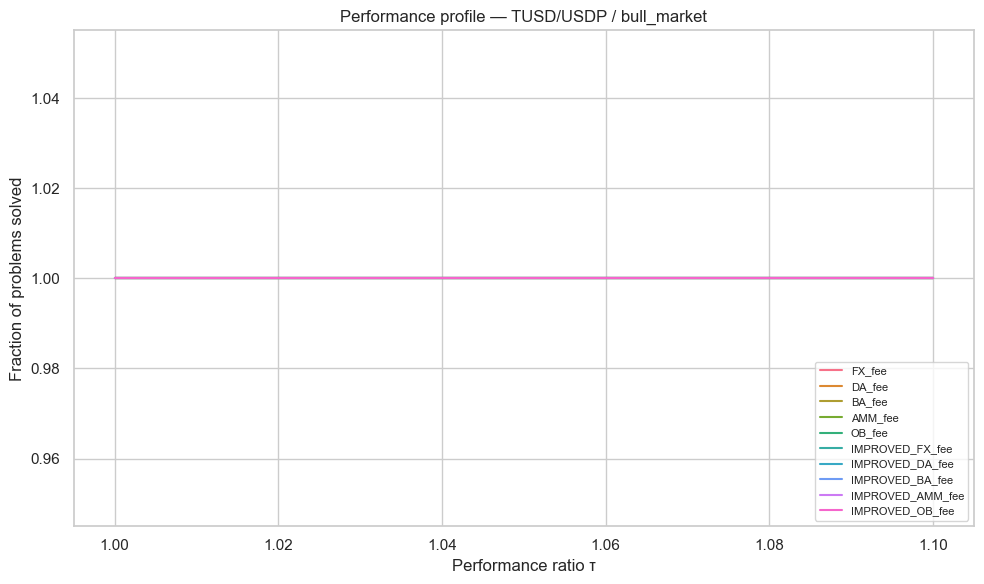

In [16]:
show_stats_for_pair_alias("TUSD/USDP", "bull_market")
plot_yield_stats("TUSD/USDP", "bull_market")
plot_performance_profile("TUSD/USDP", "bull_market")

##### calm_market


=== TUSD/USDP / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,1235339.40 ± 1108510.52,4597.64 ± 264.43,55.03 ± 0.74,-7913.01 ± 3642.25,721.05 ± 24.70,-69.39 ± 20.42,-540434.03 ± 474748.53,-24.31 ± 1.15,1663845.75 ± 8350063.16
BA_fee,1266863.44 ± 1143515.94,4622.11 ± 260.64,55.60 ± 0.71,-7990.17 ± 4003.51,721.15 ± 23.60,-69.71 ± 20.85,-599736.26 ± 528303.20,-26.50 ± 0.96,1690004.33 ± 8365728.12
DA_fee,1271415.17 ± 1147766.26,4622.30 ± 260.26,55.72 ± 0.72,-7958.66 ± 4044.63,721.08 ± 23.27,-69.45 ± 20.68,-609765.25 ± 539484.47,-26.89 ± 1.03,1701224.20 ± 8403379.68
FX_fee,1273233.79 ± 1149459.67,4629.10 ± 259.58,55.71 ± 0.72,-7944.63 ± 4087.40,721.10 ± 23.21,-69.28 ± 20.65,-614107.71 ± 543976.42,-27.02 ± 0.83,1698970.53 ± 8382271.38
IMPROVED_AMM_fee,1190331.98 ± 1066144.61,4689.28 ± 249.39,60.30 ± 0.89,-8083.78 ± 4634.51,721.32 ± 24.08,-69.68 ± 20.84,-64945.13 ± 54179.11,-3.48 ± 0.62,1626737.83 ± 8322237.63
IMPROVED_BA_fee,1271822.97 ± 1143478.21,4772.64 ± 246.23,62.80 ± 0.95,-7870.25 ± 3928.47,721.51 ± 24.04,-68.62 ± 20.86,-167128.74 ± 138458.49,-8.43 ± 0.50,1700791.68 ± 8385956.44
IMPROVED_DA_fee,1284081.08 ± 1155061.00,4776.74 ± 245.73,63.24 ± 1.02,-7991.05 ± 4191.83,721.51 ± 23.90,-69.34 ± 20.63,-185465.22 ± 159490.88,-9.25 ± 0.64,1718299.66 ± 8417777.52
IMPROVED_FX_fee,1276915.84 ± 1149502.47,4781.18 ± 247.18,62.83 ± 0.97,-7888.48 ± 3978.28,721.91 ± 24.73,-68.63 ± 20.69,-174909.08 ± 147872.82,-8.75 ± 0.33,1707129.18 ± 8393625.31
IMPROVED_OB_fee,1108231.58 ± 998163.02,4169.24 ± 224.48,61.76 ± 0.98,-8019.07 ± 3840.82,721.87 ± 23.48,-69.95 ± 21.38,85360.53 ± 81475.94,4.54 ± 0.40,1544381.08 ± 8253928.16


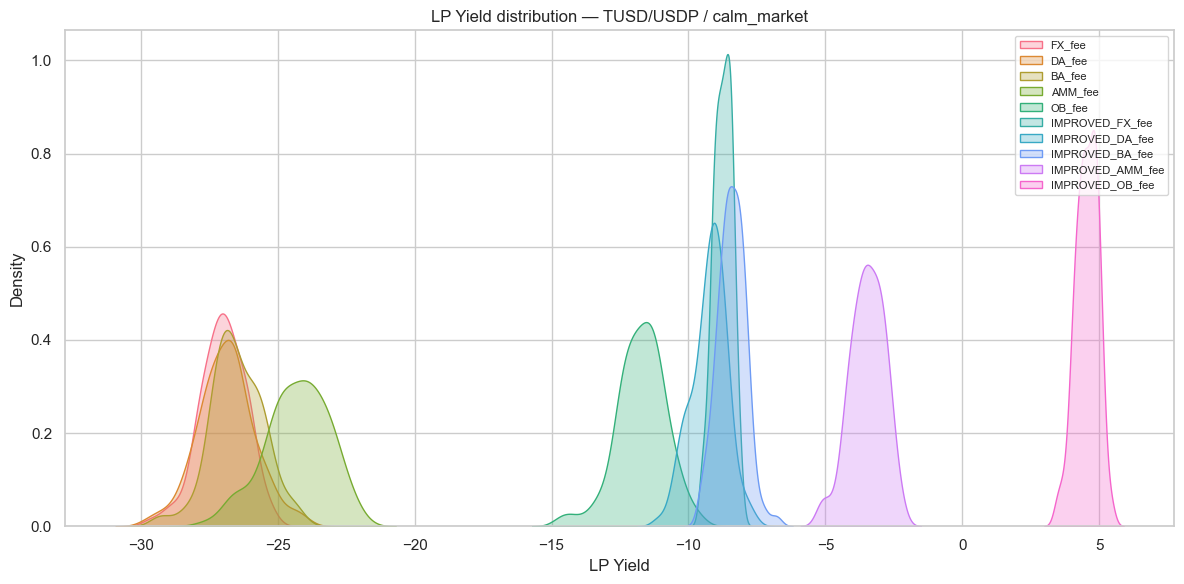

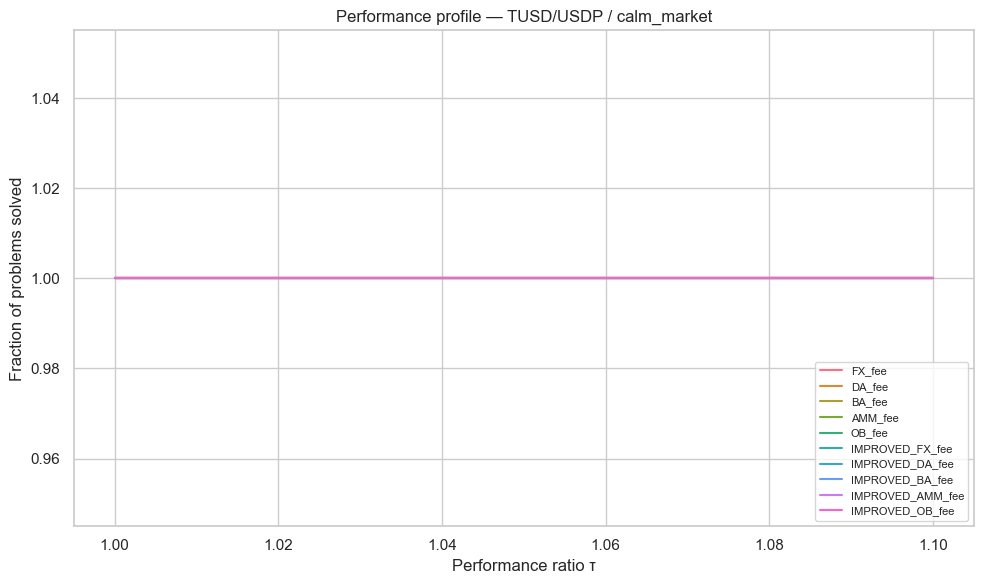

In [17]:
show_stats_for_pair_alias("TUSD/USDP", "calm_market")
plot_yield_stats("TUSD/USDP", "calm_market")
plot_performance_profile("TUSD/USDP", "calm_market")

##### bear_market


=== TUSD/USDP / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,2229263.62 ± 2074686.07,5104.82 ± 240.19,71.83 ± 0.87,-7906.29 ± 4252.66,720.88 ± 24.43,-70.94 ± 22.17,-1287382.67 ± 1188636.98,-41.62 ± 1.16,3133786.84 ± 15059002.77
BA_fee,2257642.66 ± 2101832.91,5118.57 ± 235.28,72.20 ± 0.92,-7804.63 ± 3629.73,720.77 ± 24.53,-71.53 ± 23.13,-1343498.11 ± 1236650.62,-43.03 ± 1.00,3157756.55 ± 15084104.39
DA_fee,2261942.00 ± 2107034.39,5114.37 ± 236.62,72.30 ± 0.92,-7846.91 ± 3861.07,720.68 ± 24.49,-71.56 ± 22.91,-1355421.27 ± 1254676.78,-43.37 ± 0.94,3175043.40 ± 15124301.75
FX_fee,2264728.90 ± 2108394.13,5121.27 ± 236.59,72.30 ± 0.92,-7788.96 ± 3802.31,720.86 ± 24.62,-71.23 ± 23.20,-1358657.51 ± 1248768.06,-43.47 ± 0.91,3168202.52 ± 15098661.72
IMPROVED_AMM_fee,2075320.34 ± 1926288.60,5216.51 ± 227.23,81.79 ± 1.33,-7883.01 ± 3909.17,720.88 ± 24.89,-70.89 ± 21.84,-121019.97 ± 112043.70,-4.86 ± 0.49,2990394.58 ± 14930201.00
IMPROVED_BA_fee,2168866.55 ± 2005096.57,5294.59 ± 213.79,83.99 ± 1.35,-7772.68 ± 3970.91,721.24 ± 24.28,-70.98 ± 23.78,-234198.82 ± 203608.38,-9.19 ± 0.33,3077211.98 ± 15001620.74
IMPROVED_DA_fee,2186864.55 ± 2015296.90,5293.30 ± 216.47,84.68 ± 1.30,-7830.36 ± 3820.14,722.07 ± 23.18,-71.08 ± 23.00,-260980.10 ± 227418.55,-10.26 ± 0.86,3104436.14 ± 15028947.13
IMPROVED_FX_fee,2170407.51 ± 2007861.84,5299.62 ± 215.51,83.87 ± 1.33,-7877.55 ± 3850.91,722.26 ± 23.19,-71.67 ± 23.46,-237090.71 ± 210070.05,-9.26 ± 0.25,3081052.63 ± 15007408.58
IMPROVED_OB_fee,1966662.52 ± 1822297.00,4764.15 ± 200.91,82.74 ± 1.36,-7872.17 ± 4217.66,721.30 ± 23.99,-70.92 ± 23.89,53018.24 ± 56179.62,2.09 ± 0.26,2889969.79 ± 14853973.06


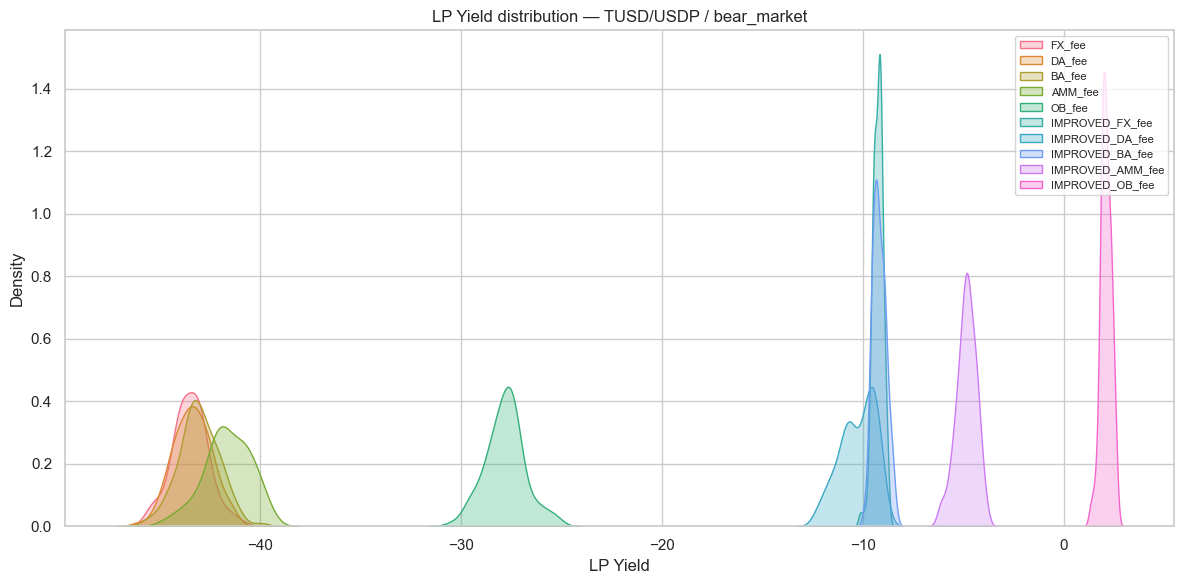

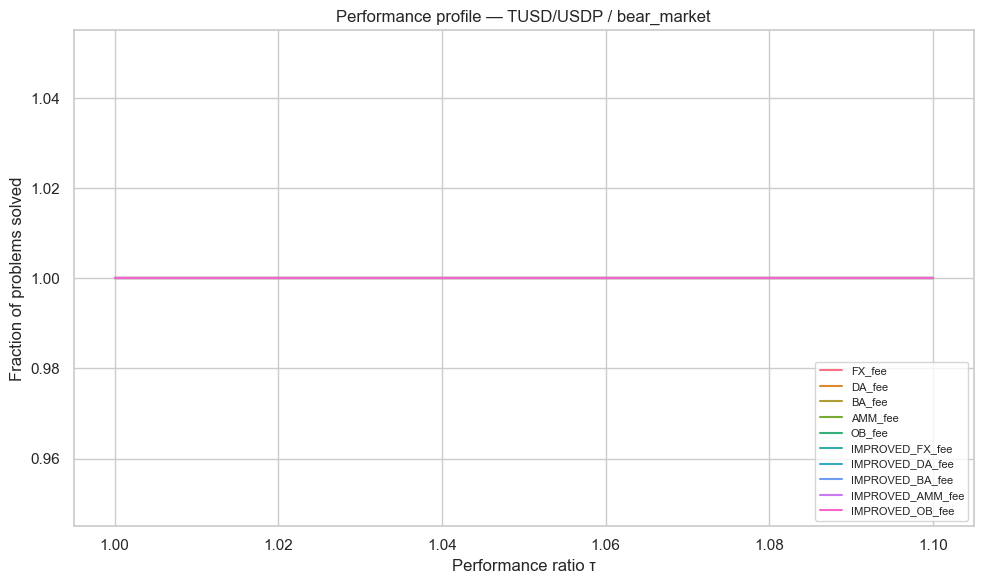

In [18]:
show_stats_for_pair_alias("TUSD/USDP", "bear_market")
plot_yield_stats("TUSD/USDP", "bear_market")
plot_performance_profile("TUSD/USDP", "bear_market")

#### USDC/USDP

##### volatile_market


=== USDC/USDP / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,36351875.83 ± 52051863.57,6136.67 ± 741.61,343.02 ± 5.13,-5341.43 ± 3946.00,715.04 ± 24.56,-134.84 ± 114.56,-33354791.20 ± 47759509.61,-314.76 ± 5.28,10346611.57 ± 9072955.69
BA_fee,36380425.74 ± 52174265.34,6136.21 ± 737.77,343.01 ± 5.05,-5467.90 ± 4235.05,715.62 ± 24.21,-135.92 ± 116.22,-33391371.49 ± 47875095.34,-314.71 ± 5.14,10367175.53 ± 9071091.30
DA_fee,36400234.00 ± 52247606.65,6133.55 ± 740.36,343.02 ± 5.05,-5465.85 ± 4198.78,715.40 ± 24.18,-135.88 ± 116.25,-33395761.67 ± 47915709.98,-314.88 ± 5.07,10379518.88 ± 9066872.01
FX_fee,36382643.49 ± 52167994.36,6135.45 ± 739.43,343.04 ± 5.05,-5467.92 ± 4210.13,715.62 ± 24.11,-136.05 ± 116.22,-33397842.35 ± 47879897.82,-314.92 ± 5.07,10388793.89 ± 9081601.39
IMPROVED_AMM_fee,34951490.58 ± 56822782.13,6323.30 ± 691.12,399.23 ± 7.47,-5464.56 ± 8279.04,713.80 ± 25.86,-118.45 ± 113.45,-91977.91 ± 151688.58,-1.04 ± 0.09,5283568.17 ± 18657567.39
IMPROVED_BA_fee,34946925.26 ± 56777597.76,6334.93 ± 691.14,398.95 ± 7.48,-5405.61 ± 7502.29,712.72 ± 24.95,-117.01 ± 114.77,-91732.74 ± 140505.36,-1.07 ± 0.08,5284493.85 ± 18653446.36
IMPROVED_DA_fee,34952019.94 ± 56794518.57,6334.57 ± 689.90,399.07 ± 7.54,-6522.61 ± 8660.63,713.08 ± 24.99,-122.65 ± 114.47,-99927.28 ± 161531.36,-1.16 ± 0.14,5286645.74 ± 18650652.45
IMPROVED_FX_fee,34946880.13 ± 56778947.99,6335.35 ± 691.66,398.81 ± 7.51,-5339.41 ± 7400.65,713.30 ± 25.14,-120.15 ± 115.65,-87910.14 ± 139013.56,-1.01 ± 0.06,5282310.44 ± 18658272.26
IMPROVED_OB_fee,34933782.22 ± 56807083.07,6218.63 ± 669.31,400.11 ± 7.54,-5394.12 ± 6514.70,714.18 ± 24.73,-120.66 ± 116.69,53.58 ± 3462.80,-0.02 ± 0.03,5244784.97 ± 18780368.17


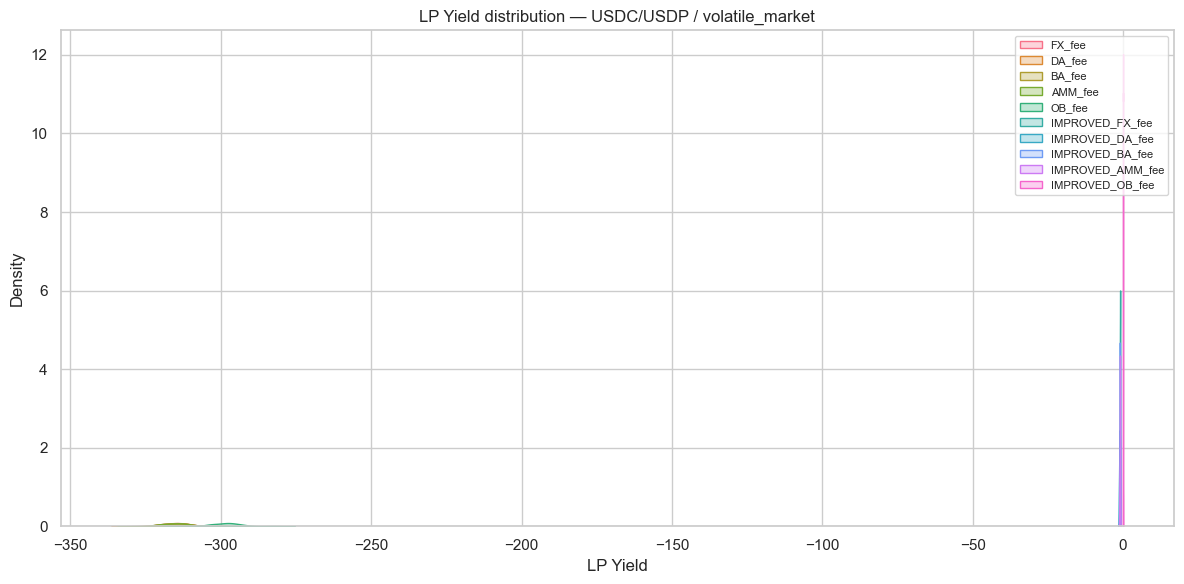

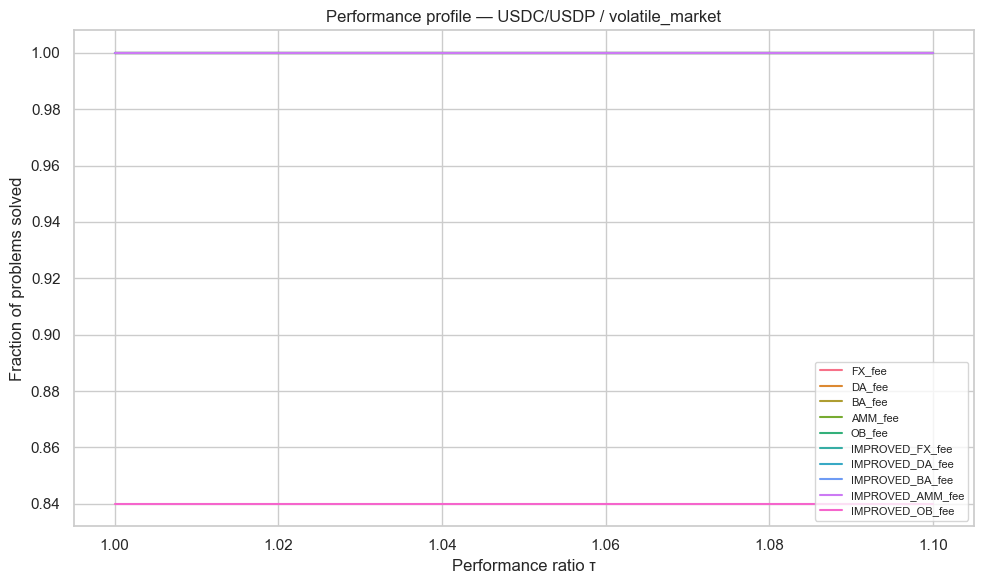

In [19]:
show_stats_for_pair_alias("USDC/USDP", "volatile_market")
plot_yield_stats("USDC/USDP", "volatile_market")
plot_performance_profile("USDC/USDP", "volatile_market")

##### bull_market


=== USDC/USDP / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,4748751.66 ± 5059446.66,5623.54 ± 218.34,100.93 ± 1.19,-7712.62 ± 4961.10,721.46 ± 24.55,-72.63 ± 26.77,-3345855.85 ± 3553624.90,-71.19 ± 1.30,6325574.53 ± 28691886.00
BA_fee,4771884.49 ± 5086350.72,5628.72 ± 217.87,101.13 ± 1.20,-7891.05 ± 5339.46,720.32 ± 24.16,-73.45 ± 26.28,-3393380.98 ± 3597939.98,-71.93 ± 1.23,6341413.27 ± 28700211.53
DA_fee,4774894.24 ± 5089615.05,5624.85 ± 217.54,101.21 ± 1.20,-7904.03 ± 5255.19,720.79 ± 24.47,-73.91 ± 26.72,-3403009.39 ± 3616205.43,-72.14 ± 1.19,6362692.86 ± 28765095.54
FX_fee,4779825.96 ± 5093430.34,5629.99 ± 217.79,101.22 ± 1.20,-7876.10 ± 5301.10,720.80 ± 24.31,-73.52 ± 26.54,-3410460.50 ± 3611639.91,-72.28 ± 1.16,6356487.75 ± 28732236.54
IMPROVED_AMM_fee,4173598.51 ± 4441420.48,5740.85 ± 199.23,117.71 ± 1.78,-7932.57 ± 5268.29,720.53 ± 23.57,-72.89 ± 25.87,-172475.52 ± 189549.47,-4.88 ± 0.33,5771373.41 ± 28182266.42
IMPROVED_BA_fee,4250030.52 ± 4511918.84,5800.27 ± 193.16,118.83 ± 1.72,-7828.67 ± 4757.81,720.69 ± 23.81,-73.19 ± 26.95,-266770.69 ± 271678.57,-7.56 ± 0.26,5851433.32 ± 28251735.98
IMPROVED_DA_fee,4271419.03 ± 4516226.62,5797.67 ± 192.85,119.53 ± 1.74,-8012.35 ± 5408.77,719.89 ± 23.95,-73.63 ± 26.43,-295350.94 ± 290955.40,-8.44 ± 0.84,5881773.74 ± 28271784.70
IMPROVED_FX_fee,4244979.74 ± 4504987.78,5803.30 ± 191.20,118.50 ± 1.75,-7861.82 ± 5172.41,720.22 ± 23.87,-73.24 ± 26.90,-261518.05 ± 268952.75,-7.38 ± 0.22,5847373.57 ± 28247565.78
IMPROVED_OB_fee,4041745.04 ± 4294385.30,5387.89 ± 182.68,118.29 ± 1.82,-7652.80 ± 3934.14,720.58 ± 24.44,-73.41 ± 28.62,23493.28 ± 34597.24,0.58 ± 0.17,5650766.83 ± 28080370.77


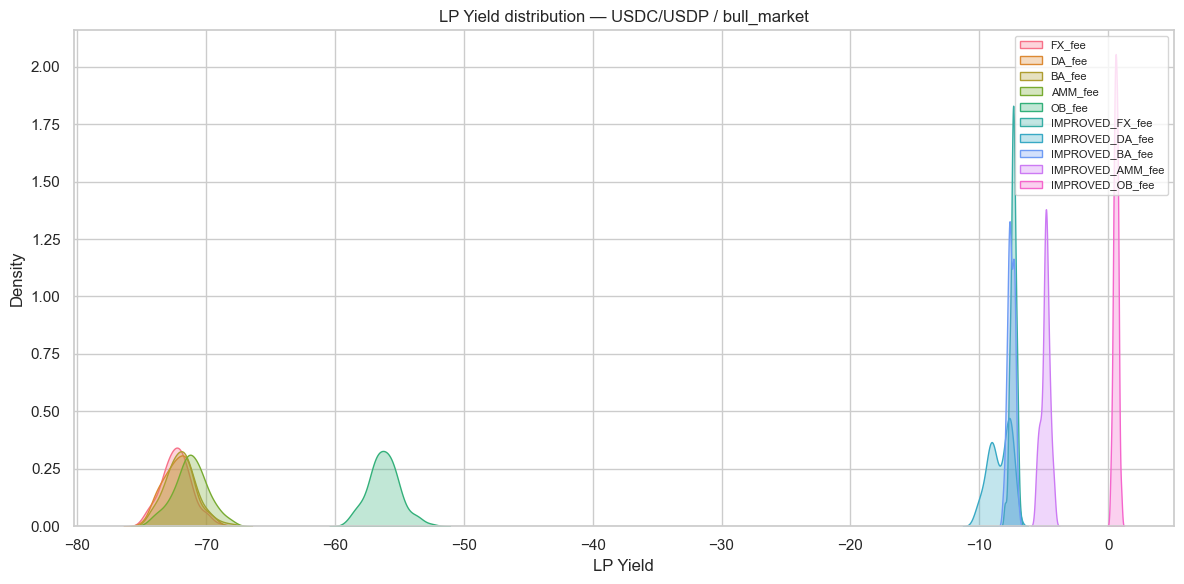

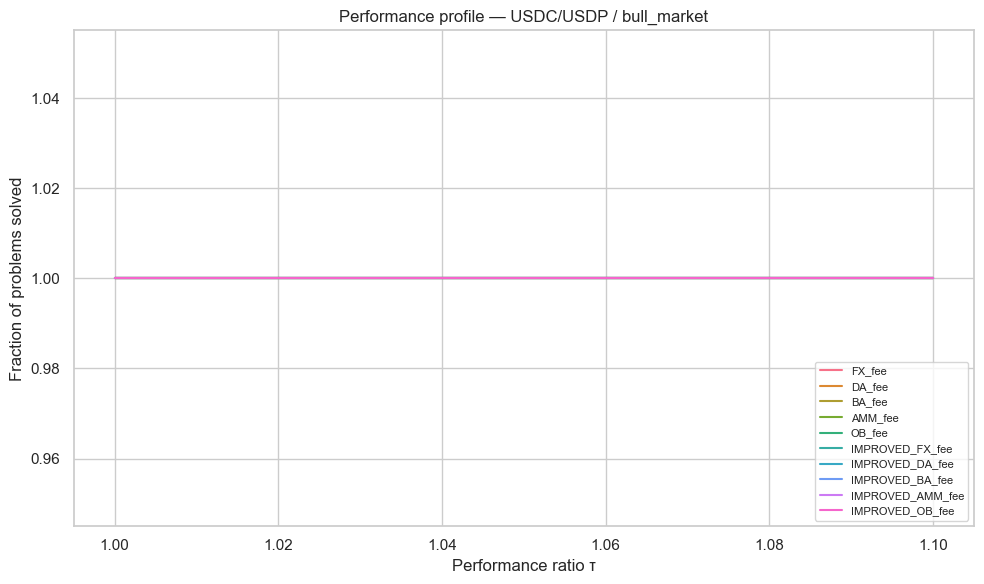

In [20]:
show_stats_for_pair_alias("USDC/USDP", "bull_market")
plot_yield_stats("USDC/USDP", "bull_market")
plot_performance_profile("USDC/USDP", "bull_market")

##### calm_market


=== USDC/USDP / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,1235339.40 ± 1108510.52,4597.64 ± 264.43,55.03 ± 0.74,-7913.01 ± 3642.25,721.05 ± 24.70,-69.39 ± 20.42,-540434.03 ± 474748.53,-24.31 ± 1.15,1663845.75 ± 8350063.16
BA_fee,1266863.44 ± 1143515.94,4622.11 ± 260.64,55.60 ± 0.71,-7990.17 ± 4003.51,721.15 ± 23.60,-69.71 ± 20.85,-599736.26 ± 528303.20,-26.50 ± 0.96,1690004.33 ± 8365728.12
DA_fee,1271415.17 ± 1147766.26,4622.30 ± 260.26,55.72 ± 0.72,-7958.66 ± 4044.63,721.08 ± 23.27,-69.45 ± 20.68,-609765.25 ± 539484.47,-26.89 ± 1.03,1701224.20 ± 8403379.68
FX_fee,1273233.79 ± 1149459.67,4629.10 ± 259.58,55.71 ± 0.72,-7944.63 ± 4087.40,721.10 ± 23.21,-69.28 ± 20.65,-614107.71 ± 543976.42,-27.02 ± 0.83,1698970.53 ± 8382271.38
IMPROVED_AMM_fee,1190331.98 ± 1066144.61,4689.28 ± 249.39,60.30 ± 0.89,-8083.78 ± 4634.51,721.32 ± 24.08,-69.68 ± 20.84,-64945.13 ± 54179.11,-3.48 ± 0.62,1626737.83 ± 8322237.63
IMPROVED_BA_fee,1271822.97 ± 1143478.21,4772.64 ± 246.23,62.80 ± 0.95,-7870.25 ± 3928.47,721.51 ± 24.04,-68.62 ± 20.86,-167128.74 ± 138458.49,-8.43 ± 0.50,1700791.68 ± 8385956.44
IMPROVED_DA_fee,1284081.08 ± 1155061.00,4776.74 ± 245.73,63.24 ± 1.02,-7991.05 ± 4191.83,721.51 ± 23.90,-69.34 ± 20.63,-185465.22 ± 159490.88,-9.25 ± 0.64,1718299.66 ± 8417777.52
IMPROVED_FX_fee,1276915.84 ± 1149502.47,4781.18 ± 247.18,62.83 ± 0.97,-7888.48 ± 3978.28,721.91 ± 24.73,-68.63 ± 20.69,-174909.08 ± 147872.82,-8.75 ± 0.33,1707129.18 ± 8393625.31
IMPROVED_OB_fee,1108231.58 ± 998163.02,4169.24 ± 224.48,61.76 ± 0.98,-8019.07 ± 3840.82,721.87 ± 23.48,-69.95 ± 21.38,85360.53 ± 81475.94,4.54 ± 0.40,1544381.08 ± 8253928.16


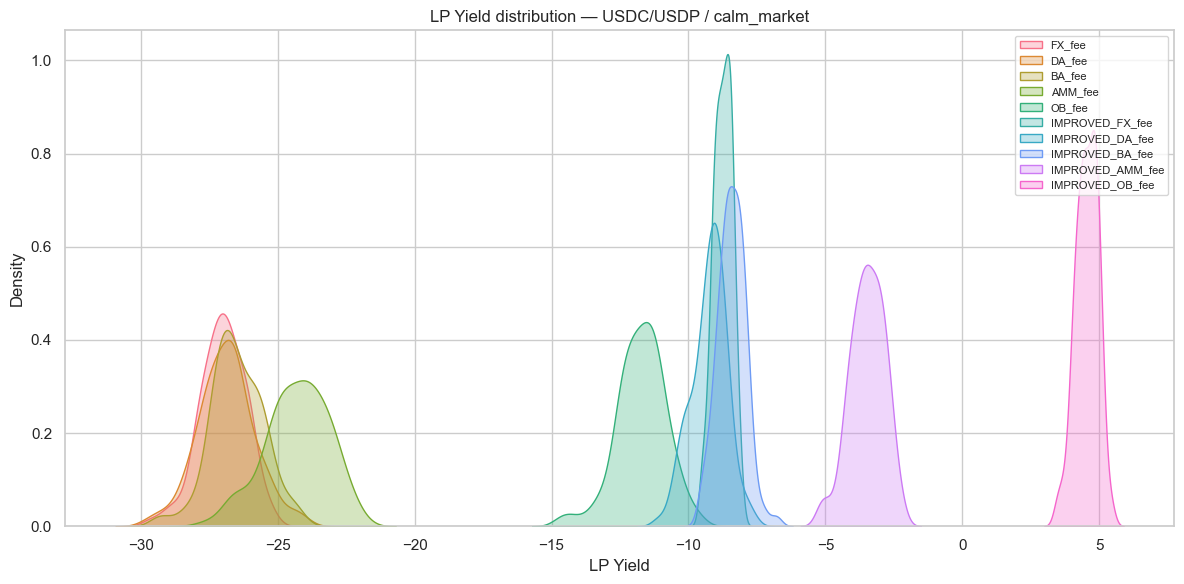

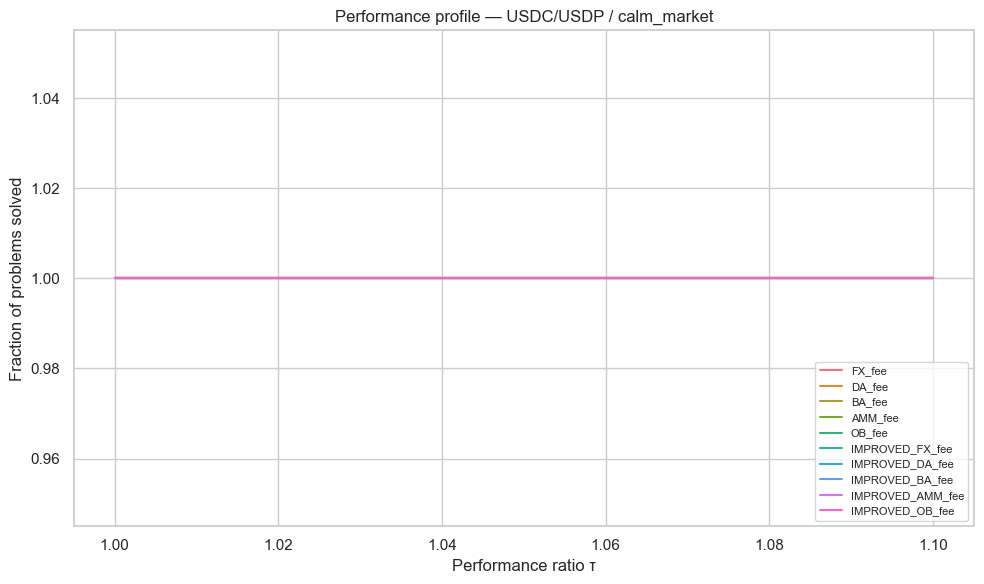

In [21]:
show_stats_for_pair_alias("USDC/USDP", "calm_market")
plot_yield_stats("USDC/USDP", "calm_market")
plot_performance_profile("USDC/USDP", "calm_market")

##### bear_market


=== USDC/USDP / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,2229263.62 ± 2074686.07,5104.82 ± 240.19,71.83 ± 0.87,-7906.29 ± 4252.66,720.88 ± 24.43,-70.94 ± 22.17,-1287382.67 ± 1188636.98,-41.62 ± 1.16,3133786.84 ± 15059002.77
BA_fee,2257642.66 ± 2101832.91,5118.57 ± 235.28,72.20 ± 0.92,-7804.63 ± 3629.73,720.77 ± 24.53,-71.53 ± 23.13,-1343498.11 ± 1236650.62,-43.03 ± 1.00,3157756.55 ± 15084104.39
DA_fee,2261942.00 ± 2107034.39,5114.37 ± 236.62,72.30 ± 0.92,-7846.91 ± 3861.07,720.68 ± 24.49,-71.56 ± 22.91,-1355421.27 ± 1254676.78,-43.37 ± 0.94,3175043.40 ± 15124301.75
FX_fee,2264728.90 ± 2108394.13,5121.27 ± 236.59,72.30 ± 0.92,-7788.96 ± 3802.31,720.86 ± 24.62,-71.23 ± 23.20,-1358657.51 ± 1248768.06,-43.47 ± 0.91,3168202.52 ± 15098661.72
IMPROVED_AMM_fee,2075320.34 ± 1926288.60,5216.51 ± 227.23,81.79 ± 1.33,-7883.01 ± 3909.17,720.88 ± 24.89,-70.89 ± 21.84,-121019.97 ± 112043.70,-4.86 ± 0.49,2990394.58 ± 14930201.00
IMPROVED_BA_fee,2168866.55 ± 2005096.57,5294.59 ± 213.79,83.99 ± 1.35,-7772.68 ± 3970.91,721.24 ± 24.28,-70.98 ± 23.78,-234198.82 ± 203608.38,-9.19 ± 0.33,3077211.98 ± 15001620.74
IMPROVED_DA_fee,2186864.55 ± 2015296.90,5293.30 ± 216.47,84.68 ± 1.30,-7830.36 ± 3820.14,722.07 ± 23.18,-71.08 ± 23.00,-260980.10 ± 227418.55,-10.26 ± 0.86,3104436.14 ± 15028947.13
IMPROVED_FX_fee,2170407.51 ± 2007861.84,5299.62 ± 215.51,83.87 ± 1.33,-7877.55 ± 3850.91,722.26 ± 23.19,-71.67 ± 23.46,-237090.71 ± 210070.05,-9.26 ± 0.25,3081052.63 ± 15007408.58
IMPROVED_OB_fee,1966662.52 ± 1822297.00,4764.15 ± 200.91,82.74 ± 1.36,-7872.17 ± 4217.66,721.30 ± 23.99,-70.92 ± 23.89,53018.24 ± 56179.62,2.09 ± 0.26,2889969.79 ± 14853973.06


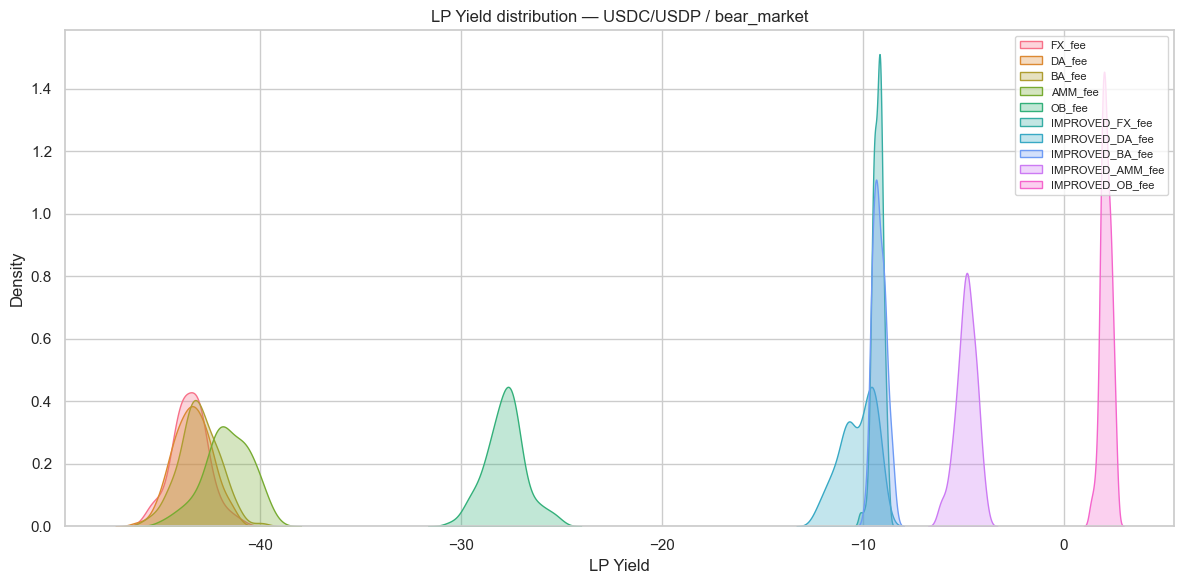

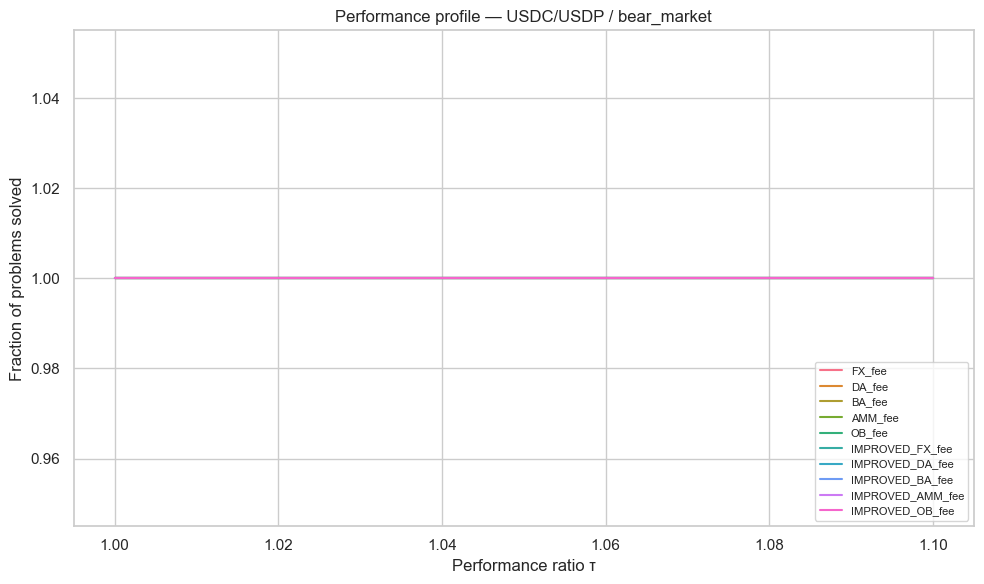

In [22]:
show_stats_for_pair_alias("USDC/USDP", "bear_market")
plot_yield_stats("USDC/USDP", "bear_market")
plot_performance_profile("USDC/USDP", "bear_market")

### Non-stable / Stable

#### USDC/RAD

##### volatile_market


=== USDC/RAD / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,36351875.83 ± 52051863.57,6136.67 ± 741.61,343.02 ± 5.13,-5341.43 ± 3946.00,715.04 ± 24.56,-134.84 ± 114.56,-33354791.20 ± 47759509.61,-314.76 ± 5.28,10346611.57 ± 9072955.69
BA_fee,36380425.74 ± 52174265.34,6136.21 ± 737.77,343.01 ± 5.05,-5467.90 ± 4235.05,715.62 ± 24.21,-135.92 ± 116.22,-33391371.49 ± 47875095.34,-314.71 ± 5.14,10367175.53 ± 9071091.30
DA_fee,36400234.00 ± 52247606.65,6133.55 ± 740.36,343.02 ± 5.05,-5465.85 ± 4198.78,715.40 ± 24.18,-135.88 ± 116.25,-33395761.67 ± 47915709.98,-314.88 ± 5.07,10379518.88 ± 9066872.01
FX_fee,36382643.49 ± 52167994.36,6135.45 ± 739.43,343.04 ± 5.05,-5467.92 ± 4210.13,715.62 ± 24.11,-136.05 ± 116.22,-33397842.35 ± 47879897.82,-314.92 ± 5.07,10388793.89 ± 9081601.39
IMPROVED_AMM_fee,34951490.58 ± 56822782.13,6323.30 ± 691.12,399.23 ± 7.47,-5464.56 ± 8279.04,713.80 ± 25.86,-118.45 ± 113.45,-91977.91 ± 151688.58,-1.04 ± 0.09,5283568.17 ± 18657567.39
IMPROVED_BA_fee,34946925.26 ± 56777597.76,6334.93 ± 691.14,398.95 ± 7.48,-5405.61 ± 7502.29,712.72 ± 24.95,-117.01 ± 114.77,-91732.74 ± 140505.36,-1.07 ± 0.08,5284493.85 ± 18653446.36
IMPROVED_DA_fee,34952019.94 ± 56794518.57,6334.57 ± 689.90,399.07 ± 7.54,-6522.61 ± 8660.63,713.08 ± 24.99,-122.65 ± 114.47,-99927.28 ± 161531.36,-1.16 ± 0.14,5286645.74 ± 18650652.45
IMPROVED_FX_fee,34946880.13 ± 56778947.99,6335.35 ± 691.66,398.81 ± 7.51,-5339.41 ± 7400.65,713.30 ± 25.14,-120.15 ± 115.65,-87910.14 ± 139013.56,-1.01 ± 0.06,5282310.44 ± 18658272.26
IMPROVED_OB_fee,34933782.22 ± 56807083.07,6218.63 ± 669.31,400.11 ± 7.54,-5394.12 ± 6514.70,714.18 ± 24.73,-120.66 ± 116.69,53.58 ± 3462.80,-0.02 ± 0.03,5244784.97 ± 18780368.17


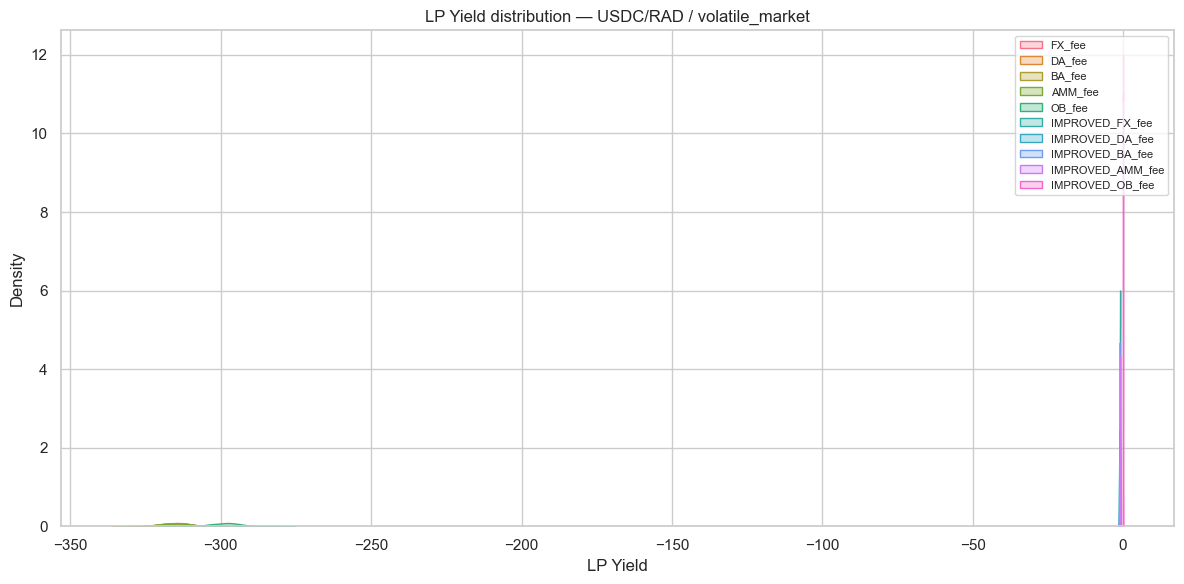

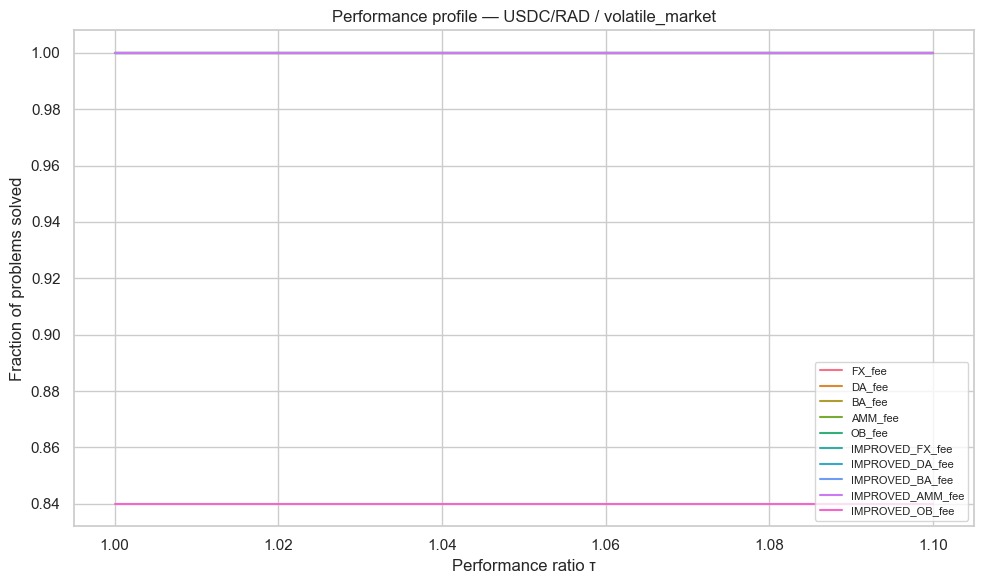

In [23]:
show_stats_for_pair_alias("USDC/RAD", "volatile_market")
plot_yield_stats("USDC/RAD", "volatile_market")
plot_performance_profile("USDC/RAD", "volatile_market")

##### bull_market


=== USDC/RAD / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,4748751.66 ± 5059446.66,5623.54 ± 218.34,100.93 ± 1.19,-7712.62 ± 4961.10,721.46 ± 24.55,-72.63 ± 26.77,-3345855.85 ± 3553624.90,-71.19 ± 1.30,6325574.53 ± 28691886.00
BA_fee,4771884.49 ± 5086350.72,5628.72 ± 217.87,101.13 ± 1.20,-7891.05 ± 5339.46,720.32 ± 24.16,-73.45 ± 26.28,-3393380.98 ± 3597939.98,-71.93 ± 1.23,6341413.27 ± 28700211.53
DA_fee,4774894.24 ± 5089615.05,5624.85 ± 217.54,101.21 ± 1.20,-7904.03 ± 5255.19,720.79 ± 24.47,-73.91 ± 26.72,-3403009.39 ± 3616205.43,-72.14 ± 1.19,6362692.86 ± 28765095.54
FX_fee,4779825.96 ± 5093430.34,5629.99 ± 217.79,101.22 ± 1.20,-7876.10 ± 5301.10,720.80 ± 24.31,-73.52 ± 26.54,-3410460.50 ± 3611639.91,-72.28 ± 1.16,6356487.75 ± 28732236.54
IMPROVED_AMM_fee,4173598.51 ± 4441420.48,5740.85 ± 199.23,117.71 ± 1.78,-7932.57 ± 5268.29,720.53 ± 23.57,-72.89 ± 25.87,-172475.52 ± 189549.47,-4.88 ± 0.33,5771373.41 ± 28182266.42
IMPROVED_BA_fee,4250030.52 ± 4511918.84,5800.27 ± 193.16,118.83 ± 1.72,-7828.67 ± 4757.81,720.69 ± 23.81,-73.19 ± 26.95,-266770.69 ± 271678.57,-7.56 ± 0.26,5851433.32 ± 28251735.98
IMPROVED_DA_fee,4271419.03 ± 4516226.62,5797.67 ± 192.85,119.53 ± 1.74,-8012.35 ± 5408.77,719.89 ± 23.95,-73.63 ± 26.43,-295350.94 ± 290955.40,-8.44 ± 0.84,5881773.74 ± 28271784.70
IMPROVED_FX_fee,4244979.74 ± 4504987.78,5803.30 ± 191.20,118.50 ± 1.75,-7861.82 ± 5172.41,720.22 ± 23.87,-73.24 ± 26.90,-261518.05 ± 268952.75,-7.38 ± 0.22,5847373.57 ± 28247565.78
IMPROVED_OB_fee,4041745.04 ± 4294385.30,5387.89 ± 182.68,118.29 ± 1.82,-7652.80 ± 3934.14,720.58 ± 24.44,-73.41 ± 28.62,23493.28 ± 34597.24,0.58 ± 0.17,5650766.83 ± 28080370.77


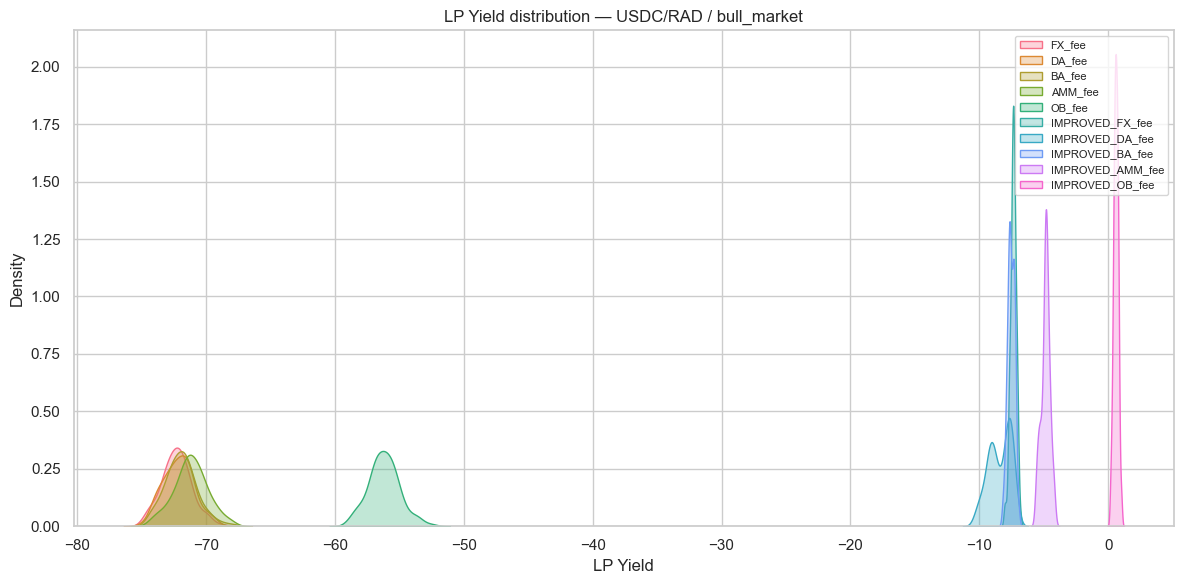

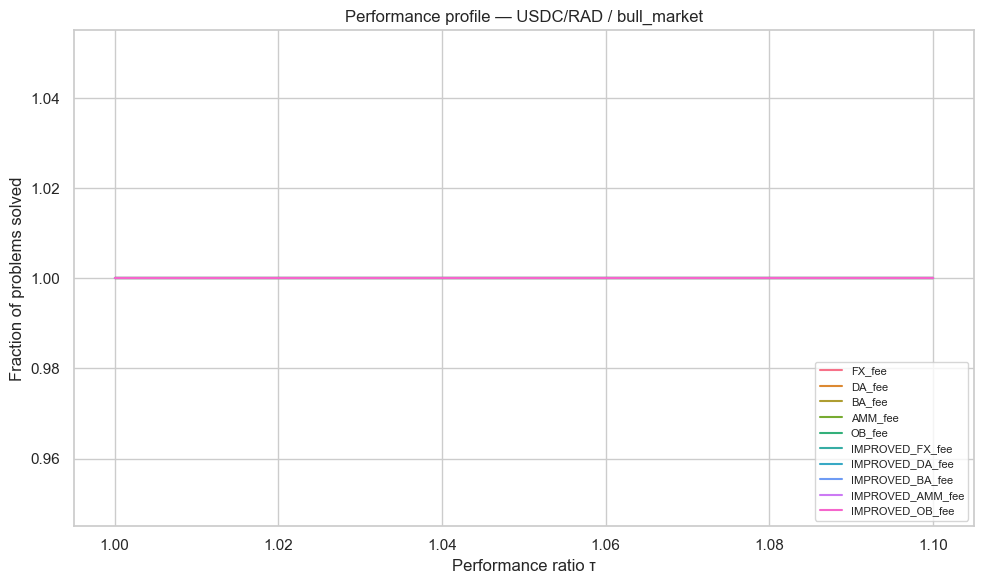

In [24]:
show_stats_for_pair_alias("USDC/RAD", "bull_market")
plot_yield_stats("USDC/RAD", "bull_market")
plot_performance_profile("USDC/RAD", "bull_market")

##### calm_market


=== USDC/RAD / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,1235339.40 ± 1108510.52,4597.64 ± 264.43,55.03 ± 0.74,-7913.01 ± 3642.25,721.05 ± 24.70,-69.39 ± 20.42,-540434.03 ± 474748.53,-24.31 ± 1.15,1663845.75 ± 8350063.16
BA_fee,1266863.44 ± 1143515.94,4622.11 ± 260.64,55.60 ± 0.71,-7990.17 ± 4003.51,721.15 ± 23.60,-69.71 ± 20.85,-599736.26 ± 528303.20,-26.50 ± 0.96,1690004.33 ± 8365728.12
DA_fee,1271415.17 ± 1147766.26,4622.30 ± 260.26,55.72 ± 0.72,-7958.66 ± 4044.63,721.08 ± 23.27,-69.45 ± 20.68,-609765.25 ± 539484.47,-26.89 ± 1.03,1701224.20 ± 8403379.68
FX_fee,1273233.79 ± 1149459.67,4629.10 ± 259.58,55.71 ± 0.72,-7944.63 ± 4087.40,721.10 ± 23.21,-69.28 ± 20.65,-614107.71 ± 543976.42,-27.02 ± 0.83,1698970.53 ± 8382271.38
IMPROVED_AMM_fee,1190331.98 ± 1066144.61,4689.28 ± 249.39,60.30 ± 0.89,-8083.78 ± 4634.51,721.32 ± 24.08,-69.68 ± 20.84,-64945.13 ± 54179.11,-3.48 ± 0.62,1626737.83 ± 8322237.63
IMPROVED_BA_fee,1271822.97 ± 1143478.21,4772.64 ± 246.23,62.80 ± 0.95,-7870.25 ± 3928.47,721.51 ± 24.04,-68.62 ± 20.86,-167128.74 ± 138458.49,-8.43 ± 0.50,1700791.68 ± 8385956.44
IMPROVED_DA_fee,1284081.08 ± 1155061.00,4776.74 ± 245.73,63.24 ± 1.02,-7991.05 ± 4191.83,721.51 ± 23.90,-69.34 ± 20.63,-185465.22 ± 159490.88,-9.25 ± 0.64,1718299.66 ± 8417777.52
IMPROVED_FX_fee,1276915.84 ± 1149502.47,4781.18 ± 247.18,62.83 ± 0.97,-7888.48 ± 3978.28,721.91 ± 24.73,-68.63 ± 20.69,-174909.08 ± 147872.82,-8.75 ± 0.33,1707129.18 ± 8393625.31
IMPROVED_OB_fee,1108231.58 ± 998163.02,4169.24 ± 224.48,61.76 ± 0.98,-8019.07 ± 3840.82,721.87 ± 23.48,-69.95 ± 21.38,85360.53 ± 81475.94,4.54 ± 0.40,1544381.08 ± 8253928.16


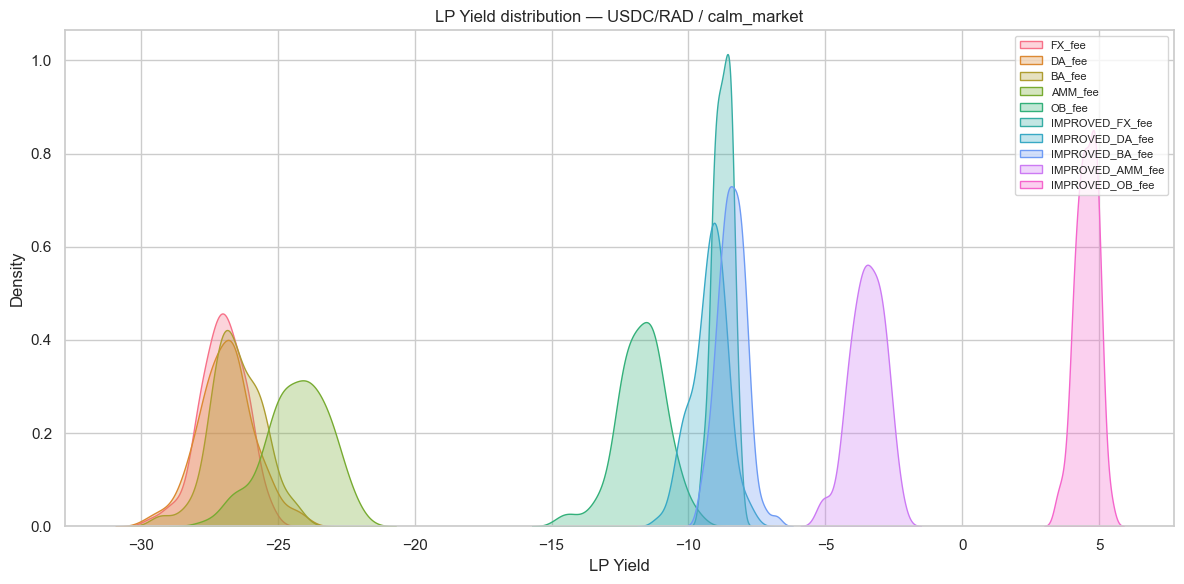

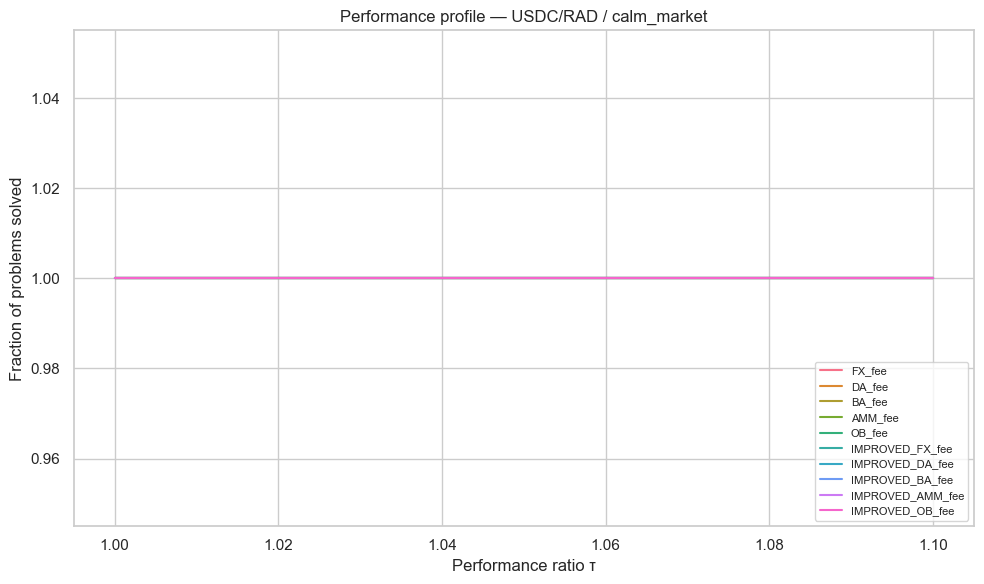

In [25]:
show_stats_for_pair_alias("USDC/RAD", "calm_market")
plot_yield_stats("USDC/RAD", "calm_market")
plot_performance_profile("USDC/RAD", "calm_market")

##### bear_market


=== USDC/RAD / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,2229263.62 ± 2074686.07,5104.82 ± 240.19,71.83 ± 0.87,-7906.29 ± 4252.66,720.88 ± 24.43,-70.94 ± 22.17,-1287382.67 ± 1188636.98,-41.62 ± 1.16,3133786.84 ± 15059002.77
BA_fee,2257642.66 ± 2101832.91,5118.57 ± 235.28,72.20 ± 0.92,-7804.63 ± 3629.73,720.77 ± 24.53,-71.53 ± 23.13,-1343498.11 ± 1236650.62,-43.03 ± 1.00,3157756.55 ± 15084104.39
DA_fee,2261942.00 ± 2107034.39,5114.37 ± 236.62,72.30 ± 0.92,-7846.91 ± 3861.07,720.68 ± 24.49,-71.56 ± 22.91,-1355421.27 ± 1254676.78,-43.37 ± 0.94,3175043.40 ± 15124301.75
FX_fee,2264728.90 ± 2108394.13,5121.27 ± 236.59,72.30 ± 0.92,-7788.96 ± 3802.31,720.86 ± 24.62,-71.23 ± 23.20,-1358657.51 ± 1248768.06,-43.47 ± 0.91,3168202.52 ± 15098661.72
IMPROVED_AMM_fee,2075320.34 ± 1926288.60,5216.51 ± 227.23,81.79 ± 1.33,-7883.01 ± 3909.17,720.88 ± 24.89,-70.89 ± 21.84,-121019.97 ± 112043.70,-4.86 ± 0.49,2990394.58 ± 14930201.00
IMPROVED_BA_fee,2168866.55 ± 2005096.57,5294.59 ± 213.79,83.99 ± 1.35,-7772.68 ± 3970.91,721.24 ± 24.28,-70.98 ± 23.78,-234198.82 ± 203608.38,-9.19 ± 0.33,3077211.98 ± 15001620.74
IMPROVED_DA_fee,2186864.55 ± 2015296.90,5293.30 ± 216.47,84.68 ± 1.30,-7830.36 ± 3820.14,722.07 ± 23.18,-71.08 ± 23.00,-260980.10 ± 227418.55,-10.26 ± 0.86,3104436.14 ± 15028947.13
IMPROVED_FX_fee,2170407.51 ± 2007861.84,5299.62 ± 215.51,83.87 ± 1.33,-7877.55 ± 3850.91,722.26 ± 23.19,-71.67 ± 23.46,-237090.71 ± 210070.05,-9.26 ± 0.25,3081052.63 ± 15007408.58
IMPROVED_OB_fee,1966662.52 ± 1822297.00,4764.15 ± 200.91,82.74 ± 1.36,-7872.17 ± 4217.66,721.30 ± 23.99,-70.92 ± 23.89,53018.24 ± 56179.62,2.09 ± 0.26,2889969.79 ± 14853973.06


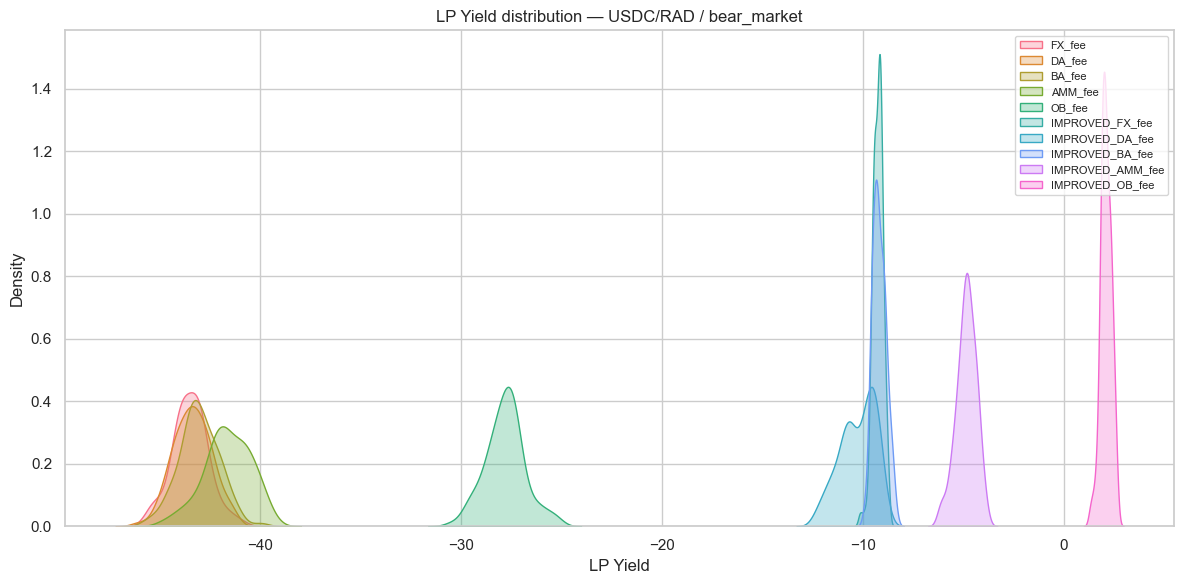

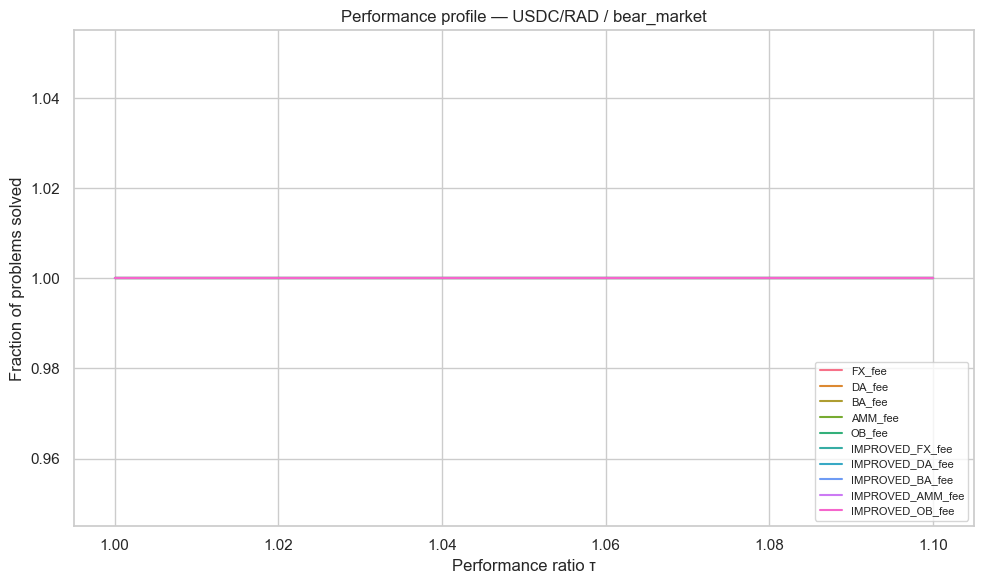

In [26]:
show_stats_for_pair_alias("USDC/RAD", "bear_market")
plot_yield_stats("USDC/RAD", "bear_market")
plot_performance_profile("USDC/RAD", "bear_market")

#### ETH/USDT

##### volatile_market


=== ETH/USDT / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,36351875.83 ± 52051863.57,6136.67 ± 741.61,343.02 ± 5.13,-5341.43 ± 3946.00,715.04 ± 24.56,-134.84 ± 114.56,-33354791.20 ± 47759509.61,-314.76 ± 5.28,10346611.57 ± 9072955.69
BA_fee,36380425.74 ± 52174265.34,6136.21 ± 737.77,343.01 ± 5.05,-5467.90 ± 4235.05,715.62 ± 24.21,-135.92 ± 116.22,-33391371.49 ± 47875095.34,-314.71 ± 5.14,10367175.53 ± 9071091.30
DA_fee,36400234.00 ± 52247606.65,6133.55 ± 740.36,343.02 ± 5.05,-5465.85 ± 4198.78,715.40 ± 24.18,-135.88 ± 116.25,-33395761.67 ± 47915709.98,-314.88 ± 5.07,10379518.88 ± 9066872.01
FX_fee,36382643.49 ± 52167994.36,6135.45 ± 739.43,343.04 ± 5.05,-5467.92 ± 4210.13,715.62 ± 24.11,-136.05 ± 116.22,-33397842.35 ± 47879897.82,-314.92 ± 5.07,10388793.89 ± 9081601.39
IMPROVED_AMM_fee,34951490.58 ± 56822782.13,6323.30 ± 691.12,399.23 ± 7.47,-5464.56 ± 8279.04,713.80 ± 25.86,-118.45 ± 113.45,-91977.91 ± 151688.58,-1.04 ± 0.09,5283568.17 ± 18657567.39
IMPROVED_BA_fee,34946925.26 ± 56777597.76,6334.93 ± 691.14,398.95 ± 7.48,-5405.61 ± 7502.29,712.72 ± 24.95,-117.01 ± 114.77,-91732.74 ± 140505.36,-1.07 ± 0.08,5284493.85 ± 18653446.36
IMPROVED_DA_fee,34952019.94 ± 56794518.57,6334.57 ± 689.90,399.07 ± 7.54,-6522.61 ± 8660.63,713.08 ± 24.99,-122.65 ± 114.47,-99927.28 ± 161531.36,-1.16 ± 0.14,5286645.74 ± 18650652.45
IMPROVED_FX_fee,34946880.13 ± 56778947.99,6335.35 ± 691.66,398.81 ± 7.51,-5339.41 ± 7400.65,713.30 ± 25.14,-120.15 ± 115.65,-87910.14 ± 139013.56,-1.01 ± 0.06,5282310.44 ± 18658272.26
IMPROVED_OB_fee,34933782.22 ± 56807083.07,6218.63 ± 669.31,400.11 ± 7.54,-5394.12 ± 6514.70,714.18 ± 24.73,-120.66 ± 116.69,53.58 ± 3462.80,-0.02 ± 0.03,5244784.97 ± 18780368.17


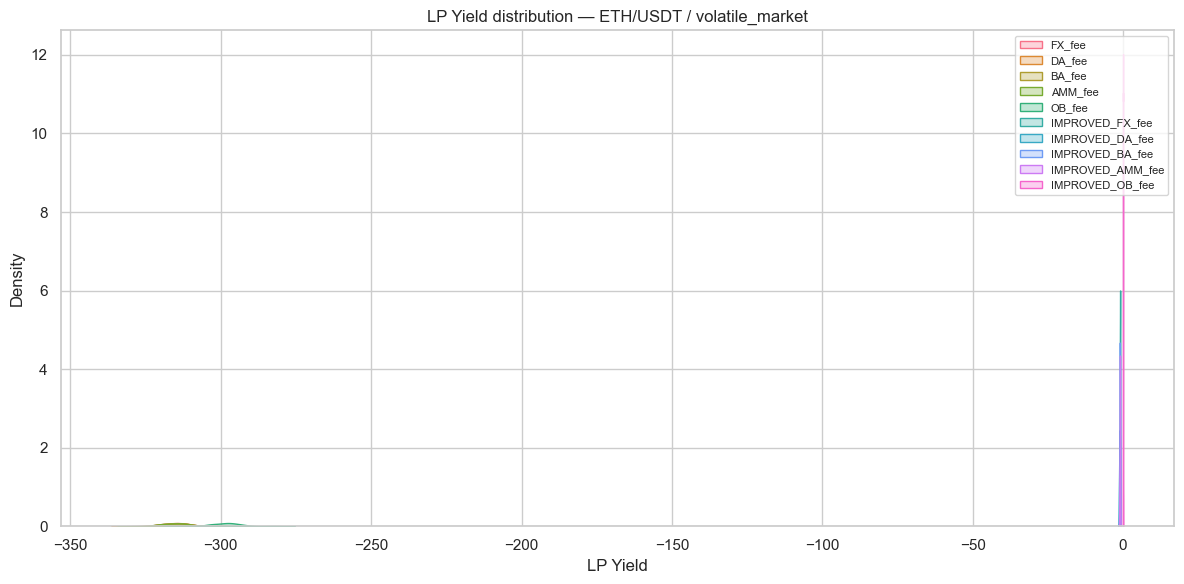

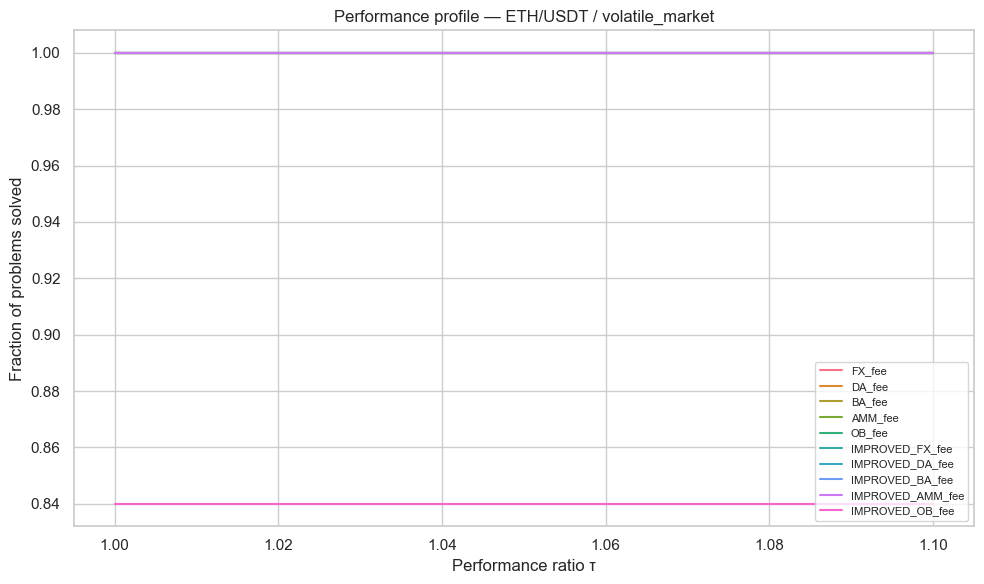

In [27]:
show_stats_for_pair_alias("ETH/USDT", "volatile_market")
plot_yield_stats("ETH/USDT", "volatile_market")
plot_performance_profile("ETH/USDT", "volatile_market")

##### bull_market


=== ETH/USDT / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,4748751.66 ± 5059446.66,5623.54 ± 218.34,100.93 ± 1.19,-7712.62 ± 4961.10,721.46 ± 24.55,-72.63 ± 26.77,-3345855.85 ± 3553624.90,-71.19 ± 1.30,6325574.53 ± 28691886.00
BA_fee,4771884.49 ± 5086350.72,5628.72 ± 217.87,101.13 ± 1.20,-7891.05 ± 5339.46,720.32 ± 24.16,-73.45 ± 26.28,-3393380.98 ± 3597939.98,-71.93 ± 1.23,6341413.27 ± 28700211.53
DA_fee,4774894.24 ± 5089615.05,5624.85 ± 217.54,101.21 ± 1.20,-7904.03 ± 5255.19,720.79 ± 24.47,-73.91 ± 26.72,-3403009.39 ± 3616205.43,-72.14 ± 1.19,6362692.86 ± 28765095.54
FX_fee,4779825.96 ± 5093430.34,5629.99 ± 217.79,101.22 ± 1.20,-7876.10 ± 5301.10,720.80 ± 24.31,-73.52 ± 26.54,-3410460.50 ± 3611639.91,-72.28 ± 1.16,6356487.75 ± 28732236.54
IMPROVED_AMM_fee,4173598.51 ± 4441420.48,5740.85 ± 199.23,117.71 ± 1.78,-7932.57 ± 5268.29,720.53 ± 23.57,-72.89 ± 25.87,-172475.52 ± 189549.47,-4.88 ± 0.33,5771373.41 ± 28182266.42
IMPROVED_BA_fee,4250030.52 ± 4511918.84,5800.27 ± 193.16,118.83 ± 1.72,-7828.67 ± 4757.81,720.69 ± 23.81,-73.19 ± 26.95,-266770.69 ± 271678.57,-7.56 ± 0.26,5851433.32 ± 28251735.98
IMPROVED_DA_fee,4271419.03 ± 4516226.62,5797.67 ± 192.85,119.53 ± 1.74,-8012.35 ± 5408.77,719.89 ± 23.95,-73.63 ± 26.43,-295350.94 ± 290955.40,-8.44 ± 0.84,5881773.74 ± 28271784.70
IMPROVED_FX_fee,4244979.74 ± 4504987.78,5803.30 ± 191.20,118.50 ± 1.75,-7861.82 ± 5172.41,720.22 ± 23.87,-73.24 ± 26.90,-261518.05 ± 268952.75,-7.38 ± 0.22,5847373.57 ± 28247565.78
IMPROVED_OB_fee,4041745.04 ± 4294385.30,5387.89 ± 182.68,118.29 ± 1.82,-7652.80 ± 3934.14,720.58 ± 24.44,-73.41 ± 28.62,23493.28 ± 34597.24,0.58 ± 0.17,5650766.83 ± 28080370.77


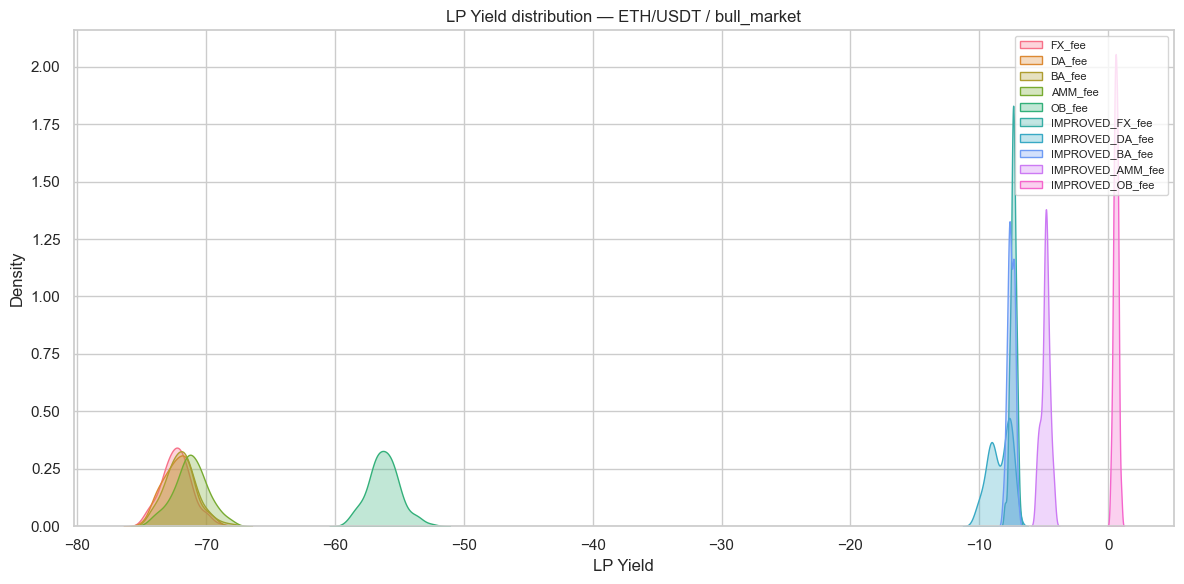

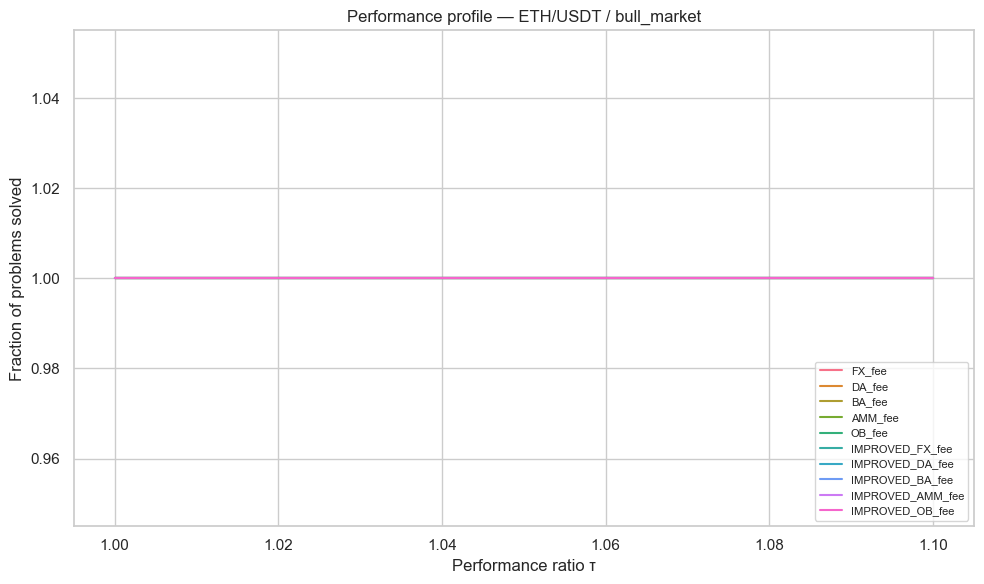

In [28]:
show_stats_for_pair_alias("ETH/USDT", "bull_market")
plot_yield_stats("ETH/USDT", "bull_market")
plot_performance_profile("ETH/USDT", "bull_market")

##### calm_market


=== ETH/USDT / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,1235339.40 ± 1108510.52,4597.64 ± 264.43,55.03 ± 0.74,-7913.01 ± 3642.25,721.05 ± 24.70,-69.39 ± 20.42,-540434.03 ± 474748.53,-24.31 ± 1.15,1663845.75 ± 8350063.16
BA_fee,1266863.44 ± 1143515.94,4622.11 ± 260.64,55.60 ± 0.71,-7990.17 ± 4003.51,721.15 ± 23.60,-69.71 ± 20.85,-599736.26 ± 528303.20,-26.50 ± 0.96,1690004.33 ± 8365728.12
DA_fee,1271415.17 ± 1147766.26,4622.30 ± 260.26,55.72 ± 0.72,-7958.66 ± 4044.63,721.08 ± 23.27,-69.45 ± 20.68,-609765.25 ± 539484.47,-26.89 ± 1.03,1701224.20 ± 8403379.68
FX_fee,1273233.79 ± 1149459.67,4629.10 ± 259.58,55.71 ± 0.72,-7944.63 ± 4087.40,721.10 ± 23.21,-69.28 ± 20.65,-614107.71 ± 543976.42,-27.02 ± 0.83,1698970.53 ± 8382271.38
IMPROVED_AMM_fee,1190331.98 ± 1066144.61,4689.28 ± 249.39,60.30 ± 0.89,-8083.78 ± 4634.51,721.32 ± 24.08,-69.68 ± 20.84,-64945.13 ± 54179.11,-3.48 ± 0.62,1626737.83 ± 8322237.63
IMPROVED_BA_fee,1271822.97 ± 1143478.21,4772.64 ± 246.23,62.80 ± 0.95,-7870.25 ± 3928.47,721.51 ± 24.04,-68.62 ± 20.86,-167128.74 ± 138458.49,-8.43 ± 0.50,1700791.68 ± 8385956.44
IMPROVED_DA_fee,1284081.08 ± 1155061.00,4776.74 ± 245.73,63.24 ± 1.02,-7991.05 ± 4191.83,721.51 ± 23.90,-69.34 ± 20.63,-185465.22 ± 159490.88,-9.25 ± 0.64,1718299.66 ± 8417777.52
IMPROVED_FX_fee,1276915.84 ± 1149502.47,4781.18 ± 247.18,62.83 ± 0.97,-7888.48 ± 3978.28,721.91 ± 24.73,-68.63 ± 20.69,-174909.08 ± 147872.82,-8.75 ± 0.33,1707129.18 ± 8393625.31
IMPROVED_OB_fee,1108231.58 ± 998163.02,4169.24 ± 224.48,61.76 ± 0.98,-8019.07 ± 3840.82,721.87 ± 23.48,-69.95 ± 21.38,85360.53 ± 81475.94,4.54 ± 0.40,1544381.08 ± 8253928.16


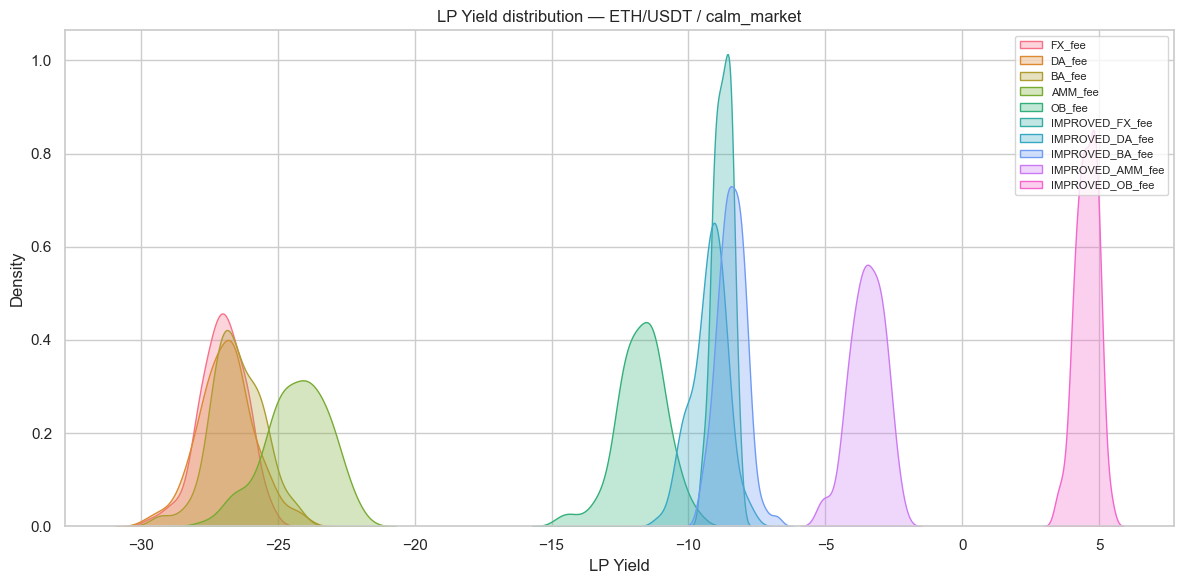

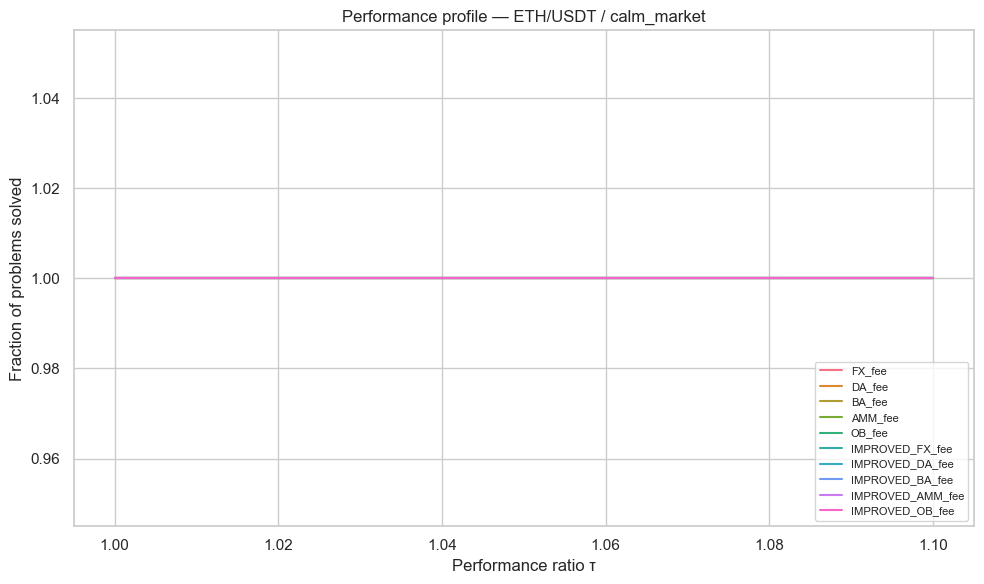

In [29]:
show_stats_for_pair_alias("ETH/USDT", "calm_market")
plot_yield_stats("ETH/USDT", "calm_market")
plot_performance_profile("ETH/USDT", "calm_market")

##### bear_market


=== ETH/USDT / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,2229263.62 ± 2074686.07,5104.82 ± 240.19,71.83 ± 0.87,-7906.29 ± 4252.66,720.88 ± 24.43,-70.94 ± 22.17,-1287382.67 ± 1188636.98,-41.62 ± 1.16,3133786.84 ± 15059002.77
BA_fee,2257642.66 ± 2101832.91,5118.57 ± 235.28,72.20 ± 0.92,-7804.63 ± 3629.73,720.77 ± 24.53,-71.53 ± 23.13,-1343498.11 ± 1236650.62,-43.03 ± 1.00,3157756.55 ± 15084104.39
DA_fee,2261942.00 ± 2107034.39,5114.37 ± 236.62,72.30 ± 0.92,-7846.91 ± 3861.07,720.68 ± 24.49,-71.56 ± 22.91,-1355421.27 ± 1254676.78,-43.37 ± 0.94,3175043.40 ± 15124301.75
FX_fee,2264728.90 ± 2108394.13,5121.27 ± 236.59,72.30 ± 0.92,-7788.96 ± 3802.31,720.86 ± 24.62,-71.23 ± 23.20,-1358657.51 ± 1248768.06,-43.47 ± 0.91,3168202.52 ± 15098661.72
IMPROVED_AMM_fee,2075320.34 ± 1926288.60,5216.51 ± 227.23,81.79 ± 1.33,-7883.01 ± 3909.17,720.88 ± 24.89,-70.89 ± 21.84,-121019.97 ± 112043.70,-4.86 ± 0.49,2990394.58 ± 14930201.00
IMPROVED_BA_fee,2168866.55 ± 2005096.57,5294.59 ± 213.79,83.99 ± 1.35,-7772.68 ± 3970.91,721.24 ± 24.28,-70.98 ± 23.78,-234198.82 ± 203608.38,-9.19 ± 0.33,3077211.98 ± 15001620.74
IMPROVED_DA_fee,2186864.55 ± 2015296.90,5293.30 ± 216.47,84.68 ± 1.30,-7830.36 ± 3820.14,722.07 ± 23.18,-71.08 ± 23.00,-260980.10 ± 227418.55,-10.26 ± 0.86,3104436.14 ± 15028947.13
IMPROVED_FX_fee,2170407.51 ± 2007861.84,5299.62 ± 215.51,83.87 ± 1.33,-7877.55 ± 3850.91,722.26 ± 23.19,-71.67 ± 23.46,-237090.71 ± 210070.05,-9.26 ± 0.25,3081052.63 ± 15007408.58
IMPROVED_OB_fee,1966662.52 ± 1822297.00,4764.15 ± 200.91,82.74 ± 1.36,-7872.17 ± 4217.66,721.30 ± 23.99,-70.92 ± 23.89,53018.24 ± 56179.62,2.09 ± 0.26,2889969.79 ± 14853973.06


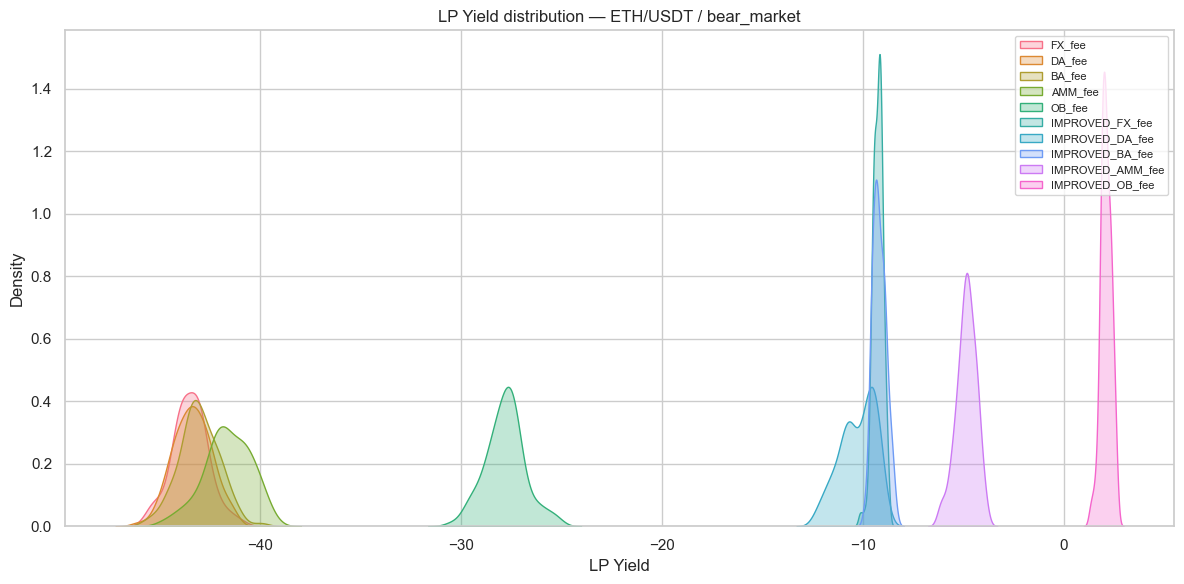

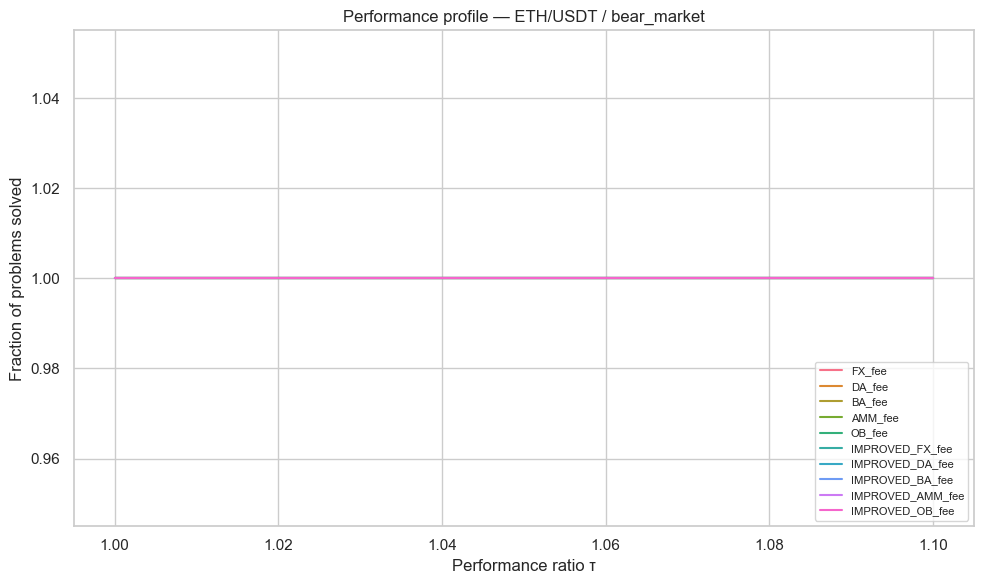

In [30]:
show_stats_for_pair_alias("ETH/USDT", "bear_market")
plot_yield_stats("ETH/USDT", "bear_market")
plot_performance_profile("ETH/USDT", "bear_market")

#### BTC/USDT

##### volatile_market


=== BTC/USDT / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,36351875.83 ± 52051863.57,6136.67 ± 741.61,343.02 ± 5.13,-5341.43 ± 3946.00,715.04 ± 24.56,-134.84 ± 114.56,-33354791.20 ± 47759509.61,-314.76 ± 5.28,10346611.57 ± 9072955.69
BA_fee,36380425.74 ± 52174265.34,6136.21 ± 737.77,343.01 ± 5.05,-5467.90 ± 4235.05,715.62 ± 24.21,-135.92 ± 116.22,-33391371.49 ± 47875095.34,-314.71 ± 5.14,10367175.53 ± 9071091.30
DA_fee,36400234.00 ± 52247606.65,6133.55 ± 740.36,343.02 ± 5.05,-5465.85 ± 4198.78,715.40 ± 24.18,-135.88 ± 116.25,-33395761.67 ± 47915709.98,-314.88 ± 5.07,10379518.88 ± 9066872.01
FX_fee,36382643.49 ± 52167994.36,6135.45 ± 739.43,343.04 ± 5.05,-5467.92 ± 4210.13,715.62 ± 24.11,-136.05 ± 116.22,-33397842.35 ± 47879897.82,-314.92 ± 5.07,10388793.89 ± 9081601.39
IMPROVED_AMM_fee,34951490.58 ± 56822782.13,6323.30 ± 691.12,399.23 ± 7.47,-5464.56 ± 8279.04,713.80 ± 25.86,-118.45 ± 113.45,-91977.91 ± 151688.58,-1.04 ± 0.09,5283568.17 ± 18657567.39
IMPROVED_BA_fee,34946925.26 ± 56777597.76,6334.93 ± 691.14,398.95 ± 7.48,-5405.61 ± 7502.29,712.72 ± 24.95,-117.01 ± 114.77,-91732.74 ± 140505.36,-1.07 ± 0.08,5284493.85 ± 18653446.36
IMPROVED_DA_fee,34952019.94 ± 56794518.57,6334.57 ± 689.90,399.07 ± 7.54,-6522.61 ± 8660.63,713.08 ± 24.99,-122.65 ± 114.47,-99927.28 ± 161531.36,-1.16 ± 0.14,5286645.74 ± 18650652.45
IMPROVED_FX_fee,34946880.13 ± 56778947.99,6335.35 ± 691.66,398.81 ± 7.51,-5339.41 ± 7400.65,713.30 ± 25.14,-120.15 ± 115.65,-87910.14 ± 139013.56,-1.01 ± 0.06,5282310.44 ± 18658272.26
IMPROVED_OB_fee,34933782.22 ± 56807083.07,6218.63 ± 669.31,400.11 ± 7.54,-5394.12 ± 6514.70,714.18 ± 24.73,-120.66 ± 116.69,53.58 ± 3462.80,-0.02 ± 0.03,5244784.97 ± 18780368.17


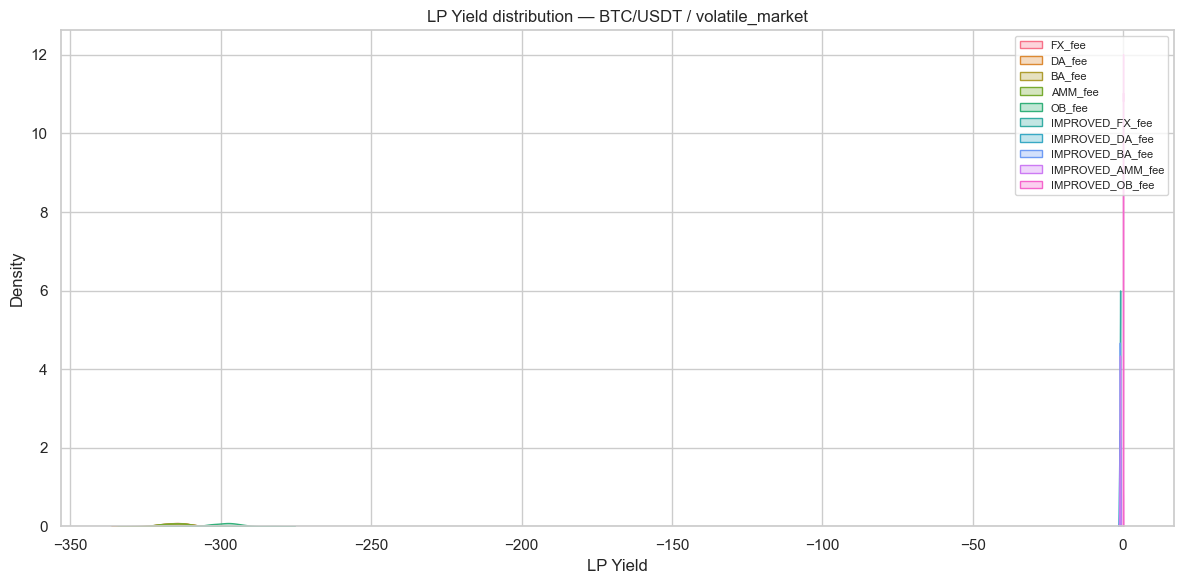

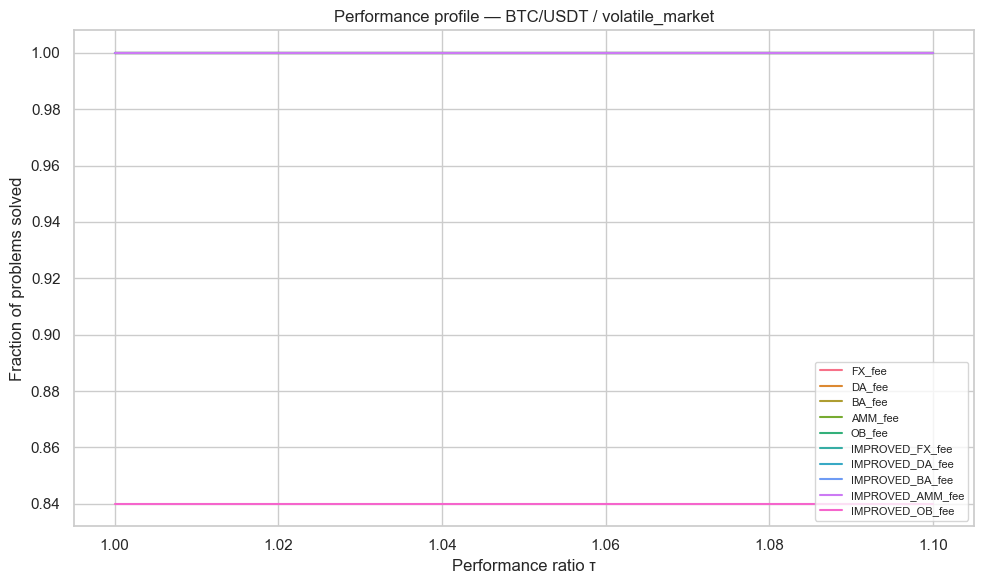

In [31]:
show_stats_for_pair_alias("BTC/USDT", "volatile_market")
plot_yield_stats("BTC/USDT", "volatile_market")
plot_performance_profile("BTC/USDT", "volatile_market")

##### bull_market


=== BTC/USDT / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,4748751.66 ± 5059446.66,5623.54 ± 218.34,100.93 ± 1.19,-7712.62 ± 4961.10,721.46 ± 24.55,-72.63 ± 26.77,-3345855.85 ± 3553624.90,-71.19 ± 1.30,6325574.53 ± 28691886.00
BA_fee,4771884.49 ± 5086350.72,5628.72 ± 217.87,101.13 ± 1.20,-7891.05 ± 5339.46,720.32 ± 24.16,-73.45 ± 26.28,-3393380.98 ± 3597939.98,-71.93 ± 1.23,6341413.27 ± 28700211.53
DA_fee,4774894.24 ± 5089615.05,5624.85 ± 217.54,101.21 ± 1.20,-7904.03 ± 5255.19,720.79 ± 24.47,-73.91 ± 26.72,-3403009.39 ± 3616205.43,-72.14 ± 1.19,6362692.86 ± 28765095.54
FX_fee,4779825.96 ± 5093430.34,5629.99 ± 217.79,101.22 ± 1.20,-7876.10 ± 5301.10,720.80 ± 24.31,-73.52 ± 26.54,-3410460.50 ± 3611639.91,-72.28 ± 1.16,6356487.75 ± 28732236.54
IMPROVED_AMM_fee,4173598.51 ± 4441420.48,5740.85 ± 199.23,117.71 ± 1.78,-7932.57 ± 5268.29,720.53 ± 23.57,-72.89 ± 25.87,-172475.52 ± 189549.47,-4.88 ± 0.33,5771373.41 ± 28182266.42
IMPROVED_BA_fee,4250030.52 ± 4511918.84,5800.27 ± 193.16,118.83 ± 1.72,-7828.67 ± 4757.81,720.69 ± 23.81,-73.19 ± 26.95,-266770.69 ± 271678.57,-7.56 ± 0.26,5851433.32 ± 28251735.98
IMPROVED_DA_fee,4271419.03 ± 4516226.62,5797.67 ± 192.85,119.53 ± 1.74,-8012.35 ± 5408.77,719.89 ± 23.95,-73.63 ± 26.43,-295350.94 ± 290955.40,-8.44 ± 0.84,5881773.74 ± 28271784.70
IMPROVED_FX_fee,4244979.74 ± 4504987.78,5803.30 ± 191.20,118.50 ± 1.75,-7861.82 ± 5172.41,720.22 ± 23.87,-73.24 ± 26.90,-261518.05 ± 268952.75,-7.38 ± 0.22,5847373.57 ± 28247565.78
IMPROVED_OB_fee,4041745.04 ± 4294385.30,5387.89 ± 182.68,118.29 ± 1.82,-7652.80 ± 3934.14,720.58 ± 24.44,-73.41 ± 28.62,23493.28 ± 34597.24,0.58 ± 0.17,5650766.83 ± 28080370.77


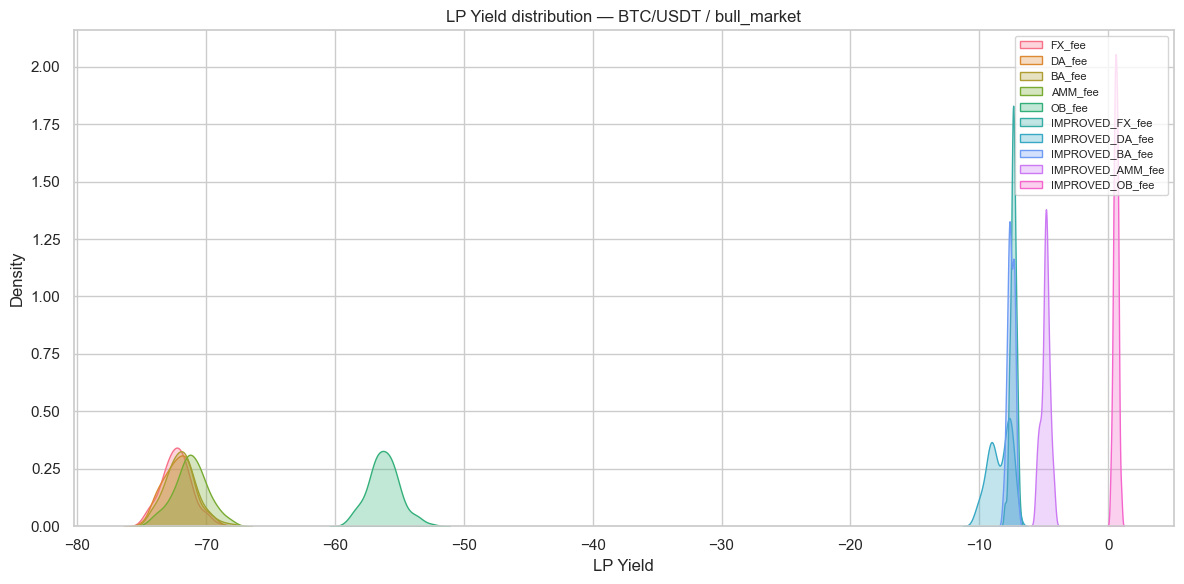

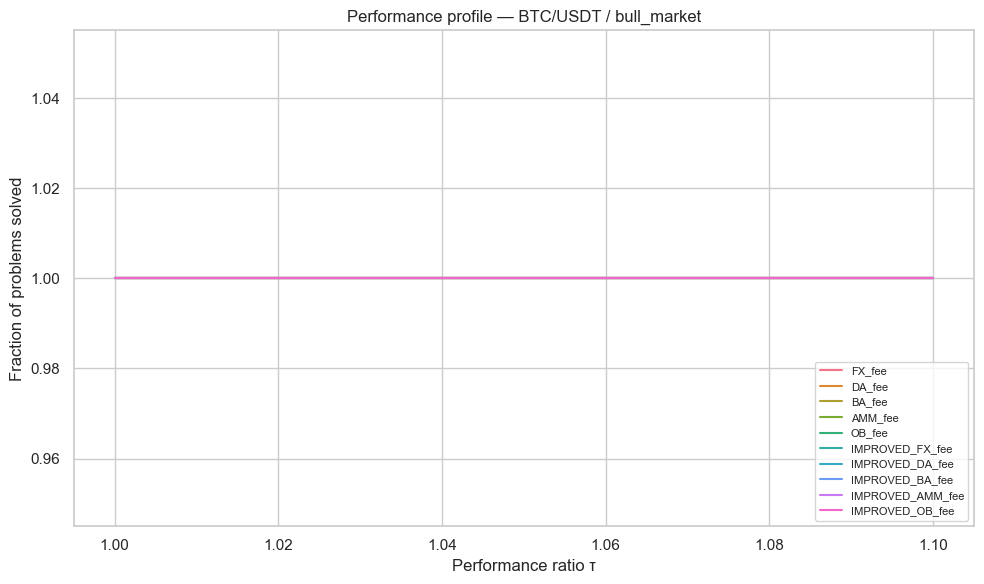

In [32]:
show_stats_for_pair_alias("BTC/USDT", "bull_market")
plot_yield_stats("BTC/USDT", "bull_market")
plot_performance_profile("BTC/USDT", "bull_market")

##### calm_market


=== BTC/USDT / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,1235339.40 ± 1108510.52,4597.64 ± 264.43,55.03 ± 0.74,-7913.01 ± 3642.25,721.05 ± 24.70,-69.39 ± 20.42,-540434.03 ± 474748.53,-24.31 ± 1.15,1663845.75 ± 8350063.16
BA_fee,1266863.44 ± 1143515.94,4622.11 ± 260.64,55.60 ± 0.71,-7990.17 ± 4003.51,721.15 ± 23.60,-69.71 ± 20.85,-599736.26 ± 528303.20,-26.50 ± 0.96,1690004.33 ± 8365728.12
DA_fee,1271415.17 ± 1147766.26,4622.30 ± 260.26,55.72 ± 0.72,-7958.66 ± 4044.63,721.08 ± 23.27,-69.45 ± 20.68,-609765.25 ± 539484.47,-26.89 ± 1.03,1701224.20 ± 8403379.68
FX_fee,1273233.79 ± 1149459.67,4629.10 ± 259.58,55.71 ± 0.72,-7944.63 ± 4087.40,721.10 ± 23.21,-69.28 ± 20.65,-614107.71 ± 543976.42,-27.02 ± 0.83,1698970.53 ± 8382271.38
IMPROVED_AMM_fee,1190331.98 ± 1066144.61,4689.28 ± 249.39,60.30 ± 0.89,-8083.78 ± 4634.51,721.32 ± 24.08,-69.68 ± 20.84,-64945.13 ± 54179.11,-3.48 ± 0.62,1626737.83 ± 8322237.63
IMPROVED_BA_fee,1271822.97 ± 1143478.21,4772.64 ± 246.23,62.80 ± 0.95,-7870.25 ± 3928.47,721.51 ± 24.04,-68.62 ± 20.86,-167128.74 ± 138458.49,-8.43 ± 0.50,1700791.68 ± 8385956.44
IMPROVED_DA_fee,1284081.08 ± 1155061.00,4776.74 ± 245.73,63.24 ± 1.02,-7991.05 ± 4191.83,721.51 ± 23.90,-69.34 ± 20.63,-185465.22 ± 159490.88,-9.25 ± 0.64,1718299.66 ± 8417777.52
IMPROVED_FX_fee,1276915.84 ± 1149502.47,4781.18 ± 247.18,62.83 ± 0.97,-7888.48 ± 3978.28,721.91 ± 24.73,-68.63 ± 20.69,-174909.08 ± 147872.82,-8.75 ± 0.33,1707129.18 ± 8393625.31
IMPROVED_OB_fee,1108231.58 ± 998163.02,4169.24 ± 224.48,61.76 ± 0.98,-8019.07 ± 3840.82,721.87 ± 23.48,-69.95 ± 21.38,85360.53 ± 81475.94,4.54 ± 0.40,1544381.08 ± 8253928.16


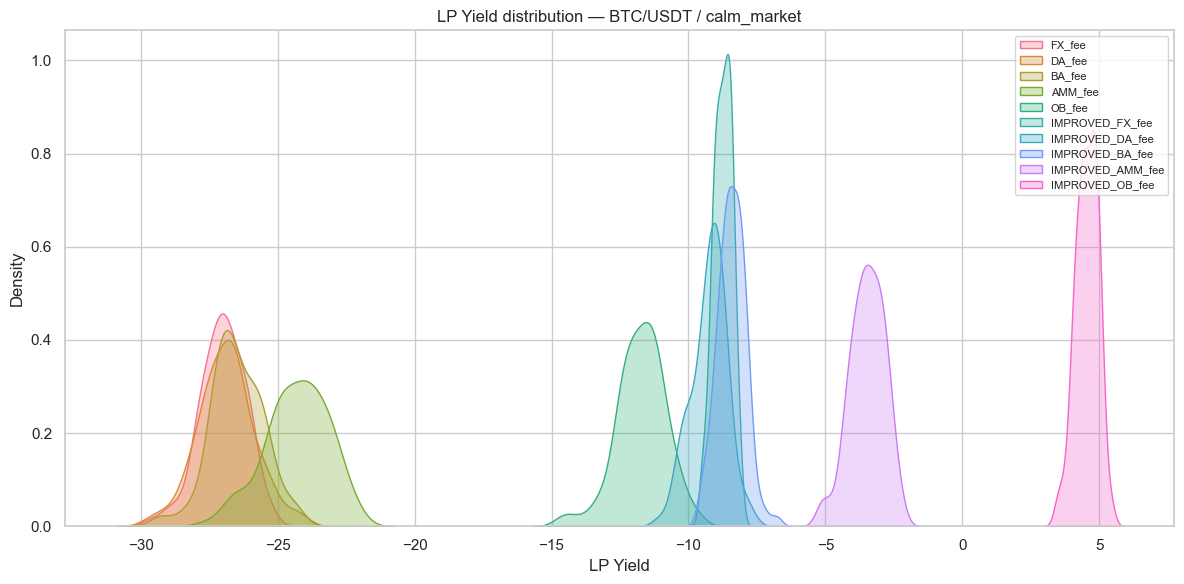

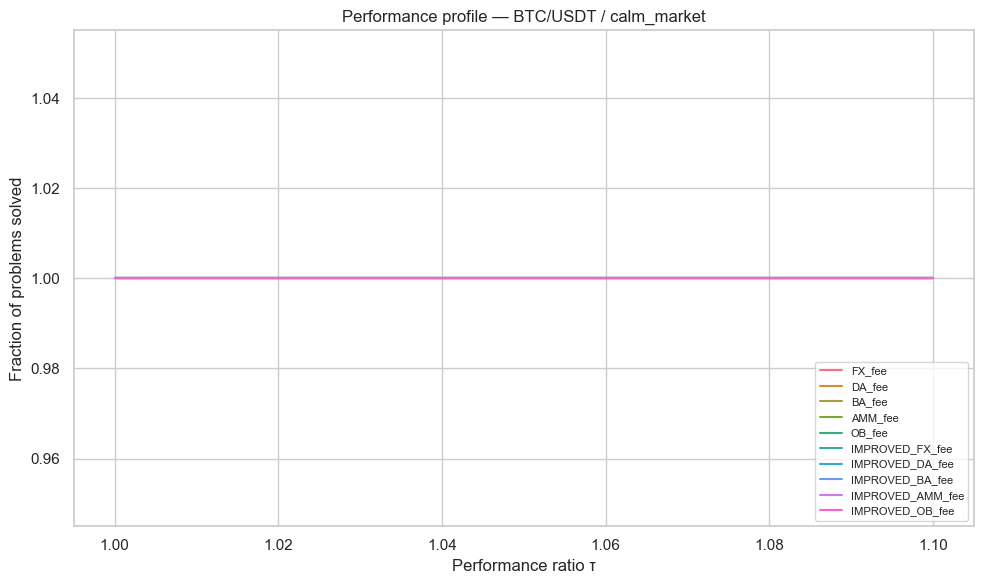

In [33]:
show_stats_for_pair_alias("BTC/USDT", "calm_market")
plot_yield_stats("BTC/USDT", "calm_market")
plot_performance_profile("BTC/USDT", "calm_market")

##### bear_market


=== BTC/USDT / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,2229263.62 ± 2074686.07,5104.82 ± 240.19,71.83 ± 0.87,-7906.29 ± 4252.66,720.88 ± 24.43,-70.94 ± 22.17,-1287382.67 ± 1188636.98,-41.62 ± 1.16,3133786.84 ± 15059002.77
BA_fee,2257642.66 ± 2101832.91,5118.57 ± 235.28,72.20 ± 0.92,-7804.63 ± 3629.73,720.77 ± 24.53,-71.53 ± 23.13,-1343498.11 ± 1236650.62,-43.03 ± 1.00,3157756.55 ± 15084104.39
DA_fee,2261942.00 ± 2107034.39,5114.37 ± 236.62,72.30 ± 0.92,-7846.91 ± 3861.07,720.68 ± 24.49,-71.56 ± 22.91,-1355421.27 ± 1254676.78,-43.37 ± 0.94,3175043.40 ± 15124301.75
FX_fee,2264728.90 ± 2108394.13,5121.27 ± 236.59,72.30 ± 0.92,-7788.96 ± 3802.31,720.86 ± 24.62,-71.23 ± 23.20,-1358657.51 ± 1248768.06,-43.47 ± 0.91,3168202.52 ± 15098661.72
IMPROVED_AMM_fee,2075320.34 ± 1926288.60,5216.51 ± 227.23,81.79 ± 1.33,-7883.01 ± 3909.17,720.88 ± 24.89,-70.89 ± 21.84,-121019.97 ± 112043.70,-4.86 ± 0.49,2990394.58 ± 14930201.00
IMPROVED_BA_fee,2168866.55 ± 2005096.57,5294.59 ± 213.79,83.99 ± 1.35,-7772.68 ± 3970.91,721.24 ± 24.28,-70.98 ± 23.78,-234198.82 ± 203608.38,-9.19 ± 0.33,3077211.98 ± 15001620.74
IMPROVED_DA_fee,2186864.55 ± 2015296.90,5293.30 ± 216.47,84.68 ± 1.30,-7830.36 ± 3820.14,722.07 ± 23.18,-71.08 ± 23.00,-260980.10 ± 227418.55,-10.26 ± 0.86,3104436.14 ± 15028947.13
IMPROVED_FX_fee,2170407.51 ± 2007861.84,5299.62 ± 215.51,83.87 ± 1.33,-7877.55 ± 3850.91,722.26 ± 23.19,-71.67 ± 23.46,-237090.71 ± 210070.05,-9.26 ± 0.25,3081052.63 ± 15007408.58
IMPROVED_OB_fee,1966662.52 ± 1822297.00,4764.15 ± 200.91,82.74 ± 1.36,-7872.17 ± 4217.66,721.30 ± 23.99,-70.92 ± 23.89,53018.24 ± 56179.62,2.09 ± 0.26,2889969.79 ± 14853973.06


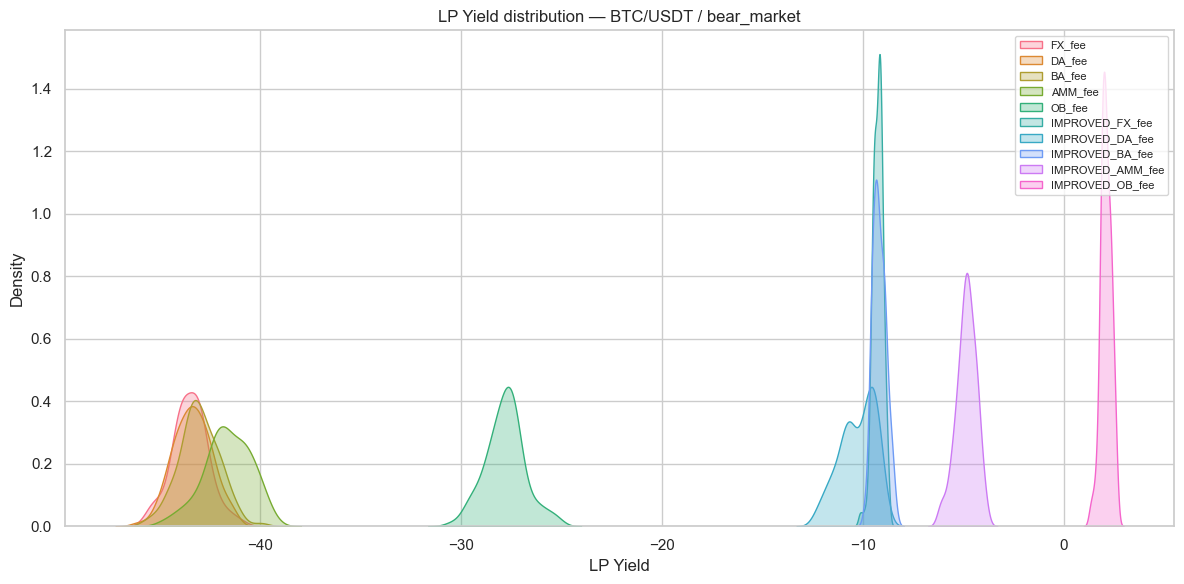

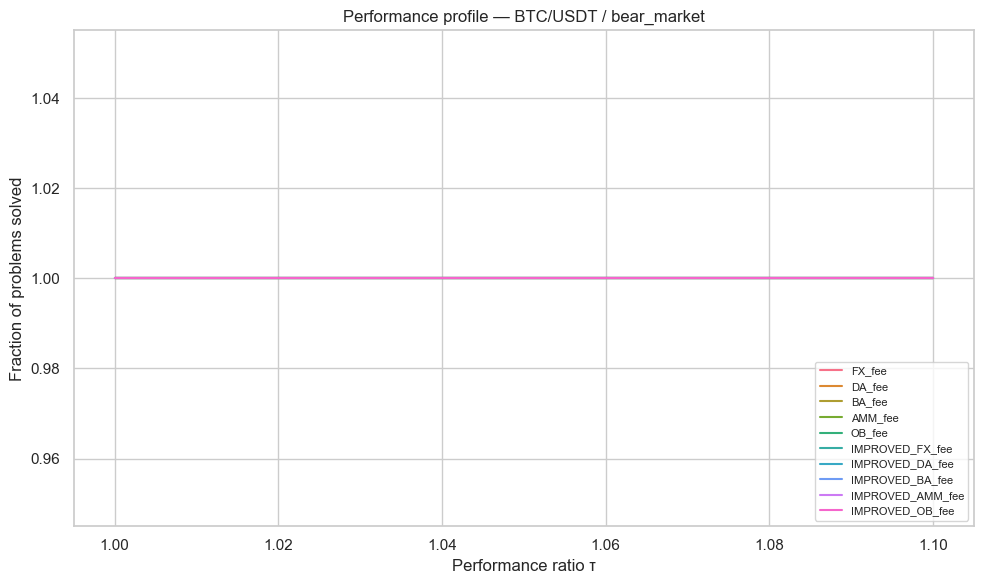

In [34]:
show_stats_for_pair_alias("BTC/USDT", "bear_market")
plot_yield_stats("BTC/USDT", "bear_market")
plot_performance_profile("BTC/USDT", "bear_market")

### Non-stable / Non-stable

#### ETH/BTC

##### volatile_market


=== ETH/BTC / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,36351875.83 ± 52051863.57,6136.67 ± 741.61,343.02 ± 5.13,-5341.43 ± 3946.00,715.04 ± 24.56,-134.84 ± 114.56,-33354791.20 ± 47759509.61,-314.76 ± 5.28,10346611.57 ± 9072955.69
BA_fee,36380425.74 ± 52174265.34,6136.21 ± 737.77,343.01 ± 5.05,-5467.90 ± 4235.05,715.62 ± 24.21,-135.92 ± 116.22,-33391371.49 ± 47875095.34,-314.71 ± 5.14,10367175.53 ± 9071091.30
DA_fee,36400234.00 ± 52247606.65,6133.55 ± 740.36,343.02 ± 5.05,-5465.85 ± 4198.78,715.40 ± 24.18,-135.88 ± 116.25,-33395761.67 ± 47915709.98,-314.88 ± 5.07,10379518.88 ± 9066872.01
FX_fee,36382643.49 ± 52167994.36,6135.45 ± 739.43,343.04 ± 5.05,-5467.92 ± 4210.13,715.62 ± 24.11,-136.05 ± 116.22,-33397842.35 ± 47879897.82,-314.92 ± 5.07,10388793.89 ± 9081601.39
IMPROVED_AMM_fee,34951490.58 ± 56822782.13,6323.30 ± 691.12,399.23 ± 7.47,-5464.56 ± 8279.04,713.80 ± 25.86,-118.45 ± 113.45,-91977.91 ± 151688.58,-1.04 ± 0.09,5283568.17 ± 18657567.39
IMPROVED_BA_fee,34946925.26 ± 56777597.76,6334.93 ± 691.14,398.95 ± 7.48,-5405.61 ± 7502.29,712.72 ± 24.95,-117.01 ± 114.77,-91732.74 ± 140505.36,-1.07 ± 0.08,5284493.85 ± 18653446.36
IMPROVED_DA_fee,34952019.94 ± 56794518.57,6334.57 ± 689.90,399.07 ± 7.54,-6522.61 ± 8660.63,713.08 ± 24.99,-122.65 ± 114.47,-99927.28 ± 161531.36,-1.16 ± 0.14,5286645.74 ± 18650652.45
IMPROVED_FX_fee,34946880.13 ± 56778947.99,6335.35 ± 691.66,398.81 ± 7.51,-5339.41 ± 7400.65,713.30 ± 25.14,-120.15 ± 115.65,-87910.14 ± 139013.56,-1.01 ± 0.06,5282310.44 ± 18658272.26
IMPROVED_OB_fee,34933782.22 ± 56807083.07,6218.63 ± 669.31,400.11 ± 7.54,-5394.12 ± 6514.70,714.18 ± 24.73,-120.66 ± 116.69,53.58 ± 3462.80,-0.02 ± 0.03,5244784.97 ± 18780368.17


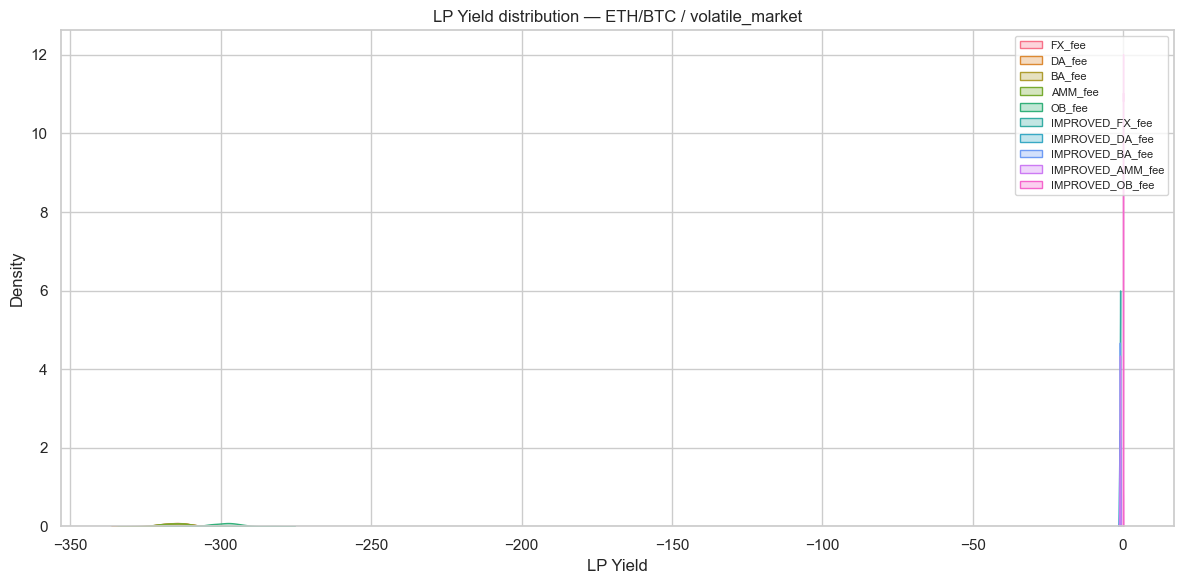

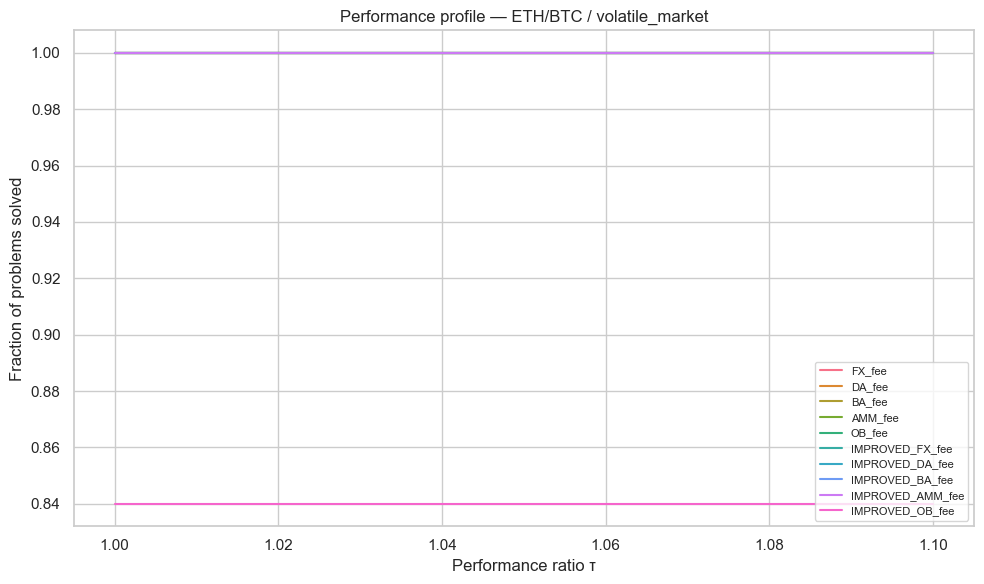

In [35]:
show_stats_for_pair_alias("ETH/BTC", "volatile_market")
plot_yield_stats("ETH/BTC", "volatile_market")
plot_performance_profile("ETH/BTC", "volatile_market")

##### bull_market


=== ETH/BTC / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,4748751.66 ± 5059446.66,5623.54 ± 218.34,100.93 ± 1.19,-7712.62 ± 4961.10,721.46 ± 24.55,-72.63 ± 26.77,-3345855.85 ± 3553624.90,-71.19 ± 1.30,6325574.53 ± 28691886.00
BA_fee,4771884.49 ± 5086350.72,5628.72 ± 217.87,101.13 ± 1.20,-7891.05 ± 5339.46,720.32 ± 24.16,-73.45 ± 26.28,-3393380.98 ± 3597939.98,-71.93 ± 1.23,6341413.27 ± 28700211.53
DA_fee,4774894.24 ± 5089615.05,5624.85 ± 217.54,101.21 ± 1.20,-7904.03 ± 5255.19,720.79 ± 24.47,-73.91 ± 26.72,-3403009.39 ± 3616205.43,-72.14 ± 1.19,6362692.86 ± 28765095.54
FX_fee,4779825.96 ± 5093430.34,5629.99 ± 217.79,101.22 ± 1.20,-7876.10 ± 5301.10,720.80 ± 24.31,-73.52 ± 26.54,-3410460.50 ± 3611639.91,-72.28 ± 1.16,6356487.75 ± 28732236.54
IMPROVED_AMM_fee,4173598.51 ± 4441420.48,5740.85 ± 199.23,117.71 ± 1.78,-7932.57 ± 5268.29,720.53 ± 23.57,-72.89 ± 25.87,-172475.52 ± 189549.47,-4.88 ± 0.33,5771373.41 ± 28182266.42
IMPROVED_BA_fee,4250030.52 ± 4511918.84,5800.27 ± 193.16,118.83 ± 1.72,-7828.67 ± 4757.81,720.69 ± 23.81,-73.19 ± 26.95,-266770.69 ± 271678.57,-7.56 ± 0.26,5851433.32 ± 28251735.98
IMPROVED_DA_fee,4271419.03 ± 4516226.62,5797.67 ± 192.85,119.53 ± 1.74,-8012.35 ± 5408.77,719.89 ± 23.95,-73.63 ± 26.43,-295350.94 ± 290955.40,-8.44 ± 0.84,5881773.74 ± 28271784.70
IMPROVED_FX_fee,4244979.74 ± 4504987.78,5803.30 ± 191.20,118.50 ± 1.75,-7861.82 ± 5172.41,720.22 ± 23.87,-73.24 ± 26.90,-261518.05 ± 268952.75,-7.38 ± 0.22,5847373.57 ± 28247565.78
IMPROVED_OB_fee,4041745.04 ± 4294385.30,5387.89 ± 182.68,118.29 ± 1.82,-7652.80 ± 3934.14,720.58 ± 24.44,-73.41 ± 28.62,23493.28 ± 34597.24,0.58 ± 0.17,5650766.83 ± 28080370.77


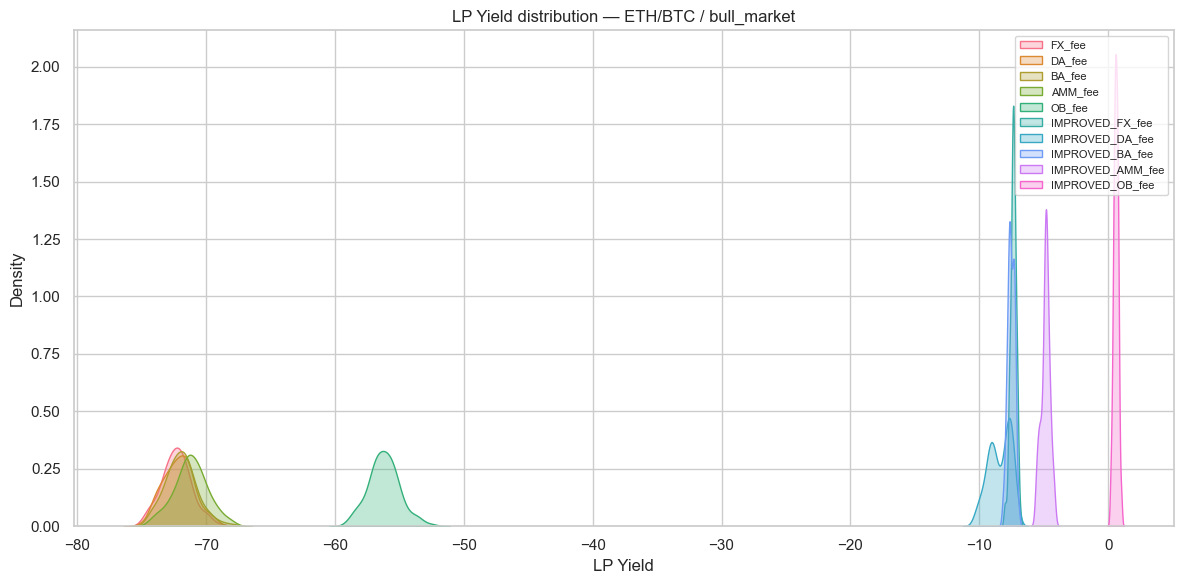

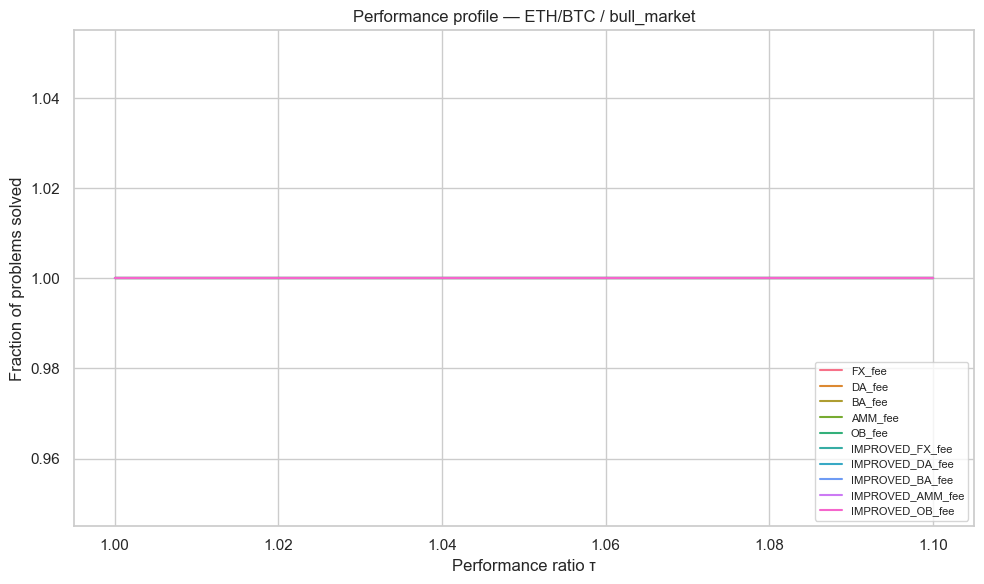

In [36]:
show_stats_for_pair_alias("ETH/BTC", "bull_market")
plot_yield_stats("ETH/BTC", "bull_market")
plot_performance_profile("ETH/BTC", "bull_market")

##### calm_market


=== ETH/BTC / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,1235339.40 ± 1108510.52,4597.64 ± 264.43,55.03 ± 0.74,-7913.01 ± 3642.25,721.05 ± 24.70,-69.39 ± 20.42,-540434.03 ± 474748.53,-24.31 ± 1.15,1663845.75 ± 8350063.16
BA_fee,1266863.44 ± 1143515.94,4622.11 ± 260.64,55.60 ± 0.71,-7990.17 ± 4003.51,721.15 ± 23.60,-69.71 ± 20.85,-599736.26 ± 528303.20,-26.50 ± 0.96,1690004.33 ± 8365728.12
DA_fee,1271415.17 ± 1147766.26,4622.30 ± 260.26,55.72 ± 0.72,-7958.66 ± 4044.63,721.08 ± 23.27,-69.45 ± 20.68,-609765.25 ± 539484.47,-26.89 ± 1.03,1701224.20 ± 8403379.68
FX_fee,1273233.79 ± 1149459.67,4629.10 ± 259.58,55.71 ± 0.72,-7944.63 ± 4087.40,721.10 ± 23.21,-69.28 ± 20.65,-614107.71 ± 543976.42,-27.02 ± 0.83,1698970.53 ± 8382271.38
IMPROVED_AMM_fee,1190331.98 ± 1066144.61,4689.28 ± 249.39,60.30 ± 0.89,-8083.78 ± 4634.51,721.32 ± 24.08,-69.68 ± 20.84,-64945.13 ± 54179.11,-3.48 ± 0.62,1626737.83 ± 8322237.63
IMPROVED_BA_fee,1271822.97 ± 1143478.21,4772.64 ± 246.23,62.80 ± 0.95,-7870.25 ± 3928.47,721.51 ± 24.04,-68.62 ± 20.86,-167128.74 ± 138458.49,-8.43 ± 0.50,1700791.68 ± 8385956.44
IMPROVED_DA_fee,1284081.08 ± 1155061.00,4776.74 ± 245.73,63.24 ± 1.02,-7991.05 ± 4191.83,721.51 ± 23.90,-69.34 ± 20.63,-185465.22 ± 159490.88,-9.25 ± 0.64,1718299.66 ± 8417777.52
IMPROVED_FX_fee,1276915.84 ± 1149502.47,4781.18 ± 247.18,62.83 ± 0.97,-7888.48 ± 3978.28,721.91 ± 24.73,-68.63 ± 20.69,-174909.08 ± 147872.82,-8.75 ± 0.33,1707129.18 ± 8393625.31
IMPROVED_OB_fee,1108231.58 ± 998163.02,4169.24 ± 224.48,61.76 ± 0.98,-8019.07 ± 3840.82,721.87 ± 23.48,-69.95 ± 21.38,85360.53 ± 81475.94,4.54 ± 0.40,1544381.08 ± 8253928.16


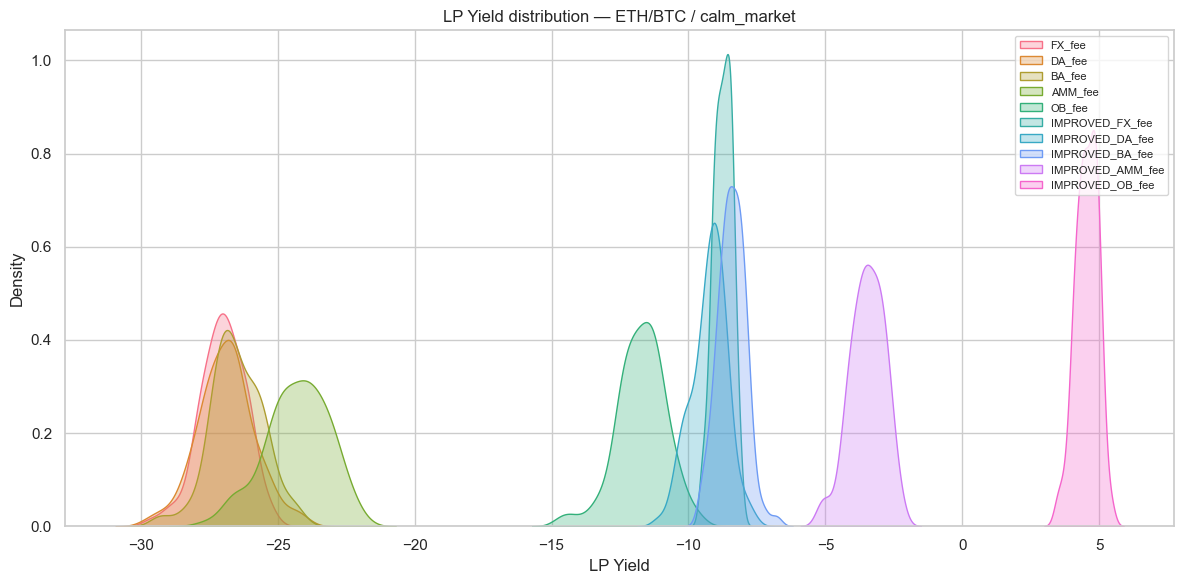

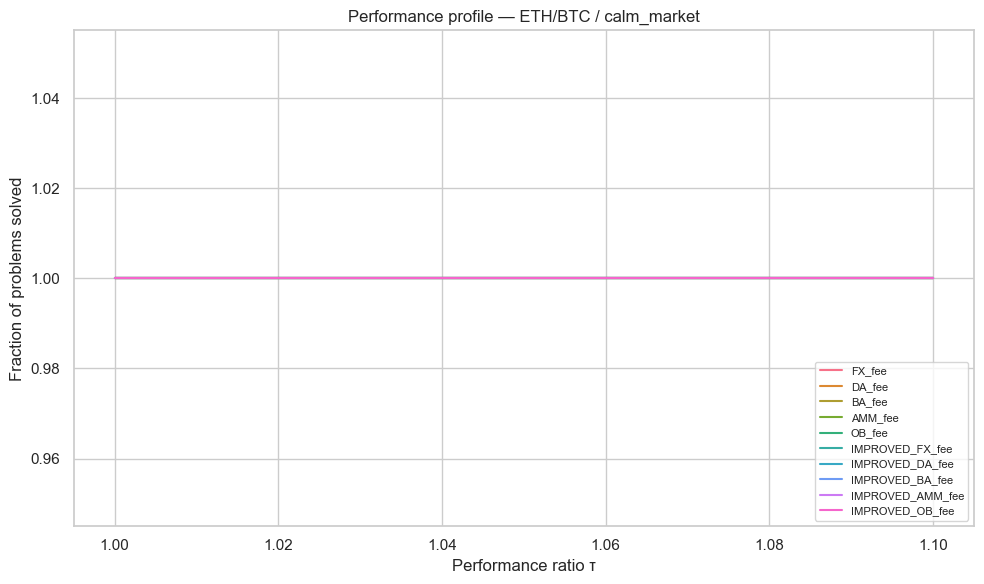

In [37]:
show_stats_for_pair_alias("ETH/BTC", "calm_market")
plot_yield_stats("ETH/BTC", "calm_market")
plot_performance_profile("ETH/BTC", "calm_market")

##### bear_market


=== ETH/BTC / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,2229263.62 ± 2074686.07,5104.82 ± 240.19,71.83 ± 0.87,-7906.29 ± 4252.66,720.88 ± 24.43,-70.94 ± 22.17,-1287382.67 ± 1188636.98,-41.62 ± 1.16,3133786.84 ± 15059002.77
BA_fee,2257642.66 ± 2101832.91,5118.57 ± 235.28,72.20 ± 0.92,-7804.63 ± 3629.73,720.77 ± 24.53,-71.53 ± 23.13,-1343498.11 ± 1236650.62,-43.03 ± 1.00,3157756.55 ± 15084104.39
DA_fee,2261942.00 ± 2107034.39,5114.37 ± 236.62,72.30 ± 0.92,-7846.91 ± 3861.07,720.68 ± 24.49,-71.56 ± 22.91,-1355421.27 ± 1254676.78,-43.37 ± 0.94,3175043.40 ± 15124301.75
FX_fee,2264728.90 ± 2108394.13,5121.27 ± 236.59,72.30 ± 0.92,-7788.96 ± 3802.31,720.86 ± 24.62,-71.23 ± 23.20,-1358657.51 ± 1248768.06,-43.47 ± 0.91,3168202.52 ± 15098661.72
IMPROVED_AMM_fee,2075320.34 ± 1926288.60,5216.51 ± 227.23,81.79 ± 1.33,-7883.01 ± 3909.17,720.88 ± 24.89,-70.89 ± 21.84,-121019.97 ± 112043.70,-4.86 ± 0.49,2990394.58 ± 14930201.00
IMPROVED_BA_fee,2168866.55 ± 2005096.57,5294.59 ± 213.79,83.99 ± 1.35,-7772.68 ± 3970.91,721.24 ± 24.28,-70.98 ± 23.78,-234198.82 ± 203608.38,-9.19 ± 0.33,3077211.98 ± 15001620.74
IMPROVED_DA_fee,2186864.55 ± 2015296.90,5293.30 ± 216.47,84.68 ± 1.30,-7830.36 ± 3820.14,722.07 ± 23.18,-71.08 ± 23.00,-260980.10 ± 227418.55,-10.26 ± 0.86,3104436.14 ± 15028947.13
IMPROVED_FX_fee,2170407.51 ± 2007861.84,5299.62 ± 215.51,83.87 ± 1.33,-7877.55 ± 3850.91,722.26 ± 23.19,-71.67 ± 23.46,-237090.71 ± 210070.05,-9.26 ± 0.25,3081052.63 ± 15007408.58
IMPROVED_OB_fee,1966662.52 ± 1822297.00,4764.15 ± 200.91,82.74 ± 1.36,-7872.17 ± 4217.66,721.30 ± 23.99,-70.92 ± 23.89,53018.24 ± 56179.62,2.09 ± 0.26,2889969.79 ± 14853973.06


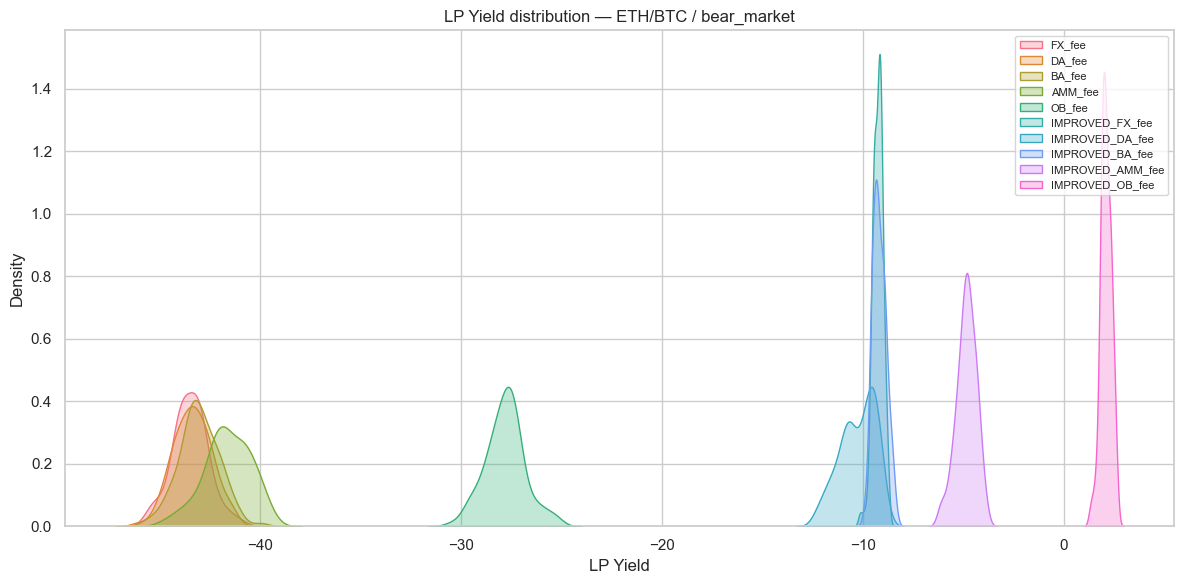

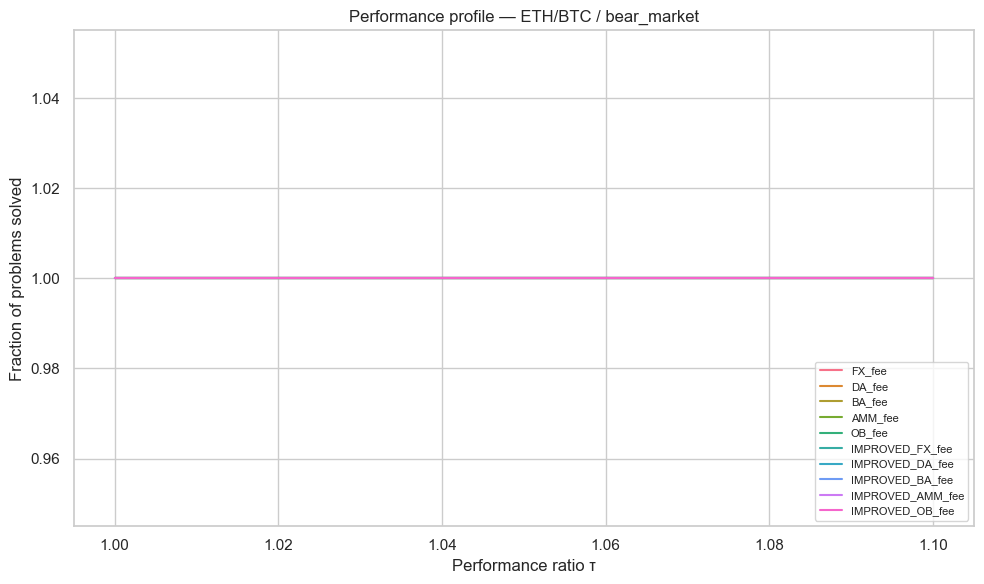

In [38]:
show_stats_for_pair_alias("ETH/BTC", "bear_market")
plot_yield_stats("ETH/BTC", "bear_market")
plot_performance_profile("ETH/BTC", "bear_market")

#### BNB/ETH

##### volatile_market


=== BNB/ETH / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,36351875.83 ± 52051863.57,6136.67 ± 741.61,343.02 ± 5.13,-5341.43 ± 3946.00,715.04 ± 24.56,-134.84 ± 114.56,-33354791.20 ± 47759509.61,-314.76 ± 5.28,10346611.57 ± 9072955.69
BA_fee,36380425.74 ± 52174265.34,6136.21 ± 737.77,343.01 ± 5.05,-5467.90 ± 4235.05,715.62 ± 24.21,-135.92 ± 116.22,-33391371.49 ± 47875095.34,-314.71 ± 5.14,10367175.53 ± 9071091.30
DA_fee,36400234.00 ± 52247606.65,6133.55 ± 740.36,343.02 ± 5.05,-5465.85 ± 4198.78,715.40 ± 24.18,-135.88 ± 116.25,-33395761.67 ± 47915709.98,-314.88 ± 5.07,10379518.88 ± 9066872.01
FX_fee,36382643.49 ± 52167994.36,6135.45 ± 739.43,343.04 ± 5.05,-5467.92 ± 4210.13,715.62 ± 24.11,-136.05 ± 116.22,-33397842.35 ± 47879897.82,-314.92 ± 5.07,10388793.89 ± 9081601.39
IMPROVED_AMM_fee,34951490.58 ± 56822782.13,6323.30 ± 691.12,399.23 ± 7.47,-5464.56 ± 8279.04,713.80 ± 25.86,-118.45 ± 113.45,-91977.91 ± 151688.58,-1.04 ± 0.09,5283568.17 ± 18657567.39
IMPROVED_BA_fee,34946925.26 ± 56777597.76,6334.93 ± 691.14,398.95 ± 7.48,-5405.61 ± 7502.29,712.72 ± 24.95,-117.01 ± 114.77,-91732.74 ± 140505.36,-1.07 ± 0.08,5284493.85 ± 18653446.36
IMPROVED_DA_fee,34952019.94 ± 56794518.57,6334.57 ± 689.90,399.07 ± 7.54,-6522.61 ± 8660.63,713.08 ± 24.99,-122.65 ± 114.47,-99927.28 ± 161531.36,-1.16 ± 0.14,5286645.74 ± 18650652.45
IMPROVED_FX_fee,34946880.13 ± 56778947.99,6335.35 ± 691.66,398.81 ± 7.51,-5339.41 ± 7400.65,713.30 ± 25.14,-120.15 ± 115.65,-87910.14 ± 139013.56,-1.01 ± 0.06,5282310.44 ± 18658272.26
IMPROVED_OB_fee,34933782.22 ± 56807083.07,6218.63 ± 669.31,400.11 ± 7.54,-5394.12 ± 6514.70,714.18 ± 24.73,-120.66 ± 116.69,53.58 ± 3462.80,-0.02 ± 0.03,5244784.97 ± 18780368.17


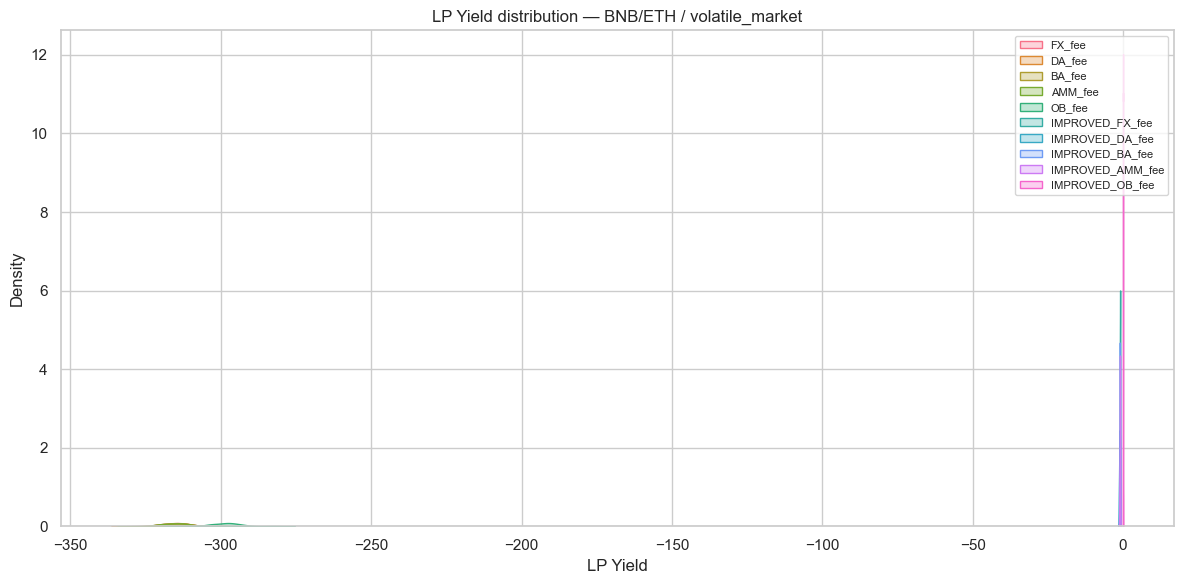

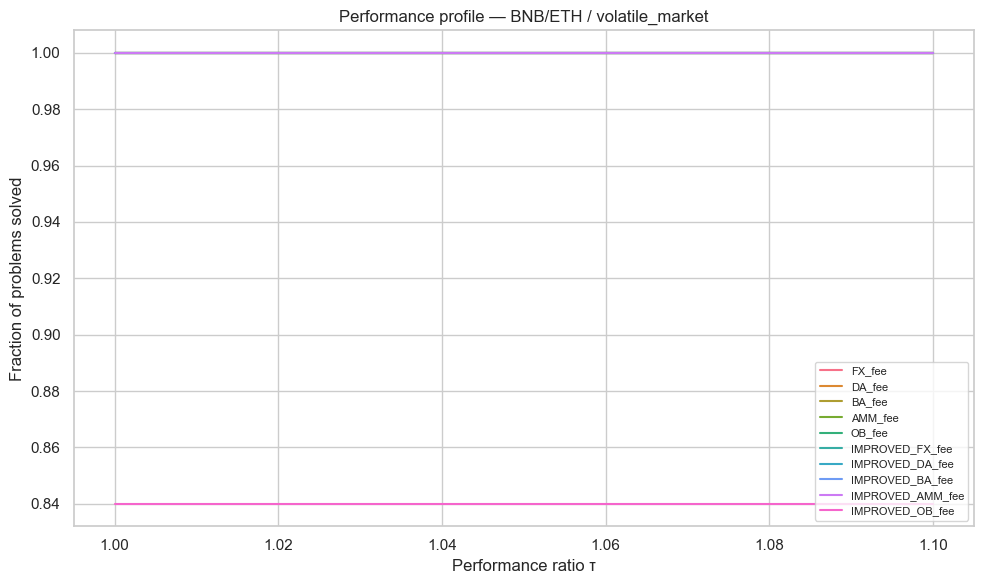

In [39]:
show_stats_for_pair_alias("BNB/ETH", "volatile_market")
plot_yield_stats("BNB/ETH", "volatile_market")
plot_performance_profile("BNB/ETH", "volatile_market")

##### bull_market


=== BNB/ETH / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,4748751.66 ± 5059446.66,5623.54 ± 218.34,100.93 ± 1.19,-7712.62 ± 4961.10,721.46 ± 24.55,-72.63 ± 26.77,-3345855.85 ± 3553624.90,-71.19 ± 1.30,6325574.53 ± 28691886.00
BA_fee,4771884.49 ± 5086350.72,5628.72 ± 217.87,101.13 ± 1.20,-7891.05 ± 5339.46,720.32 ± 24.16,-73.45 ± 26.28,-3393380.98 ± 3597939.98,-71.93 ± 1.23,6341413.27 ± 28700211.53
DA_fee,4774894.24 ± 5089615.05,5624.85 ± 217.54,101.21 ± 1.20,-7904.03 ± 5255.19,720.79 ± 24.47,-73.91 ± 26.72,-3403009.39 ± 3616205.43,-72.14 ± 1.19,6362692.86 ± 28765095.54
FX_fee,4779825.96 ± 5093430.34,5629.99 ± 217.79,101.22 ± 1.20,-7876.10 ± 5301.10,720.80 ± 24.31,-73.52 ± 26.54,-3410460.50 ± 3611639.91,-72.28 ± 1.16,6356487.75 ± 28732236.54
IMPROVED_AMM_fee,4173598.51 ± 4441420.48,5740.85 ± 199.23,117.71 ± 1.78,-7932.57 ± 5268.29,720.53 ± 23.57,-72.89 ± 25.87,-172475.52 ± 189549.47,-4.88 ± 0.33,5771373.41 ± 28182266.42
IMPROVED_BA_fee,4250030.52 ± 4511918.84,5800.27 ± 193.16,118.83 ± 1.72,-7828.67 ± 4757.81,720.69 ± 23.81,-73.19 ± 26.95,-266770.69 ± 271678.57,-7.56 ± 0.26,5851433.32 ± 28251735.98
IMPROVED_DA_fee,4271419.03 ± 4516226.62,5797.67 ± 192.85,119.53 ± 1.74,-8012.35 ± 5408.77,719.89 ± 23.95,-73.63 ± 26.43,-295350.94 ± 290955.40,-8.44 ± 0.84,5881773.74 ± 28271784.70
IMPROVED_FX_fee,4244979.74 ± 4504987.78,5803.30 ± 191.20,118.50 ± 1.75,-7861.82 ± 5172.41,720.22 ± 23.87,-73.24 ± 26.90,-261518.05 ± 268952.75,-7.38 ± 0.22,5847373.57 ± 28247565.78
IMPROVED_OB_fee,4041745.04 ± 4294385.30,5387.89 ± 182.68,118.29 ± 1.82,-7652.80 ± 3934.14,720.58 ± 24.44,-73.41 ± 28.62,23493.28 ± 34597.24,0.58 ± 0.17,5650766.83 ± 28080370.77


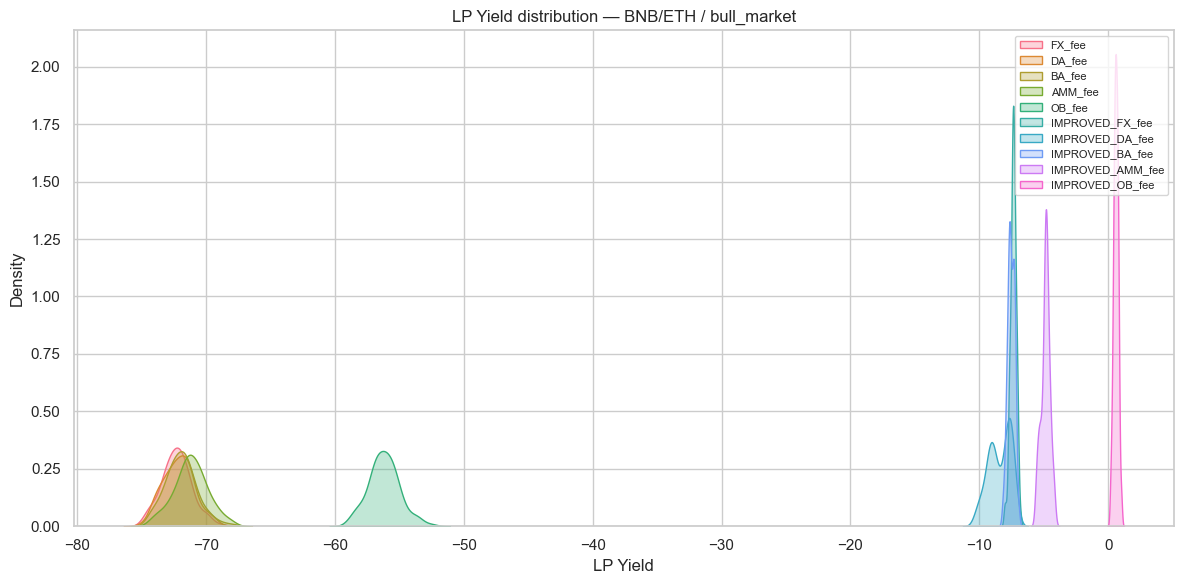

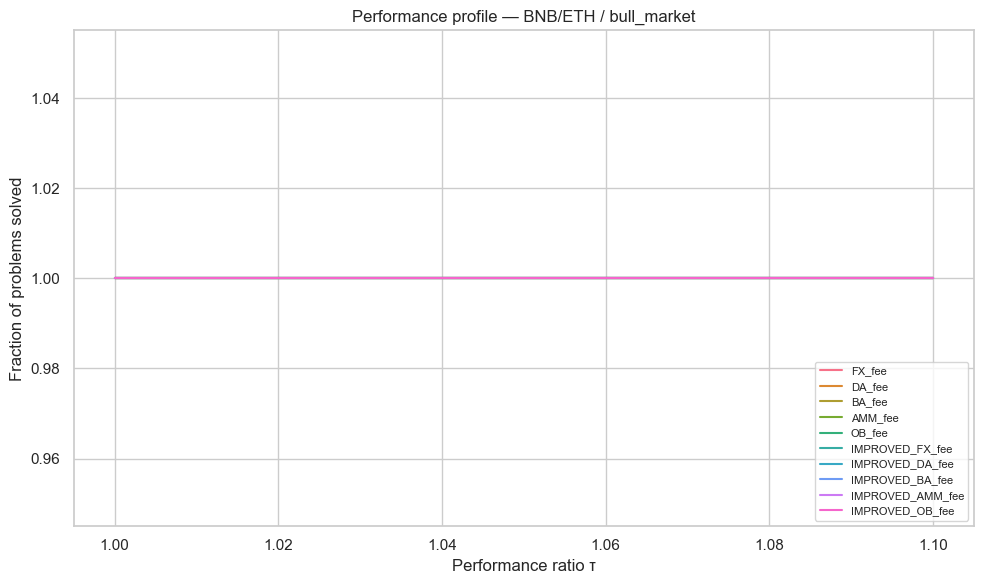

In [40]:
show_stats_for_pair_alias("BNB/ETH", "bull_market")
plot_yield_stats("BNB/ETH", "bull_market")
plot_performance_profile("BNB/ETH", "bull_market")

##### calm_market


=== BNB/ETH / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,1235339.40 ± 1108510.52,4597.64 ± 264.43,55.03 ± 0.74,-7913.01 ± 3642.25,721.05 ± 24.70,-69.39 ± 20.42,-540434.03 ± 474748.53,-24.31 ± 1.15,1663845.75 ± 8350063.16
BA_fee,1266863.44 ± 1143515.94,4622.11 ± 260.64,55.60 ± 0.71,-7990.17 ± 4003.51,721.15 ± 23.60,-69.71 ± 20.85,-599736.26 ± 528303.20,-26.50 ± 0.96,1690004.33 ± 8365728.12
DA_fee,1271415.17 ± 1147766.26,4622.30 ± 260.26,55.72 ± 0.72,-7958.66 ± 4044.63,721.08 ± 23.27,-69.45 ± 20.68,-609765.25 ± 539484.47,-26.89 ± 1.03,1701224.20 ± 8403379.68
FX_fee,1273233.79 ± 1149459.67,4629.10 ± 259.58,55.71 ± 0.72,-7944.63 ± 4087.40,721.10 ± 23.21,-69.28 ± 20.65,-614107.71 ± 543976.42,-27.02 ± 0.83,1698970.53 ± 8382271.38
IMPROVED_AMM_fee,1190331.98 ± 1066144.61,4689.28 ± 249.39,60.30 ± 0.89,-8083.78 ± 4634.51,721.32 ± 24.08,-69.68 ± 20.84,-64945.13 ± 54179.11,-3.48 ± 0.62,1626737.83 ± 8322237.63
IMPROVED_BA_fee,1271822.97 ± 1143478.21,4772.64 ± 246.23,62.80 ± 0.95,-7870.25 ± 3928.47,721.51 ± 24.04,-68.62 ± 20.86,-167128.74 ± 138458.49,-8.43 ± 0.50,1700791.68 ± 8385956.44
IMPROVED_DA_fee,1284081.08 ± 1155061.00,4776.74 ± 245.73,63.24 ± 1.02,-7991.05 ± 4191.83,721.51 ± 23.90,-69.34 ± 20.63,-185465.22 ± 159490.88,-9.25 ± 0.64,1718299.66 ± 8417777.52
IMPROVED_FX_fee,1276915.84 ± 1149502.47,4781.18 ± 247.18,62.83 ± 0.97,-7888.48 ± 3978.28,721.91 ± 24.73,-68.63 ± 20.69,-174909.08 ± 147872.82,-8.75 ± 0.33,1707129.18 ± 8393625.31
IMPROVED_OB_fee,1108231.58 ± 998163.02,4169.24 ± 224.48,61.76 ± 0.98,-8019.07 ± 3840.82,721.87 ± 23.48,-69.95 ± 21.38,85360.53 ± 81475.94,4.54 ± 0.40,1544381.08 ± 8253928.16


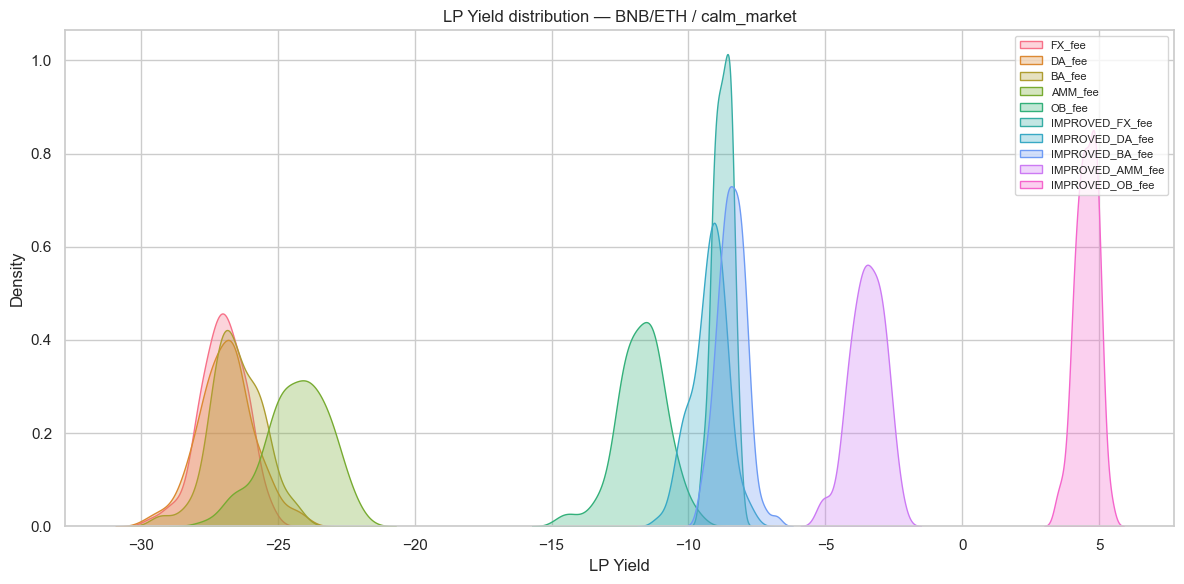

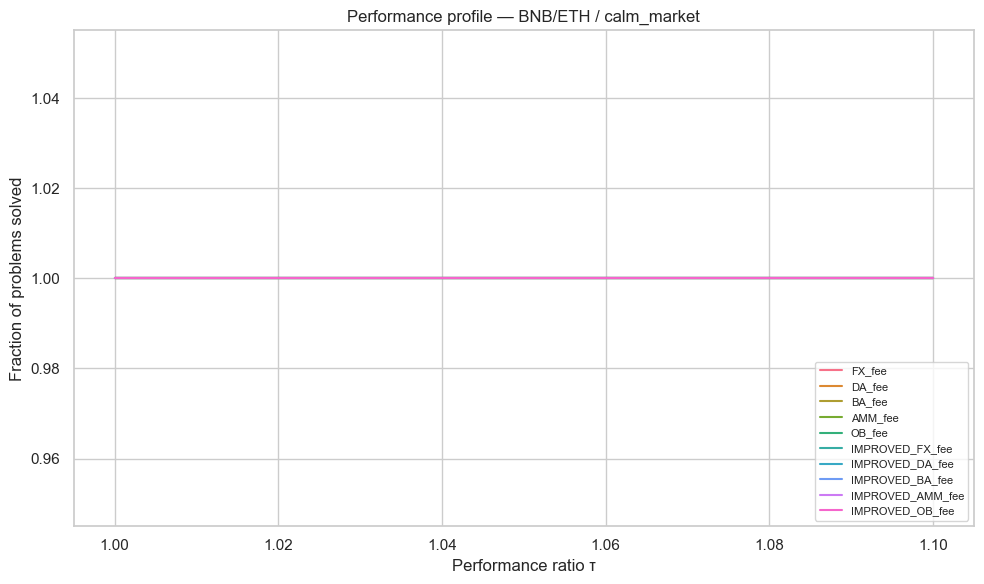

In [41]:
show_stats_for_pair_alias("BNB/ETH", "calm_market")
plot_yield_stats("BNB/ETH", "calm_market")
plot_performance_profile("BNB/ETH", "calm_market")

##### bear_market


=== BNB/ETH / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,2229263.62 ± 2074686.07,5104.82 ± 240.19,71.83 ± 0.87,-7906.29 ± 4252.66,720.88 ± 24.43,-70.94 ± 22.17,-1287382.67 ± 1188636.98,-41.62 ± 1.16,3133786.84 ± 15059002.77
BA_fee,2257642.66 ± 2101832.91,5118.57 ± 235.28,72.20 ± 0.92,-7804.63 ± 3629.73,720.77 ± 24.53,-71.53 ± 23.13,-1343498.11 ± 1236650.62,-43.03 ± 1.00,3157756.55 ± 15084104.39
DA_fee,2261942.00 ± 2107034.39,5114.37 ± 236.62,72.30 ± 0.92,-7846.91 ± 3861.07,720.68 ± 24.49,-71.56 ± 22.91,-1355421.27 ± 1254676.78,-43.37 ± 0.94,3175043.40 ± 15124301.75
FX_fee,2264728.90 ± 2108394.13,5121.27 ± 236.59,72.30 ± 0.92,-7788.96 ± 3802.31,720.86 ± 24.62,-71.23 ± 23.20,-1358657.51 ± 1248768.06,-43.47 ± 0.91,3168202.52 ± 15098661.72
IMPROVED_AMM_fee,2075320.34 ± 1926288.60,5216.51 ± 227.23,81.79 ± 1.33,-7883.01 ± 3909.17,720.88 ± 24.89,-70.89 ± 21.84,-121019.97 ± 112043.70,-4.86 ± 0.49,2990394.58 ± 14930201.00
IMPROVED_BA_fee,2168866.55 ± 2005096.57,5294.59 ± 213.79,83.99 ± 1.35,-7772.68 ± 3970.91,721.24 ± 24.28,-70.98 ± 23.78,-234198.82 ± 203608.38,-9.19 ± 0.33,3077211.98 ± 15001620.74
IMPROVED_DA_fee,2186864.55 ± 2015296.90,5293.30 ± 216.47,84.68 ± 1.30,-7830.36 ± 3820.14,722.07 ± 23.18,-71.08 ± 23.00,-260980.10 ± 227418.55,-10.26 ± 0.86,3104436.14 ± 15028947.13
IMPROVED_FX_fee,2170407.51 ± 2007861.84,5299.62 ± 215.51,83.87 ± 1.33,-7877.55 ± 3850.91,722.26 ± 23.19,-71.67 ± 23.46,-237090.71 ± 210070.05,-9.26 ± 0.25,3081052.63 ± 15007408.58
IMPROVED_OB_fee,1966662.52 ± 1822297.00,4764.15 ± 200.91,82.74 ± 1.36,-7872.17 ± 4217.66,721.30 ± 23.99,-70.92 ± 23.89,53018.24 ± 56179.62,2.09 ± 0.26,2889969.79 ± 14853973.06


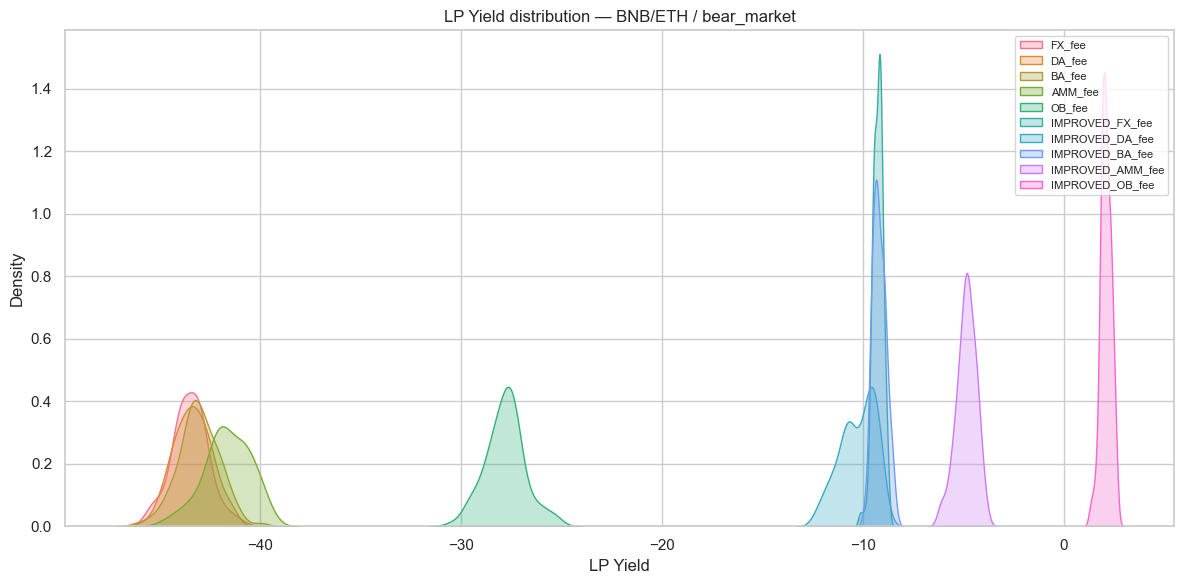

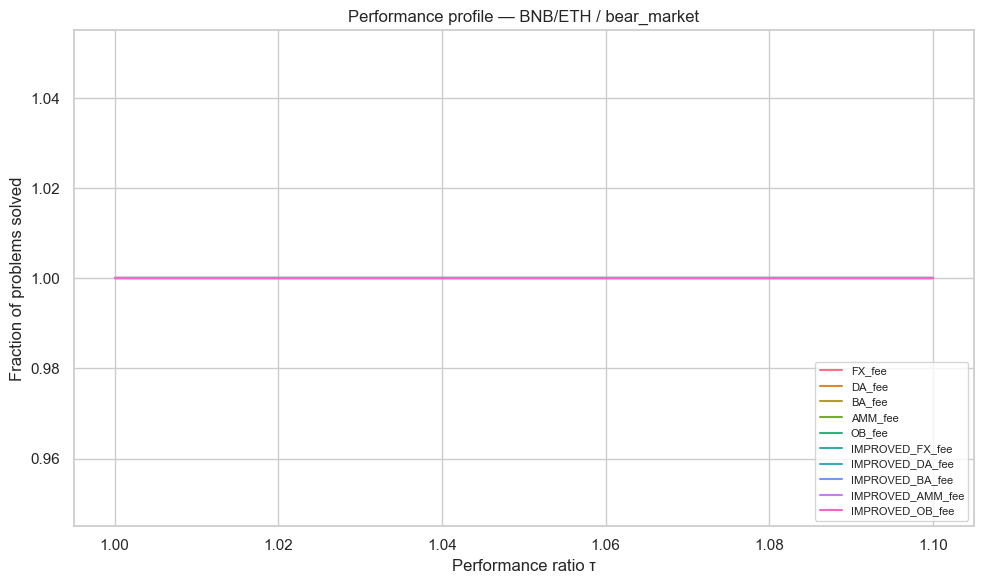

In [42]:
show_stats_for_pair_alias("BNB/ETH", "bear_market")
plot_yield_stats("BNB/ETH", "bear_market")
plot_performance_profile("BNB/ETH", "bear_market")

#### DOGE/BTC

##### volatile_market


=== DOGE/BTC / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,36351875.83 ± 52051863.57,6136.67 ± 741.61,343.02 ± 5.13,-5341.43 ± 3946.00,715.04 ± 24.56,-134.84 ± 114.56,-33354791.20 ± 47759509.61,-314.76 ± 5.28,10346611.57 ± 9072955.69
BA_fee,36380425.74 ± 52174265.34,6136.21 ± 737.77,343.01 ± 5.05,-5467.90 ± 4235.05,715.62 ± 24.21,-135.92 ± 116.22,-33391371.49 ± 47875095.34,-314.71 ± 5.14,10367175.53 ± 9071091.30
DA_fee,36400234.00 ± 52247606.65,6133.55 ± 740.36,343.02 ± 5.05,-5465.85 ± 4198.78,715.40 ± 24.18,-135.88 ± 116.25,-33395761.67 ± 47915709.98,-314.88 ± 5.07,10379518.88 ± 9066872.01
FX_fee,36382643.49 ± 52167994.36,6135.45 ± 739.43,343.04 ± 5.05,-5467.92 ± 4210.13,715.62 ± 24.11,-136.05 ± 116.22,-33397842.35 ± 47879897.82,-314.92 ± 5.07,10388793.89 ± 9081601.39
IMPROVED_AMM_fee,34951490.58 ± 56822782.13,6323.30 ± 691.12,399.23 ± 7.47,-5464.56 ± 8279.04,713.80 ± 25.86,-118.45 ± 113.45,-91977.91 ± 151688.58,-1.04 ± 0.09,5283568.17 ± 18657567.39
IMPROVED_BA_fee,34946925.26 ± 56777597.76,6334.93 ± 691.14,398.95 ± 7.48,-5405.61 ± 7502.29,712.72 ± 24.95,-117.01 ± 114.77,-91732.74 ± 140505.36,-1.07 ± 0.08,5284493.85 ± 18653446.36
IMPROVED_DA_fee,34952019.94 ± 56794518.57,6334.57 ± 689.90,399.07 ± 7.54,-6522.61 ± 8660.63,713.08 ± 24.99,-122.65 ± 114.47,-99927.28 ± 161531.36,-1.16 ± 0.14,5286645.74 ± 18650652.45
IMPROVED_FX_fee,34946880.13 ± 56778947.99,6335.35 ± 691.66,398.81 ± 7.51,-5339.41 ± 7400.65,713.30 ± 25.14,-120.15 ± 115.65,-87910.14 ± 139013.56,-1.01 ± 0.06,5282310.44 ± 18658272.26
IMPROVED_OB_fee,34933782.22 ± 56807083.07,6218.63 ± 669.31,400.11 ± 7.54,-5394.12 ± 6514.70,714.18 ± 24.73,-120.66 ± 116.69,53.58 ± 3462.80,-0.02 ± 0.03,5244784.97 ± 18780368.17


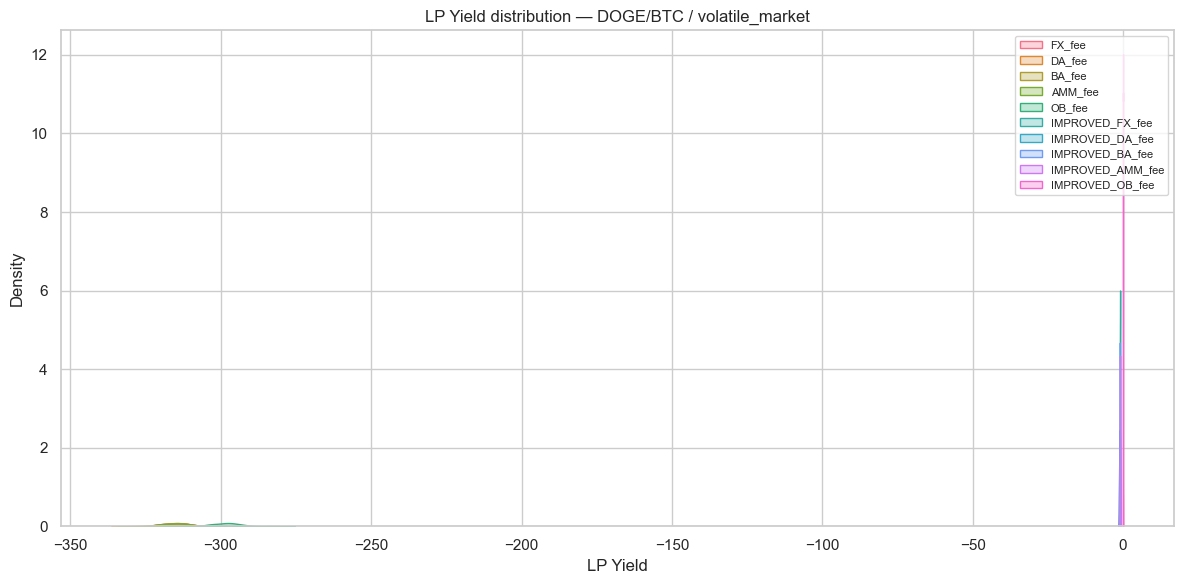

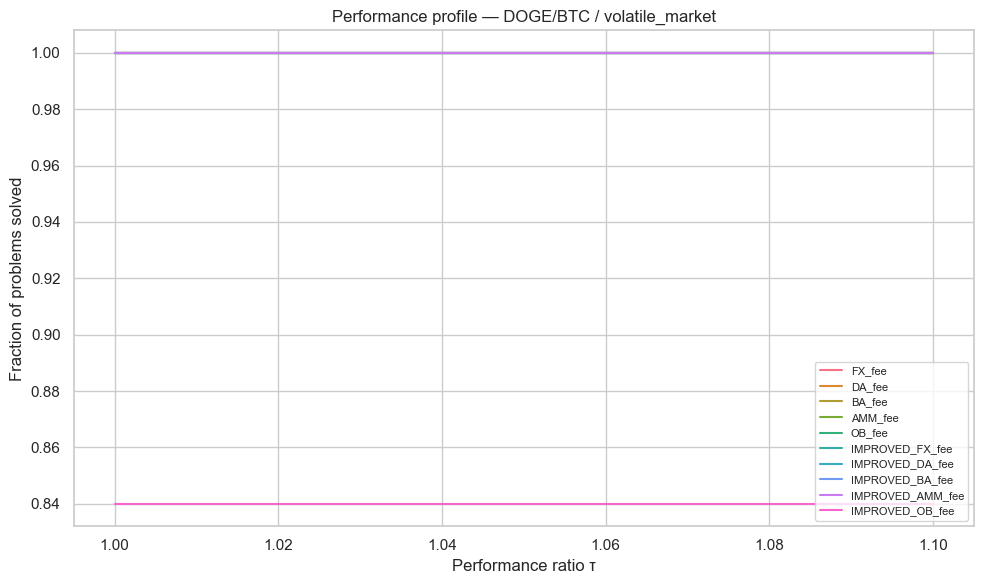

In [43]:
show_stats_for_pair_alias("DOGE/BTC", "volatile_market")
plot_yield_stats("DOGE/BTC", "volatile_market")
plot_performance_profile("DOGE/BTC", "volatile_market")

##### bull_market


=== DOGE/BTC / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,4748751.66 ± 5059446.66,5623.54 ± 218.34,100.93 ± 1.19,-7712.62 ± 4961.10,721.46 ± 24.55,-72.63 ± 26.77,-3345855.85 ± 3553624.90,-71.19 ± 1.30,6325574.53 ± 28691886.00
BA_fee,4771884.49 ± 5086350.72,5628.72 ± 217.87,101.13 ± 1.20,-7891.05 ± 5339.46,720.32 ± 24.16,-73.45 ± 26.28,-3393380.98 ± 3597939.98,-71.93 ± 1.23,6341413.27 ± 28700211.53
DA_fee,4774894.24 ± 5089615.05,5624.85 ± 217.54,101.21 ± 1.20,-7904.03 ± 5255.19,720.79 ± 24.47,-73.91 ± 26.72,-3403009.39 ± 3616205.43,-72.14 ± 1.19,6362692.86 ± 28765095.54
FX_fee,4779825.96 ± 5093430.34,5629.99 ± 217.79,101.22 ± 1.20,-7876.10 ± 5301.10,720.80 ± 24.31,-73.52 ± 26.54,-3410460.50 ± 3611639.91,-72.28 ± 1.16,6356487.75 ± 28732236.54
IMPROVED_AMM_fee,4173598.51 ± 4441420.48,5740.85 ± 199.23,117.71 ± 1.78,-7932.57 ± 5268.29,720.53 ± 23.57,-72.89 ± 25.87,-172475.52 ± 189549.47,-4.88 ± 0.33,5771373.41 ± 28182266.42
IMPROVED_BA_fee,4250030.52 ± 4511918.84,5800.27 ± 193.16,118.83 ± 1.72,-7828.67 ± 4757.81,720.69 ± 23.81,-73.19 ± 26.95,-266770.69 ± 271678.57,-7.56 ± 0.26,5851433.32 ± 28251735.98
IMPROVED_DA_fee,4271419.03 ± 4516226.62,5797.67 ± 192.85,119.53 ± 1.74,-8012.35 ± 5408.77,719.89 ± 23.95,-73.63 ± 26.43,-295350.94 ± 290955.40,-8.44 ± 0.84,5881773.74 ± 28271784.70
IMPROVED_FX_fee,4244979.74 ± 4504987.78,5803.30 ± 191.20,118.50 ± 1.75,-7861.82 ± 5172.41,720.22 ± 23.87,-73.24 ± 26.90,-261518.05 ± 268952.75,-7.38 ± 0.22,5847373.57 ± 28247565.78
IMPROVED_OB_fee,4041745.04 ± 4294385.30,5387.89 ± 182.68,118.29 ± 1.82,-7652.80 ± 3934.14,720.58 ± 24.44,-73.41 ± 28.62,23493.28 ± 34597.24,0.58 ± 0.17,5650766.83 ± 28080370.77


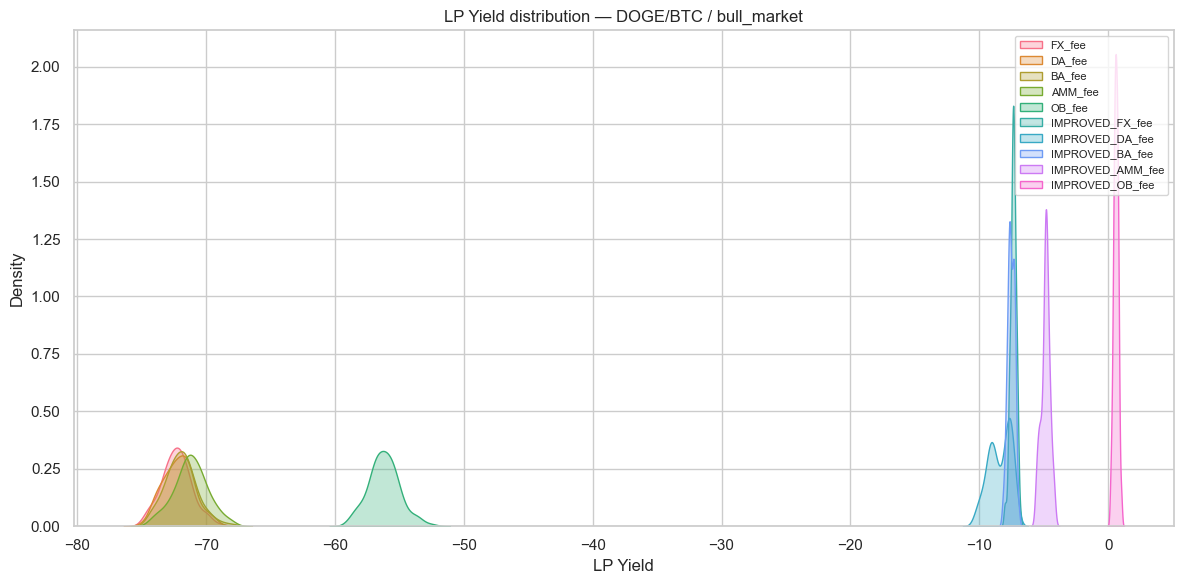

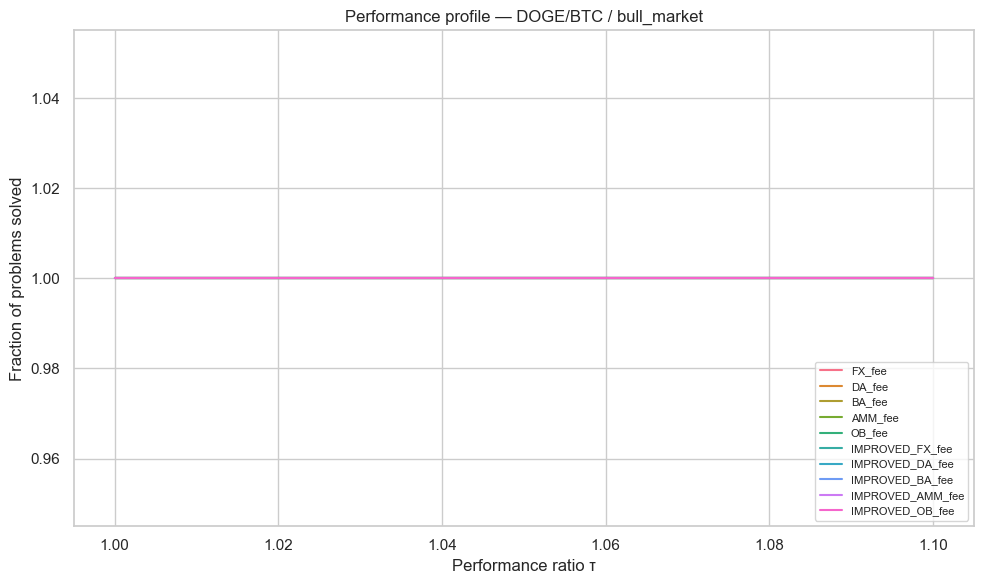

In [44]:
show_stats_for_pair_alias("DOGE/BTC", "bull_market")
plot_yield_stats("DOGE/BTC", "bull_market")
plot_performance_profile("DOGE/BTC", "bull_market")

##### calm_market


=== DOGE/BTC / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,1235339.40 ± 1108510.52,4597.64 ± 264.43,55.03 ± 0.74,-7913.01 ± 3642.25,721.05 ± 24.70,-69.39 ± 20.42,-540434.03 ± 474748.53,-24.31 ± 1.15,1663845.75 ± 8350063.16
BA_fee,1266863.44 ± 1143515.94,4622.11 ± 260.64,55.60 ± 0.71,-7990.17 ± 4003.51,721.15 ± 23.60,-69.71 ± 20.85,-599736.26 ± 528303.20,-26.50 ± 0.96,1690004.33 ± 8365728.12
DA_fee,1271415.17 ± 1147766.26,4622.30 ± 260.26,55.72 ± 0.72,-7958.66 ± 4044.63,721.08 ± 23.27,-69.45 ± 20.68,-609765.25 ± 539484.47,-26.89 ± 1.03,1701224.20 ± 8403379.68
FX_fee,1273233.79 ± 1149459.67,4629.10 ± 259.58,55.71 ± 0.72,-7944.63 ± 4087.40,721.10 ± 23.21,-69.28 ± 20.65,-614107.71 ± 543976.42,-27.02 ± 0.83,1698970.53 ± 8382271.38
IMPROVED_AMM_fee,1190331.98 ± 1066144.61,4689.28 ± 249.39,60.30 ± 0.89,-8083.78 ± 4634.51,721.32 ± 24.08,-69.68 ± 20.84,-64945.13 ± 54179.11,-3.48 ± 0.62,1626737.83 ± 8322237.63
IMPROVED_BA_fee,1271822.97 ± 1143478.21,4772.64 ± 246.23,62.80 ± 0.95,-7870.25 ± 3928.47,721.51 ± 24.04,-68.62 ± 20.86,-167128.74 ± 138458.49,-8.43 ± 0.50,1700791.68 ± 8385956.44
IMPROVED_DA_fee,1284081.08 ± 1155061.00,4776.74 ± 245.73,63.24 ± 1.02,-7991.05 ± 4191.83,721.51 ± 23.90,-69.34 ± 20.63,-185465.22 ± 159490.88,-9.25 ± 0.64,1718299.66 ± 8417777.52
IMPROVED_FX_fee,1276915.84 ± 1149502.47,4781.18 ± 247.18,62.83 ± 0.97,-7888.48 ± 3978.28,721.91 ± 24.73,-68.63 ± 20.69,-174909.08 ± 147872.82,-8.75 ± 0.33,1707129.18 ± 8393625.31
IMPROVED_OB_fee,1108231.58 ± 998163.02,4169.24 ± 224.48,61.76 ± 0.98,-8019.07 ± 3840.82,721.87 ± 23.48,-69.95 ± 21.38,85360.53 ± 81475.94,4.54 ± 0.40,1544381.08 ± 8253928.16


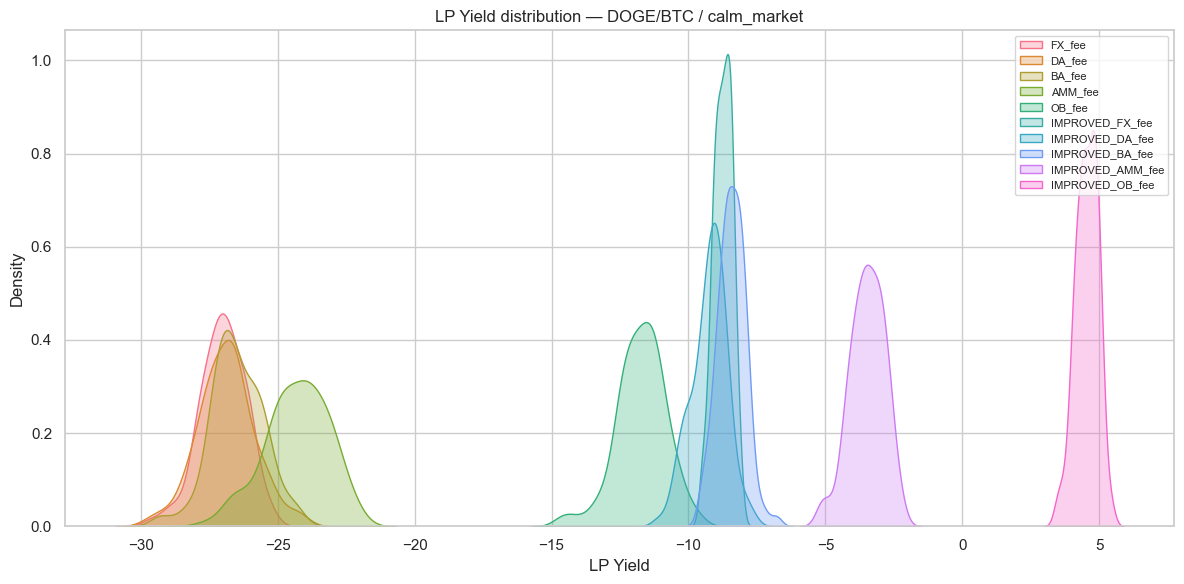

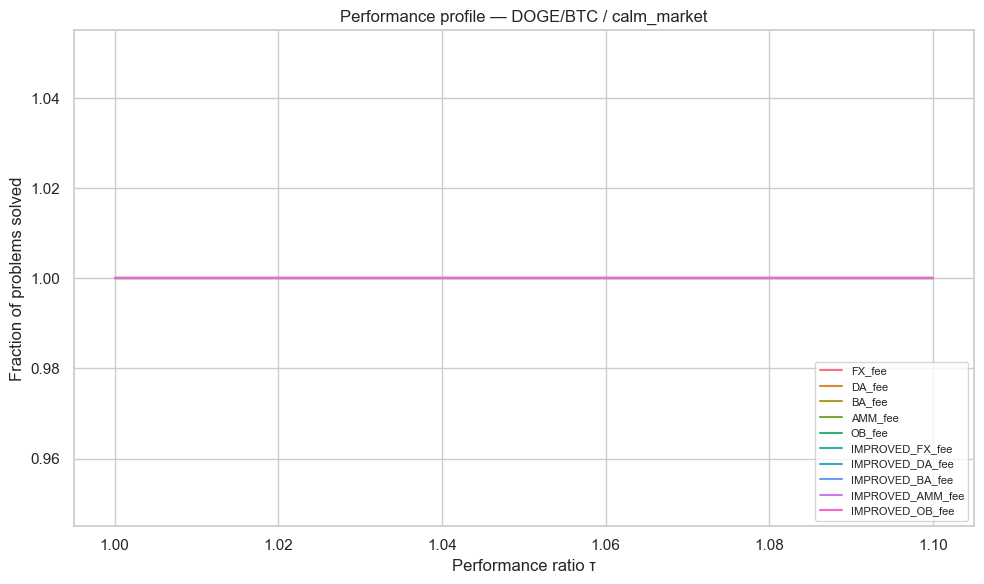

In [45]:
show_stats_for_pair_alias("DOGE/BTC", "calm_market")
plot_yield_stats("DOGE/BTC", "calm_market")
plot_performance_profile("DOGE/BTC", "calm_market")

##### bear_market


=== DOGE/BTC / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,2229263.62 ± 2074686.07,5104.82 ± 240.19,71.83 ± 0.87,-7906.29 ± 4252.66,720.88 ± 24.43,-70.94 ± 22.17,-1287382.67 ± 1188636.98,-41.62 ± 1.16,3133786.84 ± 15059002.77
BA_fee,2257642.66 ± 2101832.91,5118.57 ± 235.28,72.20 ± 0.92,-7804.63 ± 3629.73,720.77 ± 24.53,-71.53 ± 23.13,-1343498.11 ± 1236650.62,-43.03 ± 1.00,3157756.55 ± 15084104.39
DA_fee,2261942.00 ± 2107034.39,5114.37 ± 236.62,72.30 ± 0.92,-7846.91 ± 3861.07,720.68 ± 24.49,-71.56 ± 22.91,-1355421.27 ± 1254676.78,-43.37 ± 0.94,3175043.40 ± 15124301.75
FX_fee,2264728.90 ± 2108394.13,5121.27 ± 236.59,72.30 ± 0.92,-7788.96 ± 3802.31,720.86 ± 24.62,-71.23 ± 23.20,-1358657.51 ± 1248768.06,-43.47 ± 0.91,3168202.52 ± 15098661.72
IMPROVED_AMM_fee,2075320.34 ± 1926288.60,5216.51 ± 227.23,81.79 ± 1.33,-7883.01 ± 3909.17,720.88 ± 24.89,-70.89 ± 21.84,-121019.97 ± 112043.70,-4.86 ± 0.49,2990394.58 ± 14930201.00
IMPROVED_BA_fee,2168866.55 ± 2005096.57,5294.59 ± 213.79,83.99 ± 1.35,-7772.68 ± 3970.91,721.24 ± 24.28,-70.98 ± 23.78,-234198.82 ± 203608.38,-9.19 ± 0.33,3077211.98 ± 15001620.74
IMPROVED_DA_fee,2186864.55 ± 2015296.90,5293.30 ± 216.47,84.68 ± 1.30,-7830.36 ± 3820.14,722.07 ± 23.18,-71.08 ± 23.00,-260980.10 ± 227418.55,-10.26 ± 0.86,3104436.14 ± 15028947.13
IMPROVED_FX_fee,2170407.51 ± 2007861.84,5299.62 ± 215.51,83.87 ± 1.33,-7877.55 ± 3850.91,722.26 ± 23.19,-71.67 ± 23.46,-237090.71 ± 210070.05,-9.26 ± 0.25,3081052.63 ± 15007408.58
IMPROVED_OB_fee,1966662.52 ± 1822297.00,4764.15 ± 200.91,82.74 ± 1.36,-7872.17 ± 4217.66,721.30 ± 23.99,-70.92 ± 23.89,53018.24 ± 56179.62,2.09 ± 0.26,2889969.79 ± 14853973.06


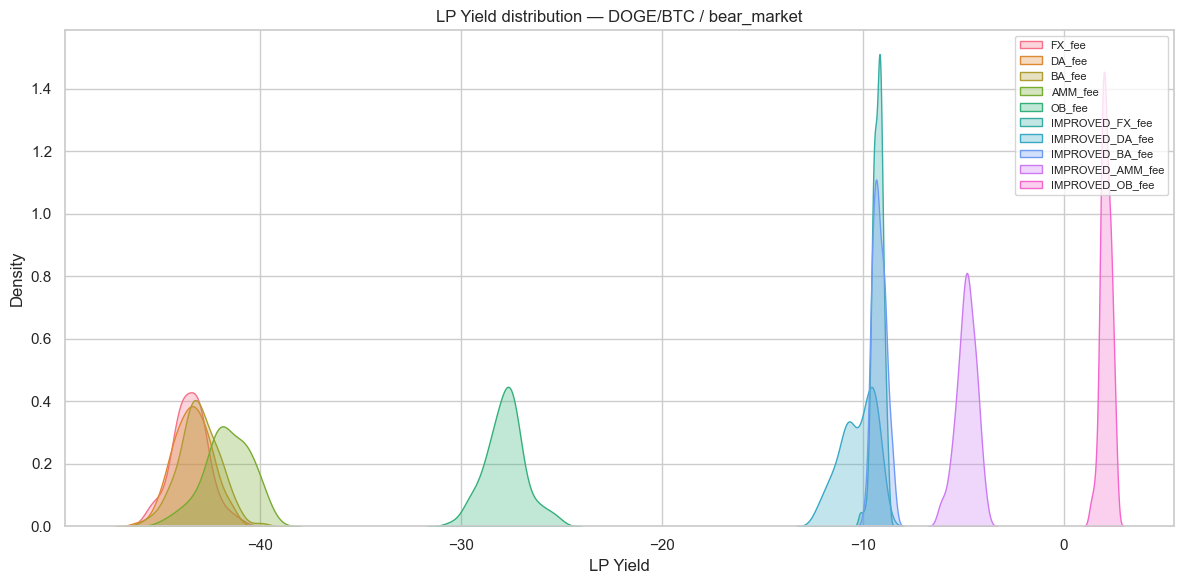

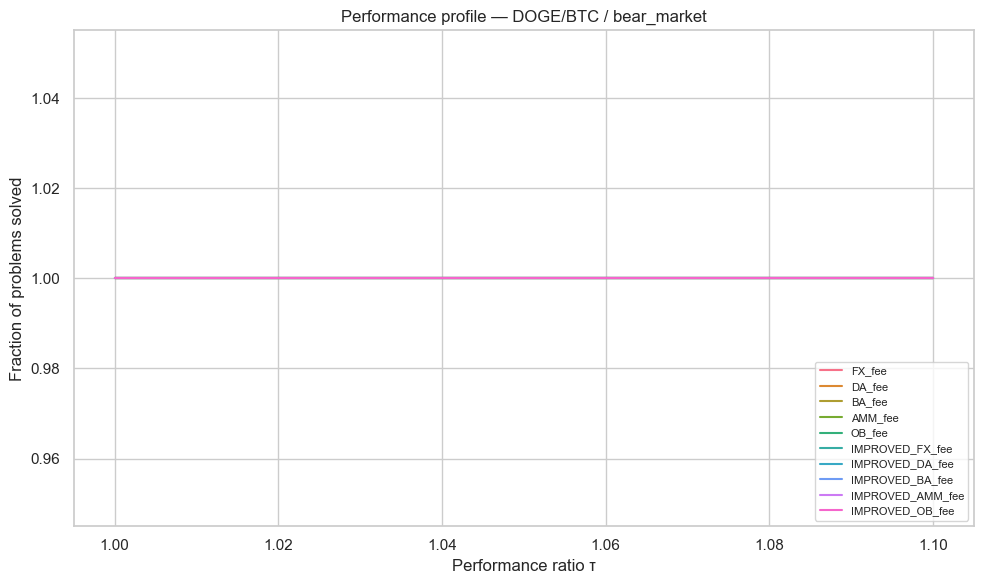

In [46]:
show_stats_for_pair_alias("DOGE/BTC", "bear_market")
plot_yield_stats("DOGE/BTC", "bear_market")
plot_performance_profile("DOGE/BTC", "bear_market")

### Export to CSV

In [47]:
import os

OUTPUT_DIR = "csv_export/synth_data_new_pairs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df.to_csv(f"{OUTPUT_DIR}/all_experiments_raw.csv", index=False)

for pair_name, month_alias in synth_desc.keys():
    safe_name = pair_name.replace("/", "_")
    show_stats_for_pair_alias(
        pair_name, month_alias, f"{OUTPUT_DIR}/{safe_name}_{month_alias}_stats.csv"
    )

print(f"Exported to {OUTPUT_DIR}/")


=== TUSD/USDC / volatile_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,36351875.83 ± 52051863.57,6136.67 ± 741.61,343.02 ± 5.13,-5341.43 ± 3946.00,715.04 ± 24.56,-134.84 ± 114.56,-33354791.20 ± 47759509.61,-314.76 ± 5.28,10346611.57 ± 9072955.69
BA_fee,36380425.74 ± 52174265.34,6136.21 ± 737.77,343.01 ± 5.05,-5467.90 ± 4235.05,715.62 ± 24.21,-135.92 ± 116.22,-33391371.49 ± 47875095.34,-314.71 ± 5.14,10367175.53 ± 9071091.30
DA_fee,36400234.00 ± 52247606.65,6133.55 ± 740.36,343.02 ± 5.05,-5465.85 ± 4198.78,715.40 ± 24.18,-135.88 ± 116.25,-33395761.67 ± 47915709.98,-314.88 ± 5.07,10379518.88 ± 9066872.01
FX_fee,36382643.49 ± 52167994.36,6135.45 ± 739.43,343.04 ± 5.05,-5467.92 ± 4210.13,715.62 ± 24.11,-136.05 ± 116.22,-33397842.35 ± 47879897.82,-314.92 ± 5.07,10388793.89 ± 9081601.39
IMPROVED_AMM_fee,34951490.58 ± 56822782.13,6323.30 ± 691.12,399.23 ± 7.47,-5464.56 ± 8279.04,713.80 ± 25.86,-118.45 ± 113.45,-91977.91 ± 151688.58,-1.04 ± 0.09,5283568.17 ± 18657567.39
IMPROVED_BA_fee,34946925.26 ± 56777597.76,6334.93 ± 691.14,398.95 ± 7.48,-5405.61 ± 7502.29,712.72 ± 24.95,-117.01 ± 114.77,-91732.74 ± 140505.36,-1.07 ± 0.08,5284493.85 ± 18653446.36
IMPROVED_DA_fee,34952019.94 ± 56794518.57,6334.57 ± 689.90,399.07 ± 7.54,-6522.61 ± 8660.63,713.08 ± 24.99,-122.65 ± 114.47,-99927.28 ± 161531.36,-1.16 ± 0.14,5286645.74 ± 18650652.45
IMPROVED_FX_fee,34946880.13 ± 56778947.99,6335.35 ± 691.66,398.81 ± 7.51,-5339.41 ± 7400.65,713.30 ± 25.14,-120.15 ± 115.65,-87910.14 ± 139013.56,-1.01 ± 0.06,5282310.44 ± 18658272.26
IMPROVED_OB_fee,34933782.22 ± 56807083.07,6218.63 ± 669.31,400.11 ± 7.54,-5394.12 ± 6514.70,714.18 ± 24.73,-120.66 ± 116.69,53.58 ± 3462.80,-0.02 ± 0.03,5244784.97 ± 18780368.17



=== TUSD/USDC / bear_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,2229263.62 ± 2074686.07,5104.82 ± 240.19,71.83 ± 0.87,-7906.29 ± 4252.66,720.88 ± 24.43,-70.94 ± 22.17,-1287382.67 ± 1188636.98,-41.62 ± 1.16,3133786.84 ± 15059002.77
BA_fee,2257642.66 ± 2101832.91,5118.57 ± 235.28,72.20 ± 0.92,-7804.63 ± 3629.73,720.77 ± 24.53,-71.53 ± 23.13,-1343498.11 ± 1236650.62,-43.03 ± 1.00,3157756.55 ± 15084104.39
DA_fee,2261942.00 ± 2107034.39,5114.37 ± 236.62,72.30 ± 0.92,-7846.91 ± 3861.07,720.68 ± 24.49,-71.56 ± 22.91,-1355421.27 ± 1254676.78,-43.37 ± 0.94,3175043.40 ± 15124301.75
FX_fee,2264728.90 ± 2108394.13,5121.27 ± 236.59,72.30 ± 0.92,-7788.96 ± 3802.31,720.86 ± 24.62,-71.23 ± 23.20,-1358657.51 ± 1248768.06,-43.47 ± 0.91,3168202.52 ± 15098661.72
IMPROVED_AMM_fee,2075320.34 ± 1926288.60,5216.51 ± 227.23,81.79 ± 1.33,-7883.01 ± 3909.17,720.88 ± 24.89,-70.89 ± 21.84,-121019.97 ± 112043.70,-4.86 ± 0.49,2990394.58 ± 14930201.00
IMPROVED_BA_fee,2168866.55 ± 2005096.57,5294.59 ± 213.79,83.99 ± 1.35,-7772.68 ± 3970.91,721.24 ± 24.28,-70.98 ± 23.78,-234198.82 ± 203608.38,-9.19 ± 0.33,3077211.98 ± 15001620.74
IMPROVED_DA_fee,2186864.55 ± 2015296.90,5293.30 ± 216.47,84.68 ± 1.30,-7830.36 ± 3820.14,722.07 ± 23.18,-71.08 ± 23.00,-260980.10 ± 227418.55,-10.26 ± 0.86,3104436.14 ± 15028947.13
IMPROVED_FX_fee,2170407.51 ± 2007861.84,5299.62 ± 215.51,83.87 ± 1.33,-7877.55 ± 3850.91,722.26 ± 23.19,-71.67 ± 23.46,-237090.71 ± 210070.05,-9.26 ± 0.25,3081052.63 ± 15007408.58
IMPROVED_OB_fee,1966662.52 ± 1822297.00,4764.15 ± 200.91,82.74 ± 1.36,-7872.17 ± 4217.66,721.30 ± 23.99,-70.92 ± 23.89,53018.24 ± 56179.62,2.09 ± 0.26,2889969.79 ± 14853973.06



=== TUSD/USDC / calm_market ===


...


=== DOGE/BTC / calm_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,1235339.40 ± 1108510.52,4597.64 ± 264.43,55.03 ± 0.74,-7913.01 ± 3642.25,721.05 ± 24.70,-69.39 ± 20.42,-540434.03 ± 474748.53,-24.31 ± 1.15,1663845.75 ± 8350063.16
BA_fee,1266863.44 ± 1143515.94,4622.11 ± 260.64,55.60 ± 0.71,-7990.17 ± 4003.51,721.15 ± 23.60,-69.71 ± 20.85,-599736.26 ± 528303.20,-26.50 ± 0.96,1690004.33 ± 8365728.12
DA_fee,1271415.17 ± 1147766.26,4622.30 ± 260.26,55.72 ± 0.72,-7958.66 ± 4044.63,721.08 ± 23.27,-69.45 ± 20.68,-609765.25 ± 539484.47,-26.89 ± 1.03,1701224.20 ± 8403379.68
FX_fee,1273233.79 ± 1149459.67,4629.10 ± 259.58,55.71 ± 0.72,-7944.63 ± 4087.40,721.10 ± 23.21,-69.28 ± 20.65,-614107.71 ± 543976.42,-27.02 ± 0.83,1698970.53 ± 8382271.38
IMPROVED_AMM_fee,1190331.98 ± 1066144.61,4689.28 ± 249.39,60.30 ± 0.89,-8083.78 ± 4634.51,721.32 ± 24.08,-69.68 ± 20.84,-64945.13 ± 54179.11,-3.48 ± 0.62,1626737.83 ± 8322237.63
IMPROVED_BA_fee,1271822.97 ± 1143478.21,4772.64 ± 246.23,62.80 ± 0.95,-7870.25 ± 3928.47,721.51 ± 24.04,-68.62 ± 20.86,-167128.74 ± 138458.49,-8.43 ± 0.50,1700791.68 ± 8385956.44
IMPROVED_DA_fee,1284081.08 ± 1155061.00,4776.74 ± 245.73,63.24 ± 1.02,-7991.05 ± 4191.83,721.51 ± 23.90,-69.34 ± 20.63,-185465.22 ± 159490.88,-9.25 ± 0.64,1718299.66 ± 8417777.52
IMPROVED_FX_fee,1276915.84 ± 1149502.47,4781.18 ± 247.18,62.83 ± 0.97,-7888.48 ± 3978.28,721.91 ± 24.73,-68.63 ± 20.69,-174909.08 ± 147872.82,-8.75 ± 0.33,1707129.18 ± 8393625.31
IMPROVED_OB_fee,1108231.58 ± 998163.02,4169.24 ± 224.48,61.76 ± 0.98,-8019.07 ± 3840.82,721.87 ± 23.48,-69.95 ± 21.38,85360.53 ± 81475.94,4.54 ± 0.40,1544381.08 ± 8253928.16



=== DOGE/BTC / bull_market ===


,iu_markout,iu_trade_count,iu_yield,uu_markout,uu_trade_count,uu_yield,lp_markout,lp_yield,impermanent_loss
fee_algo_name,,,,,,,,,
AMM_fee,4748751.66 ± 5059446.66,5623.54 ± 218.34,100.93 ± 1.19,-7712.62 ± 4961.10,721.46 ± 24.55,-72.63 ± 26.77,-3345855.85 ± 3553624.90,-71.19 ± 1.30,6325574.53 ± 28691886.00
BA_fee,4771884.49 ± 5086350.72,5628.72 ± 217.87,101.13 ± 1.20,-7891.05 ± 5339.46,720.32 ± 24.16,-73.45 ± 26.28,-3393380.98 ± 3597939.98,-71.93 ± 1.23,6341413.27 ± 28700211.53
DA_fee,4774894.24 ± 5089615.05,5624.85 ± 217.54,101.21 ± 1.20,-7904.03 ± 5255.19,720.79 ± 24.47,-73.91 ± 26.72,-3403009.39 ± 3616205.43,-72.14 ± 1.19,6362692.86 ± 28765095.54
FX_fee,4779825.96 ± 5093430.34,5629.99 ± 217.79,101.22 ± 1.20,-7876.10 ± 5301.10,720.80 ± 24.31,-73.52 ± 26.54,-3410460.50 ± 3611639.91,-72.28 ± 1.16,6356487.75 ± 28732236.54
IMPROVED_AMM_fee,4173598.51 ± 4441420.48,5740.85 ± 199.23,117.71 ± 1.78,-7932.57 ± 5268.29,720.53 ± 23.57,-72.89 ± 25.87,-172475.52 ± 189549.47,-4.88 ± 0.33,5771373.41 ± 28182266.42
IMPROVED_BA_fee,4250030.52 ± 4511918.84,5800.27 ± 193.16,118.83 ± 1.72,-7828.67 ± 4757.81,720.69 ± 23.81,-73.19 ± 26.95,-266770.69 ± 271678.57,-7.56 ± 0.26,5851433.32 ± 28251735.98
IMPROVED_DA_fee,4271419.03 ± 4516226.62,5797.67 ± 192.85,119.53 ± 1.74,-8012.35 ± 5408.77,719.89 ± 23.95,-73.63 ± 26.43,-295350.94 ± 290955.40,-8.44 ± 0.84,5881773.74 ± 28271784.70
IMPROVED_FX_fee,4244979.74 ± 4504987.78,5803.30 ± 191.20,118.50 ± 1.75,-7861.82 ± 5172.41,720.22 ± 23.87,-73.24 ± 26.90,-261518.05 ± 268952.75,-7.38 ± 0.22,5847373.57 ± 28247565.78
IMPROVED_OB_fee,4041745.04 ± 4294385.30,5387.89 ± 182.68,118.29 ± 1.82,-7652.80 ± 3934.14,720.58 ± 24.44,-73.41 ± 28.62,23493.28 ± 34597.24,0.58 ± 0.17,5650766.83 ± 28080370.77


Exported to csv_export/synth_data_new_pairs/
